In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gzip
import urllib.request as request
import os
import torch.optim as optim
import torchvision.datasets as datasets
import h5py
import time
import pandas as pd
import random
import math
from copy import deepcopy
from torch.optim import Adam
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from torch.utils.data import Subset
from torchmetrics.image import StructuralSimilarityIndexMeasure
from pytorch_msssim import ssim
from IPython.display import display

In [2]:
SEED = 42
FILE_PATH = 'Diffusion_jets_procesados_por_canal.hdf5'
CHANNEL_NAMES = ['TRACKER', 'ECAL', 'HCAL']
NORMALIZATION_PERCENTILE = 99.5
SPLIT_SEED = 42
USE_SMALL_SUBSET = True
TRAIN_SMALL_SIZE = 10000
VAL_SMALL_SIZE = 2500
TEST_SMALL_SIZE = 2500
BATCH_SIZE = 16
NUM_EPOCHS = 40
LEARNING_RATE = 0.0002
LATENT_CHANNELS = 4
BASE_CHANNELS = 64
BETA_MAX = 0.001
KL_START_EPOCH = 5
KL_WARMUP_EPOCHS = 15
ACTIVE_THRESHOLD_01 = 0.0001
ACTIVE_WEIGHT = 5.0
BACKGROUND_WEIGHT = 1.0
ENERGY_WEIGHT = 1.0
BACKGROUND_ENERGY_WEIGHT = 0.01
OCCUPANCY_WEIGHT = 2.0
FALSE_POSITIVE_WEIGHT = 0.5
PEAK_WEIGHT = 1.0
GATE_TEMPERATURE = 0.05
TOPK_PEAK_PIXELS = 8
MASK_WEIGHT = 0.1
OCCUPANCY_THRESHOLD = 0.8
TRACKER_OCCUPANCY_THRESHOLD = 0.79202
ECAL_OCCUPANCY_THRESHOLD = 0.79697
HCAL_OCCUPANCY_THRESHOLD = 0.826667


def get_occupancy_thresholds(reference_tensor):
    return reference_tensor.new_tensor([TRACKER_OCCUPANCY_THRESHOLD, ECAL_OCCUPANCY_THRESHOLD, HCAL_OCCUPANCY_THRESHOLD]).view(1, 3, 1, 1)

In [3]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: mps


In [4]:
def raw_to_01(x):
    if x.min() < 0:
        x = (x + 1.0) / 2.0

    return np.clip(x, 0.0, None)


def make_split_indices(total_size, train_fraction=0.8, val_fraction=0.1, seed=42):
    train_size = int(train_fraction * total_size)
    val_size = int(val_fraction * total_size)
    generator = torch.Generator().manual_seed(seed)
    permutation = torch.randperm(total_size, generator=generator).numpy()
    train_indices = permutation[:train_size]
    val_indices = permutation[train_size:train_size + val_size]
    test_indices = permutation[train_size + val_size:]

    return (train_indices, val_indices, test_indices)


def compute_global_active_scale(file_path, train_indices, percentile=99.5, chunk_size=512):
    sorted_indices = np.sort(np.asarray(train_indices, dtype=np.int64))
    active_chunks = []

    with h5py.File(file_path, 'r') as file:
        dataset = file['X_diffusion']

        for start in range(0, len(sorted_indices), chunk_size):
            batch_indices = sorted_indices[start:start + chunk_size]
            x = dataset[batch_indices].astype(np.float32)
            x_01 = raw_to_01(x)
            active = x_01[x_01 > 0.0]

            if active.size:
                active_chunks.append(active)

    if not active_chunks:
        return 1.0

    active_values = np.concatenate(active_chunks)

    return float(np.percentile(active_values, percentile))

In [5]:
class IndexedJetsDataset(Dataset):

    def __init__(self, file_path, indices, global_scale):
        super().__init__()
        self.indices = np.asarray(indices, dtype=np.int64)
        self.global_scale = float(global_scale)

        if self.global_scale <= 0:
            raise ValueError('global_scale debe ser positiva.')

        order = np.argsort(self.indices)
        sorted_indices = self.indices[order]

        with h5py.File(file_path, 'r') as file:
            x_sorted = file['X_diffusion'][sorted_indices].astype(np.float32)
            y_sorted = file['y'][sorted_indices].astype(np.int64)

        inverse_order = np.argsort(order)
        x = x_sorted[inverse_order]
        self.y = y_sorted[inverse_order]
        x_01 = raw_to_01(x)
        x_01 = np.clip(x_01 / (self.global_scale + 1e-08), 0.0, 1.0)
        self.x = (2.0 * x_01 - 1.0).astype(np.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, index):
        image = torch.from_numpy(self.x[index]).permute(2, 0, 1).float()
        label = torch.tensor(self.y[index], dtype=torch.long)

        return (image, label)

In [6]:
with h5py.File(FILE_PATH, 'r') as file:
    total_size = file['X_diffusion'].shape[0]

train_indices_full, val_indices_full, test_indices_full = make_split_indices(total_size=total_size, seed=SPLIT_SEED)

if USE_SMALL_SUBSET:
    train_indices = train_indices_full[:TRAIN_SMALL_SIZE]
    val_indices = val_indices_full[:VAL_SMALL_SIZE]
    test_indices = test_indices_full[:TEST_SMALL_SIZE]
else:
    train_indices = train_indices_full
    val_indices = val_indices_full
    test_indices = test_indices_full

global_train_scale = compute_global_active_scale(file_path=FILE_PATH, train_indices=train_indices, percentile=NORMALIZATION_PERCENTILE)
train_dataset = IndexedJetsDataset(FILE_PATH, train_indices, global_train_scale)
val_dataset = IndexedJetsDataset(FILE_PATH, val_indices, global_train_scale)
test_dataset = IndexedJetsDataset(FILE_PATH, test_indices, global_train_scale)
train_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, generator=train_generator)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print('Total:', total_size)
print('Train:', len(train_dataset))
print('Validation:', len(val_dataset))
print('Test:', len(test_dataset))
print(f'Escala global P{NORMALIZATION_PERCENTILE}: {global_train_scale:.8f}')

Total: 139306
Train: 10000
Validation: 2500
Test: 2500
Escala global P99.5: 0.02826625


In [7]:
images_batch, labels_batch = next(iter(train_loader))
print('Images:', images_batch.shape)
print('Labels:', labels_batch.shape)
print('Min:', images_batch.min().item())
print('Max:', images_batch.max().item())
print('Mean:', images_batch.mean().item())
print('Std:', images_batch.std().item())

Images: torch.Size([16, 3, 64, 64])
Labels: torch.Size([16])
Min: -1.0
Max: 1.0
Mean: -0.996368944644928
Std: 0.048466820269823074


In [8]:
def ejemplo_imagenes(images, labels):
    fig, axs = plt.subplots(ncols=len(images), nrows=1, figsize=(12, 3))

    for i in range(len(images)):
        imagen_lista = np.transpose(images[i], (1, 2, 0))
        val_min = imagen_lista.min()
        val_max = imagen_lista.max()

        if val_max > val_min:
            imagen_lista = (imagen_lista - val_min) / (val_max - val_min)

        label_val = labels[i].item() if hasattr(labels[i], 'item') else labels[i]
        print(f'Imagen {i} - Min real: {val_min:.4f}, Max real: {val_max:.4f}')
        axs[i].imshow(imagen_lista)
        axs[i].set_title(f'Label: {label_val}')
        axs[i].set_xticks([])
        axs[i].set_yticks([])
        axs[i].set_xlabel(f'Index: {i}')

    plt.tight_layout()
    plt.show()

Imagen 0 - Min real: -1.0000, Max real: 1.0000
Imagen 1 - Min real: -1.0000, Max real: 1.0000
Imagen 2 - Min real: -1.0000, Max real: 1.0000
Imagen 3 - Min real: -1.0000, Max real: 0.7728
Imagen 4 - Min real: -1.0000, Max real: 1.0000


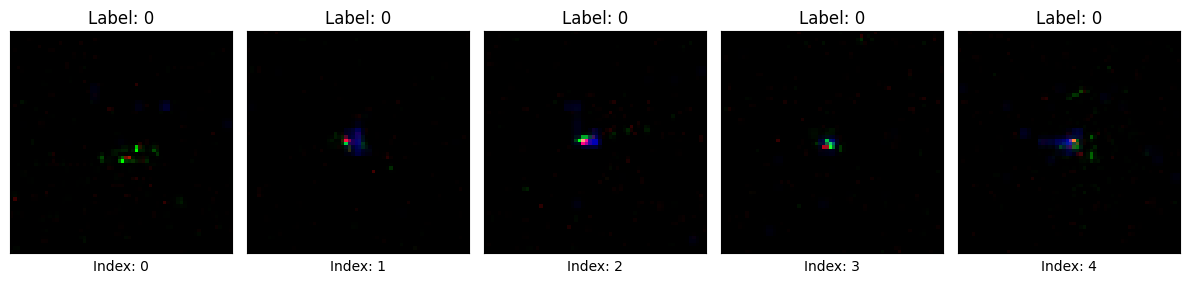

In [9]:
imagenes_ejemplo = np.stack([train_dataset[i][0].numpy() for i in range(5)])
etiquetas_ejemplo = [train_dataset[i][1] for i in range(5)]
ejemplo_imagenes(imagenes_ejemplo, etiquetas_ejemplo)

## Latent Compression and Reconstruction

The data pipeline trains a convolutional VAE and encodes each jet as a standardized latent tensor with shape $4\times16\times16$. These latents are the inputs used by both the classical and hybrid diffusion models.

In [10]:
class ConvBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1,
    ):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
            ),
            nn.GroupNorm(
                8,
                out_channels,
            ),
            nn.SiLU(),
        )

    def forward(self, x):
        return self.block(x)

In [11]:
class SimpleConvVAE16Occupancy(nn.Module):

    def __init__(
        self,
        in_channels=3,
        latent_channels=4,
        base_channels=64,
    ):
        super().__init__()

        self.latent_channels = latent_channels

        self.encoder = nn.Sequential(

            ConvBlock(
                in_channels,
                base_channels,
                stride=1,
            ),

            ConvBlock(
                base_channels,
                base_channels * 2,
                stride=2,
            ),

            ConvBlock(
                base_channels * 2,
                base_channels * 4,
                stride=2,
            ),
        )

        self.to_mu = nn.Conv2d(
            base_channels * 4,
            latent_channels,
            kernel_size=3,
            padding=1,
        )

        self.to_log_var = nn.Conv2d(
            base_channels * 4,
            latent_channels,
            kernel_size=3,
            padding=1,
        )

        self.dec_in = ConvBlock(
            latent_channels,
            base_channels * 4,
            stride=1,
        )

        self.up1 = nn.Sequential(

            nn.ConvTranspose2d(
                base_channels * 4,
                base_channels * 2,
                kernel_size=4,
                stride=2,
                padding=1,
            ),

            nn.GroupNorm(
                8,
                base_channels * 2,
            ),

            nn.SiLU(),
        )

        self.up2 = nn.Sequential(

            nn.ConvTranspose2d(
                base_channels * 2,
                base_channels,
                kernel_size=4,
                stride=2,
                padding=1,
            ),

            nn.GroupNorm(
                8,
                base_channels,
            ),

            nn.SiLU(),
        )

        self.mask_head = nn.Conv2d(
            base_channels,
            in_channels,
            kernel_size=3,
            padding=1,
        )

        self.intensity_head = nn.Conv2d(
            base_channels,
            in_channels,
            kernel_size=3,
            padding=1,
        )

        nn.init.zeros_(
            self.mask_head.weight
        )

        nn.init.zeros_(
            self.intensity_head.weight
        )

        mask_prior = 0.01

        mask_bias = np.log(
            mask_prior
            / (1.0 - mask_prior)
        )

        nn.init.constant_(
            self.mask_head.bias,
            float(mask_bias),
        )

        nn.init.constant_(
            self.intensity_head.bias,
            -2.0,
        )

    def encode(self, x):

        h = self.encoder(x)

        mu = self.to_mu(h)

        log_var = self.to_log_var(h)

        log_var = torch.clamp(
            log_var,
            min=-10.0,
            max=8.0,
        )

        return mu, log_var

    @staticmethod
    def reparameterize(
        mu,
        log_var,
    ):

        std = torch.exp(
            0.5 * log_var
        )

        noise = torch.randn_like(
            std
        )

        return (
            mu
            + noise * std
        )

    def decode_components(
        self,
        z,
    ):

        h = self.dec_in(z)

        h = self.up1(h)

        h = self.up2(h)

        mask_logits = (
            self.mask_head(h)
        )

        mask_probability = torch.sigmoid(
            mask_logits
        )

        intensity_logits = (
            self.intensity_head(h)
        )

        intensity_01 = torch.sigmoid(
            intensity_logits
        )

        reconstruction_01 = (
            mask_probability
            * intensity_01
        )

        reconstruction = (
            2.0 * reconstruction_01
            - 1.0
        )

        return (
            reconstruction,
            mask_logits,
            mask_probability,
            intensity_01,
        )

    def decode(
        self,
        z,
    ):

        (
            reconstruction,
            _,
            _,
            _,
        ) = self.decode_components(z)

        return reconstruction

    def decode_hard(
        self,
        z,
    ):

        (
            _,
            _,
            mask_probability,
            intensity_01,
        ) = self.decode_components(z)

        channel_thresholds = (
            get_occupancy_thresholds(
                mask_probability
            )
        )

        hard_mask = (
            mask_probability
            > channel_thresholds
        ).to(
            intensity_01.dtype
        )

        reconstruction_01 = (
            hard_mask
            * intensity_01
        )

        return (
            2.0 * reconstruction_01
            - 1.0
        )

    def forward(
        self,
        x,
        deterministic=False,
        return_components=False,
    ):

        mu, log_var = self.encode(x)

        if deterministic:

            z = mu

        else:

            z = self.reparameterize(
                mu,
                log_var,
            )

        (
            reconstruction,
            mask_logits,
            mask_probability,
            intensity_01,
        ) = self.decode_components(z)

        if return_components:

            return (
                reconstruction,
                mu,
                log_var,
                z,
                mask_logits,
                mask_probability,
                intensity_01,
            )

        return (
            reconstruction,
            mu,
            log_var,
            z,
        )

In [12]:
model_test = SimpleConvVAE16Occupancy(in_channels=3, latent_channels=LATENT_CHANNELS, base_channels=BASE_CHANNELS).to(device)

with torch.no_grad():
    output = model_test(images_batch[:2].to(device), deterministic=False, return_components=True)

reconstruction_test, mu_test, log_var_test, z_test, mask_logits_test, mask_probability_test, intensity_test = output
print('Entrada:', images_batch[:2].shape)
print('Latente:', z_test.shape)
print('Reconstrucción:', reconstruction_test.shape)
print('Máscara:', mask_probability_test.shape)
print('Intensidad:', intensity_test.shape)
print('Parámetros:', f'{sum((parameter.numel() for parameter in model_test.parameters())):,}')

Entrada: torch.Size([2, 3, 64, 64])
Latente: torch.Size([2, 4, 16, 16])
Reconstrucción: torch.Size([2, 3, 64, 64])
Máscara: torch.Size([2, 3, 64, 64])
Intensidad: torch.Size([2, 3, 64, 64])
Parámetros: 1,059,534


In [13]:
def masked_mean(values, mask, eps=1e-08):
    return (values * mask).sum() / (mask.sum() + eps)


def jet_vae_loss(
    reconstruction, target, mu, log_var, mask_logits, mask_probability, intensity_01, beta, active_thr_01=0.0001,
    active_weight=5.0, background_weight=1.0, energy_weight=1.0, background_energy_weight=0.01, mask_weight=0.1,
    occupancy_weight=2.0, false_positive_weight=0.5, peak_weight=1.0, occupancy_threshold=0.8,
    gate_temperature=0.05, topk_peak_pixels=8,
):
    target_01 = ((target + 1.0) / 2.0).clamp(0.0, 1.0)
    active_mask = (target_01 > active_thr_01).to(target_01.dtype)
    background_mask = 1.0 - active_mask
    intensity_absolute_error = torch.abs(intensity_01 - target_01)
    intensity_pixel_weight = 1.0 + 4.0 * target_01.square()
    active_intensity_loss = masked_mean(intensity_pixel_weight * intensity_absolute_error, active_mask)
    soft_gate = torch.sigmoid((mask_probability - occupancy_threshold) / gate_temperature)
    predicted_01 = soft_gate * intensity_01
    background_l1 = masked_mean(predicted_01, background_mask)
    reconstruction_loss = active_weight * active_intensity_loss + background_weight * background_l1
    predicted_active_fraction = soft_gate.mean(dim=(-2, -1))
    target_active_fraction = active_mask.mean(dim=(-2, -1))
    occupancy_loss = F.l1_loss(predicted_active_fraction, target_active_fraction)
    false_positive_loss = masked_mean(soft_gate, background_mask)
    predicted_energy = predicted_01.sum(dim=(-2, -1))
    target_energy = target_01.sum(dim=(-2, -1))
    energy_loss = F.smooth_l1_loss(torch.log1p(predicted_energy), torch.log1p(target_energy))
    false_background_energy = (predicted_01 * background_mask).sum(dim=(-2, -1))
    background_energy_loss = torch.log1p(false_background_energy).mean()
    positive_count = active_mask.sum(dim=(0, 2, 3))
    negative_count = background_mask.sum(dim=(0, 2, 3))
    positive_weight = torch.sqrt(negative_count / positive_count.clamp_min(1.0)).clamp(min=1.0, max=6.0)
    positive_weight = positive_weight.view(1, -1, 1, 1).detach()
    mask_loss = F.binary_cross_entropy_with_logits(mask_logits, active_mask, pos_weight=positive_weight)
    num_pixels = target_01.shape[-2] * target_01.shape[-1]
    k = min(topk_peak_pixels, num_pixels)
    predicted_topk = predicted_01.flatten(start_dim=2).topk(k, dim=-1).values.mean(dim=-1)
    target_topk = target_01.flatten(start_dim=2).topk(k, dim=-1).values.mean(dim=-1)
    predicted_maximum = predicted_01.amax(dim=(-2, -1))
    target_maximum = target_01.amax(dim=(-2, -1))
    topk_loss = F.l1_loss(predicted_topk, target_topk)
    maximum_loss = F.l1_loss(predicted_maximum, target_maximum)
    peak_loss = 0.5 * topk_loss + 0.5 * maximum_loss
    kl_loss = 0.5 * (mu.square() + log_var.exp() - 1.0 - log_var).mean()
    total_loss = (
        reconstruction_loss
        + energy_weight * energy_loss
        + background_energy_weight * background_energy_loss
        + mask_weight * mask_loss
        + occupancy_weight * occupancy_loss
        + false_positive_weight * false_positive_loss
        + peak_weight * peak_loss
        + beta * kl_loss
    )
    components = {
        'loss': total_loss,
        'reconstruction': reconstruction_loss,
        'active_l1': active_intensity_loss,
        'background_l1': background_l1,
        'energy': energy_loss,
        'background_energy': background_energy_loss,
        'mask_bce': mask_loss,
        'occupancy': occupancy_loss,
        'false_positive': false_positive_loss,
        'peak': peak_loss,
        'maximum': maximum_loss,
        'kl': kl_loss,
    }

    return (total_loss, components)

In [14]:
def accumulate_metrics(metric_sums, components, batch_size):
    for key, value in components.items():
        metric_sums[key] = metric_sums.get(key, 0.0) + value.detach().item() * batch_size


def average_metrics(metric_sums, n_examples):
    return {key: value / max(n_examples, 1) for key, value in metric_sums.items()}


def beta_for_epoch(epoch, beta_max, kl_start_epoch, kl_warmup_epochs):
    if epoch < kl_start_epoch:
        return 0.0

    progress = min(1.0, (epoch - kl_start_epoch + 1) / max(kl_warmup_epochs, 1))

    return beta_max * progress


@torch.no_grad()
def evaluate_vae_epoch(model, data_loader, beta, device):
    model.eval()
    totals = {}
    n_examples = 0

    for images, _ in data_loader:
        images = images.to(device)
        reconstruction, mu, log_var, _, mask_logits, mask_probability, intensity_01 = model(images, deterministic=True, return_components=True)
        _, components = jet_vae_loss(
            reconstruction=reconstruction, target=images, mu=mu, log_var=log_var, mask_logits=mask_logits,
            mask_probability=mask_probability, intensity_01=intensity_01, beta=beta,
            active_thr_01=ACTIVE_THRESHOLD_01, active_weight=ACTIVE_WEIGHT, background_weight=BACKGROUND_WEIGHT,
            energy_weight=ENERGY_WEIGHT, background_energy_weight=BACKGROUND_ENERGY_WEIGHT,
            mask_weight=MASK_WEIGHT, occupancy_weight=OCCUPANCY_WEIGHT,
            false_positive_weight=FALSE_POSITIVE_WEIGHT, peak_weight=PEAK_WEIGHT,
            occupancy_threshold=OCCUPANCY_THRESHOLD, gate_temperature=GATE_TEMPERATURE,
            topk_peak_pixels=TOPK_PEAK_PIXELS,
        )
        batch_size = images.size(0)

        accumulate_metrics(totals, components, batch_size)
        n_examples += batch_size

    return average_metrics(totals, n_examples)


def train_jet_vae(
    train_loader, val_loader, device, beta_max, num_epochs=20, learning_rate=0.0002, patience=12,
    model_class=SimpleConvVAE16Occupancy, latent_channels=LATENT_CHANNELS,
):
    model = model_class(in_channels=3, latent_channels=latent_channels, base_channels=BASE_CHANNELS).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.0001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-06)
    history = {'train': [], 'val': [], 'beta': [], 'lr': []}
    best_validation_loss = float('inf')
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        beta = beta_for_epoch(epoch=epoch, beta_max=beta_max, kl_start_epoch=KL_START_EPOCH, kl_warmup_epochs=KL_WARMUP_EPOCHS)
        model.train()
        totals = {}
        n_examples = 0

        for images, _ in train_loader:
            images = images.to(device)
            optimizer.zero_grad(set_to_none=True)
            reconstruction, mu, log_var, _, mask_logits, mask_probability, intensity_01 = model(images, deterministic=False, return_components=True)
            loss, components = jet_vae_loss(
                reconstruction=reconstruction, target=images, mu=mu, log_var=log_var, mask_logits=mask_logits,
                mask_probability=mask_probability, intensity_01=intensity_01, beta=beta,
                active_thr_01=ACTIVE_THRESHOLD_01, active_weight=ACTIVE_WEIGHT,
                background_weight=BACKGROUND_WEIGHT, energy_weight=ENERGY_WEIGHT,
                background_energy_weight=BACKGROUND_ENERGY_WEIGHT, mask_weight=MASK_WEIGHT,
                occupancy_weight=OCCUPANCY_WEIGHT, false_positive_weight=FALSE_POSITIVE_WEIGHT,
                peak_weight=PEAK_WEIGHT, occupancy_threshold=OCCUPANCY_THRESHOLD,
                gate_temperature=GATE_TEMPERATURE, topk_peak_pixels=TOPK_PEAK_PIXELS,
            )

            if not torch.isfinite(loss):
                raise RuntimeError(f'Loss no finita en época {epoch + 1}: {loss.item()}')

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            batch_size = images.size(0)
            accumulate_metrics(totals, components, batch_size)
            n_examples += batch_size

        train_metrics = average_metrics(totals, n_examples)
        validation_metrics = evaluate_vae_epoch(model=model, data_loader=val_loader, beta=beta, device=device)
        scheduler.step(validation_metrics['loss'])
        current_lr = optimizer.param_groups[0]['lr']
        history['train'].append(train_metrics)
        history['val'].append(validation_metrics)
        history['beta'].append(beta)
        history['lr'].append(current_lr)
        print(
            f"Epoch {epoch + 1:03d}/{num_epochs} | "
            f"beta={beta:.2e} | "
            f"lr={current_lr:.2e} | "
            f"train={train_metrics['loss']:.6f} | "
            f"val={validation_metrics['loss']:.6f} | "
            f"active={validation_metrics['active_l1']:.6f} | "
            f"bg={validation_metrics['background_l1']:.6f} | "
            f"energy={validation_metrics['energy']:.6f} | "
            f"occupancy={validation_metrics['occupancy']:.6f} | "
            f"false_pos={validation_metrics['false_positive']:.6f} | "
            f"peak={validation_metrics['peak']:.6f} | "
            f"max={validation_metrics['maximum']:.6f} | "
            f"mask={validation_metrics['mask_bce']:.6f} | "
            f"KL={validation_metrics['kl']:.6f}"
        )

        if validation_metrics['loss'] < best_validation_loss - 1e-06:
            best_validation_loss = validation_metrics['loss']
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f'Early stopping en época {epoch + 1}. Mejor val loss: {best_validation_loss:.6f}')

            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return (model.to(device), history)

In [15]:
seed_everything(SEED)
vae_model, vae_history = train_jet_vae(
    train_loader=train_loader, val_loader=val_loader, device=device, beta_max=BETA_MAX, num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, patience=20,
)

Epoch 001/40 | beta=0.00e+00 | lr=2.00e-04 | train=0.847529 | val=0.450614 | active=0.040202 | bg=0.000809 | energy=0.033659 | occupancy=0.015164 | false_pos=0.027541 | peak=0.105452 | max=0.132557 | mask=0.523436 | KL=3.097813
Epoch 002/40 | beta=0.00e+00 | lr=2.00e-04 | train=0.398274 | val=0.364601 | active=0.032800 | bg=0.000726 | energy=0.018387 | occupancy=0.012255 | false_pos=0.026753 | peak=0.084950 | max=0.109561 | mask=0.464102 | KL=4.136959
Epoch 003/40 | beta=0.00e+00 | lr=2.00e-04 | train=0.331736 | val=0.309191 | active=0.029368 | bg=0.000541 | energy=0.012040 | occupancy=0.010082 | false_pos=0.022470 | peak=0.069480 | max=0.094733 | mask=0.388975 | KL=4.778061
Epoch 004/40 | beta=0.00e+00 | lr=2.00e-04 | train=0.286885 | val=0.281717 | active=0.026907 | bg=0.000454 | energy=0.011993 | occupancy=0.011825 | false_pos=0.017964 | peak=0.058308 | max=0.078392 | mask=0.350906 | KL=5.020541
Epoch 005/40 | beta=0.00e+00 | lr=2.00e-04 | train=0.263097 | val=0.267519 | active=0.02

In [16]:
@torch.no_grad()
def calibrate_occupancy_thresholds(model, data_loader, device):
    model.eval()
    probability_batches = [[], [], []]
    target_mask_batches = [[], [], []]

    for images, _ in data_loader:
        images = images.to(device)
        _, _, _, _, _, mask_probability, _ = model(images, deterministic=True, return_components=True)
        target_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
        target_mask = target_01 > ACTIVE_THRESHOLD_01

        for channel_index in range(3):
            probability_batches[channel_index].append(mask_probability[:, channel_index, :, :].detach().cpu().flatten())
            target_mask_batches[channel_index].append(target_mask[:, channel_index, :, :].detach().cpu().flatten())

    results = []
    calibrated_thresholds = {}

    for channel_index, channel_name in enumerate(CHANNEL_NAMES):
        probabilities = torch.cat(probability_batches[channel_index])
        target_mask = torch.cat(target_mask_batches[channel_index]).bool()
        real_active_fraction = target_mask.float().mean().item()
        quantile_value = 1.0 - real_active_fraction
        selected_threshold = torch.quantile(probabilities, quantile_value).item()
        predicted_mask = probabilities > selected_threshold
        predicted_active_fraction = predicted_mask.float().mean().item()
        true_positive = (predicted_mask & target_mask).sum().item()
        false_positive = (predicted_mask & ~target_mask).sum().item()
        false_negative = (~predicted_mask & target_mask).sum().item()
        precision = true_positive / max(true_positive + false_positive, 1)
        recall = true_positive / max(true_positive + false_negative, 1)
        iou = true_positive / max(true_positive + false_positive + false_negative, 1)
        calibrated_thresholds[channel_name] = selected_threshold

        results.append({
            'Canal': channel_name,
            'Threshold calibrado': selected_threshold,
            'Fracción activa real': real_active_fraction,
            'Fracción activa calibrada': predicted_active_fraction,
            'Precision': precision,
            'Recall': recall,
            'IoU': iou,
        })

    results_dataframe = pd.DataFrame(results)

    return (calibrated_thresholds, results_dataframe)

calibrated_thresholds, calibration_results = calibrate_occupancy_thresholds(model=vae_model, data_loader=val_loader, device=device)
display(calibration_results.round(6))
print('\nValores para copiar a la celda de configuración:\n')
print(f"ECAL_OCCUPANCY_THRESHOLD = {calibrated_thresholds['ECAL']:.6f}")
print(f"HCAL_OCCUPANCY_THRESHOLD = {calibrated_thresholds['HCAL']:.6f}")
print(f"TRACKER_OCCUPANCY_THRESHOLD = {calibrated_thresholds['TRACKER']:.6f}")

TRACKER_OCCUPANCY_THRESHOLD = calibrated_thresholds['TRACKER']
ECAL_OCCUPANCY_THRESHOLD = calibrated_thresholds['ECAL']
HCAL_OCCUPANCY_THRESHOLD = calibrated_thresholds['HCAL']

,Canal,Threshold calibrado,Fracción activa real,Fracción activa calibrada,Precision,Recall,IoU
0,TRACKER,0.792476,0.041878,0.041878,0.563961,0.563961,0.392720
1,ECAL,0.794759,0.052711,0.052711,0.644769,0.644769,0.475763
2,HCAL,0.824664,0.045120,0.045120,0.884088,0.884088,0.792256



Valores para copiar a la celda de configuración:

ECAL_OCCUPANCY_THRESHOLD = 0.794759
HCAL_OCCUPANCY_THRESHOLD = 0.824664
TRACKER_OCCUPANCY_THRESHOLD = 0.792476


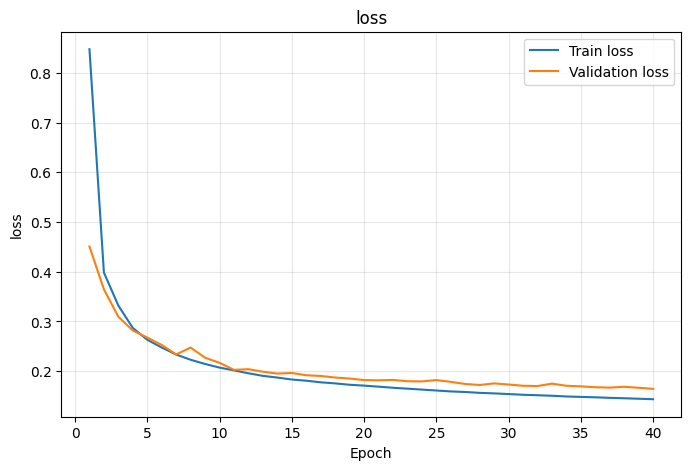

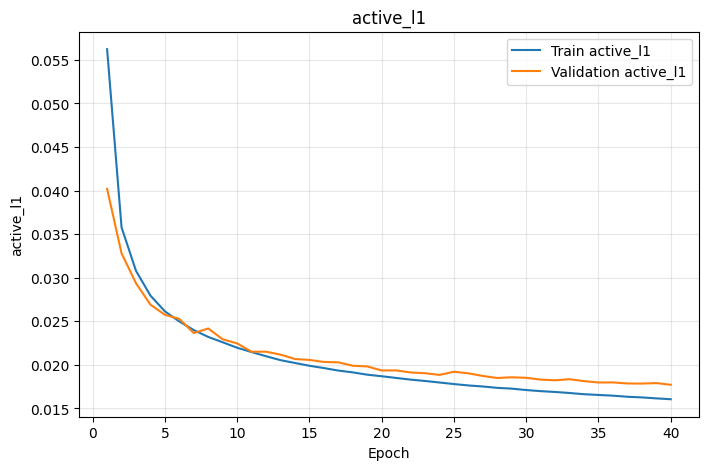

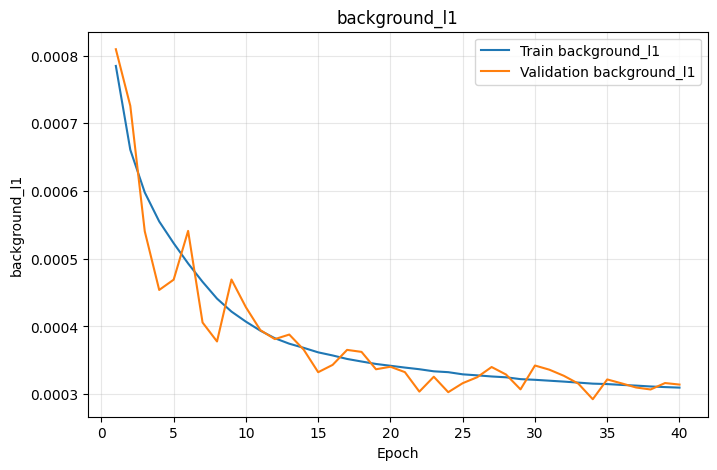

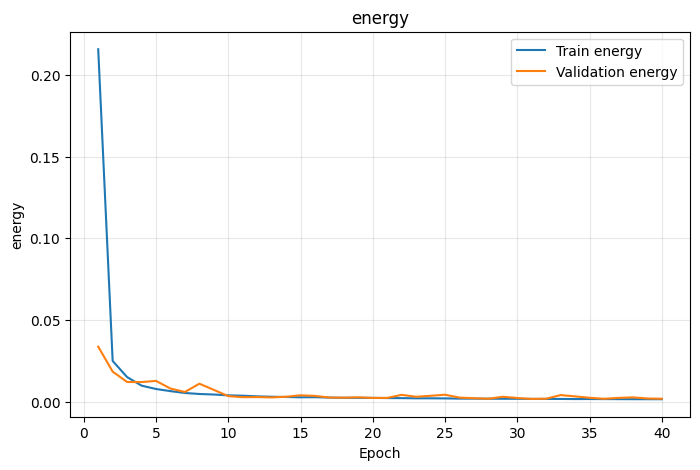

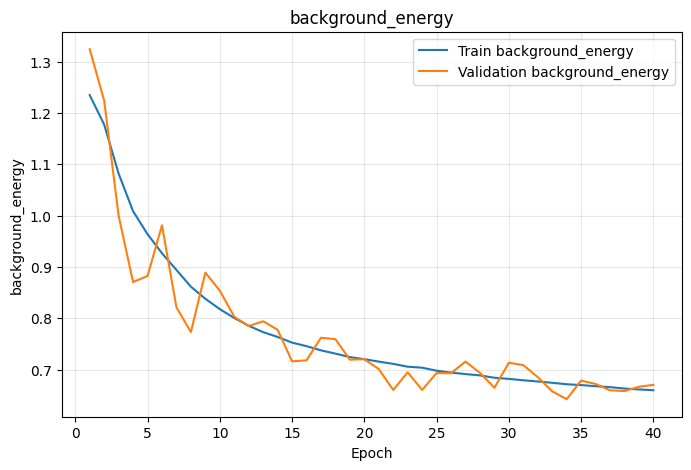

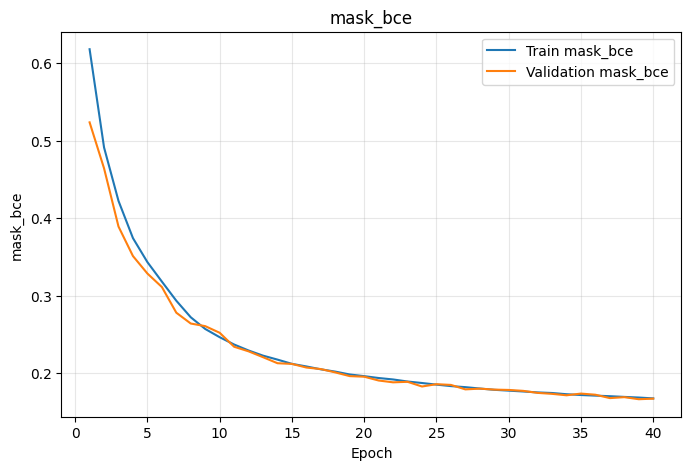

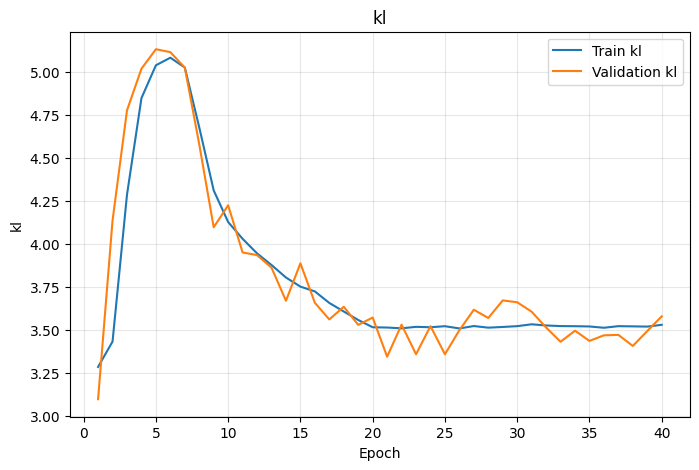

In [17]:
def plot_training_history(history):
    epochs = np.arange(1, len(history['train']) + 1)
    metrics = ['loss', 'active_l1', 'background_l1', 'energy', 'background_energy', 'mask_bce', 'kl']

    for metric in metrics:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, [item[metric] for item in history['train']], label=f'Train {metric}')
        plt.plot(epochs, [item[metric] for item in history['val']], label=f'Validation {metric}')
        plt.xlabel('Epoch')
        plt.ylabel(metric)
        plt.title(metric)
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

plot_training_history(vae_history)

In [18]:
def wasserstein_xy_per_channel(reconstruction, target, eps=1e-08):
    projection_x_reconstruction = reconstruction.sum(dim=2)
    projection_x_target = target.sum(dim=2)
    projection_y_reconstruction = reconstruction.sum(dim=3)
    projection_y_target = target.sum(dim=3)
    px_reconstruction = projection_x_reconstruction / (projection_x_reconstruction.sum(dim=-1, keepdim=True) + eps)
    px_target = projection_x_target / (projection_x_target.sum(dim=-1, keepdim=True) + eps)
    py_reconstruction = projection_y_reconstruction / (projection_y_reconstruction.sum(dim=-1, keepdim=True) + eps)
    py_target = projection_y_target / (projection_y_target.sum(dim=-1, keepdim=True) + eps)
    w1_x = torch.abs(torch.cumsum(px_reconstruction, dim=-1) - torch.cumsum(px_target, dim=-1)).sum(dim=-1)
    w1_y = torch.abs(torch.cumsum(py_reconstruction, dim=-1) - torch.cumsum(py_target, dim=-1)).sum(dim=-1)

    return (w1_x + w1_y).mean()


@torch.no_grad()
def evaluate_reconstructions(model, data_loader, device, hard_reconstruction=False):
    model.eval()
    totals = {
        'mae_01': 0.0,
        'mse_01': 0.0,
        'active_mae_01': 0.0,
        'background_mae_01': 0.0,
        'energy_relative_error': 0.0,
        'w1_xy': 0.0,
        'ssim': 0.0,
        'active_frac_real': 0.0,
        'active_frac_recon': 0.0,
    }
    n_examples = 0

    for images, _ in data_loader:
        images = images.to(device)
        reconstruction, _, _, _, _, mask_probability, intensity_01 = model(images, deterministic=True, return_components=True)
        images_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)

        if not hard_reconstruction:
            reconstruction_01 = ((reconstruction + 1.0) / 2.0).clamp(0.0, 1.0)
        else:
            channel_thresholds = get_occupancy_thresholds(mask_probability)
            hard_mask = (mask_probability > channel_thresholds).to(images.dtype)
            reconstruction_01 = hard_mask * intensity_01

        active_mask = (images_01 > ACTIVE_THRESHOLD_01).to(images.dtype)
        background_mask = 1.0 - active_mask
        absolute_error = torch.abs(reconstruction_01 - images_01)
        true_energy = images_01.sum(dim=(1, 2, 3))
        reconstructed_energy = reconstruction_01.sum(dim=(1, 2, 3))
        batch_metrics = {
            'mae_01': absolute_error.mean(),
            'mse_01': F.mse_loss(reconstruction_01, images_01),
            'active_mae_01': masked_mean(absolute_error, active_mask),
            'background_mae_01': masked_mean(absolute_error, background_mask),
            'energy_relative_error': (torch.abs(reconstructed_energy - true_energy) / true_energy.clamp_min(1e-08)).mean(),
            'w1_xy': wasserstein_xy_per_channel(reconstruction_01, images_01),
            'ssim': ssim(reconstruction_01, images_01, data_range=1.0, size_average=True),
            'active_frac_real': active_mask.mean(),
            'active_frac_recon': (reconstruction_01 > ACTIVE_THRESHOLD_01).float().mean(),
        }
        batch_size = images.size(0)

        for key, value in batch_metrics.items():
            totals[key] += value.item() * batch_size

        n_examples += batch_size

    return {key: value / n_examples for key, value in totals.items()}

In [19]:
soft_metrics = evaluate_reconstructions(model=vae_model, data_loader=test_loader, device=device, hard_reconstruction=False)
hard_metrics = evaluate_reconstructions(model=vae_model, data_loader=test_loader, device=device, hard_reconstruction=True)
print('RECONSTRUCCIÓN SUAVE')

for key, value in soft_metrics.items():
    print(f'{key:28s}: {value:.8f}')

print('\nRECONSTRUCCIÓN HARD — thresholds por canal')

for key, value in hard_metrics.items():
    print(f'{key:28s}: {value:.8f}')

RECONSTRUCCIÓN SUAVE
mae_01                      : 0.00137013
mse_01                      : 0.00017969
active_mae_01               : 0.01526782
background_mae_01           : 0.00069436
energy_relative_error       : 0.25633034
w1_xy                       : 1.84652520
ssim                        : 0.97379641
active_frac_real            : 0.04638578
active_frac_recon           : 0.19833278

RECONSTRUCCIÓN HARD — thresholds por canal
mae_01                      : 0.00110248
mse_01                      : 0.00022103
active_mae_01               : 0.01719882
background_mae_01           : 0.00031991
energy_relative_error       : 0.03151738
w1_xy                       : 1.39808278
ssim                        : 0.97507208
active_frac_real            : 0.04638578
active_frac_recon           : 0.04628913


In [20]:
@torch.no_grad()
def evaluate_occupancy_head(model, data_loader, device):
    model.eval()
    true_positive = torch.zeros(3, device=device)
    false_positive = torch.zeros(3, device=device)
    false_negative = torch.zeros(3, device=device)
    predicted_active_sum = torch.zeros(3, device=device)
    real_active_sum = torch.zeros(3, device=device)
    probability_sum = torch.zeros(3, device=device)
    pixel_count = 0

    for images, _ in data_loader:
        images = images.to(device)
        _, _, _, _, _, mask_probability, _ = model(images, deterministic=True, return_components=True)
        target_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
        true_mask = target_01 > ACTIVE_THRESHOLD_01
        channel_thresholds = get_occupancy_thresholds(mask_probability)
        predicted_mask = mask_probability > channel_thresholds
        true_positive += (predicted_mask & true_mask).sum(dim=(0, 2, 3))
        false_positive += (predicted_mask & ~true_mask).sum(dim=(0, 2, 3))
        false_negative += (~predicted_mask & true_mask).sum(dim=(0, 2, 3))
        predicted_active_sum += predicted_mask.float().sum(dim=(0, 2, 3))
        real_active_sum += true_mask.float().sum(dim=(0, 2, 3))
        probability_sum += mask_probability.sum(dim=(0, 2, 3))
        pixel_count += images.shape[0] * images.shape[-2] * images.shape[-1]

    precision = true_positive / (true_positive + false_positive).clamp_min(1.0)
    recall = true_positive / (true_positive + false_negative).clamp_min(1.0)
    iou = true_positive / (true_positive + false_positive + false_negative).clamp_min(1.0)

    return pd.DataFrame({
        'Canal': CHANNEL_NAMES,
        'Fracción activa real': (real_active_sum / pixel_count).cpu().numpy(),
        'Fracción activa máscara': (predicted_active_sum / pixel_count).cpu().numpy(),
        'Probabilidad media': (probability_sum / pixel_count).cpu().numpy(),
        'Precision': precision.cpu().numpy(),
        'Recall': recall.cpu().numpy(),
        'IoU': iou.cpu().numpy(),
    })

occupancy_results = evaluate_occupancy_head(model=vae_model, data_loader=test_loader, device=device)
display(occupancy_results.round(6))

,Canal,Fracción activa real,Fracción activa máscara,Probabilidad media,Precision,Recall,IoU
0,TRACKER,0.041333,0.041391,0.103558,0.564814,0.565613,0.393935
1,ECAL,0.053148,0.052866,0.107165,0.645237,0.641809,0.474403
2,HCAL,0.044677,0.044611,0.063493,0.884560,0.883254,0.791965


In [21]:
@torch.no_grad()
def show_reconstructions(model, data_loader, device, num_images=6, contrast=False, channel_order=(2, 0, 1)):
    model.eval()
    images, _ = next(iter(data_loader))
    images = images[:num_images].to(device)
    _, _, _, _, _, mask_probability, intensity_01 = model(images, deterministic=True, return_components=True)
    images_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
    channel_thresholds = get_occupancy_thresholds(mask_probability)
    hard_mask = (mask_probability > channel_thresholds).to(images.dtype)
    reconstruction_01 = hard_mask * intensity_01
    images_01 = images_01.cpu()
    reconstruction_01 = reconstruction_01.cpu()
    fig, axes = plt.subplots(2, num_images, figsize=(2.8 * num_images, 5.5))

    for index in range(num_images):
        original = images_01[index][list(channel_order)]
        reconstruction = reconstruction_01[index][list(channel_order)]

        if contrast:
            active_values = original[original > 1e-06]
            vmax = torch.quantile(active_values, 0.99).item() if active_values.numel() else 1.0
            vmax = max(vmax, 1e-08)
            original_display = (original / vmax).clamp(0.0, 1.0)
            reconstruction_display = (reconstruction / vmax).clamp(0.0, 1.0)
        else:
            original_display = original
            reconstruction_display = reconstruction

        axes[0, index].imshow(original_display.permute(1, 2, 0).numpy(), origin='lower')
        axes[0, index].set_title(f'Original\nE={original.sum().item():.2f}')
        axes[0, index].axis('off')
        axes[1, index].imshow(reconstruction_display.permute(1, 2, 0).numpy(), origin='lower')
        axes[1, index].set_title(f'Reconstrucción\nE={reconstruction.sum().item():.2f}')
        axes[1, index].axis('off')

    plt.tight_layout()
    plt.show()

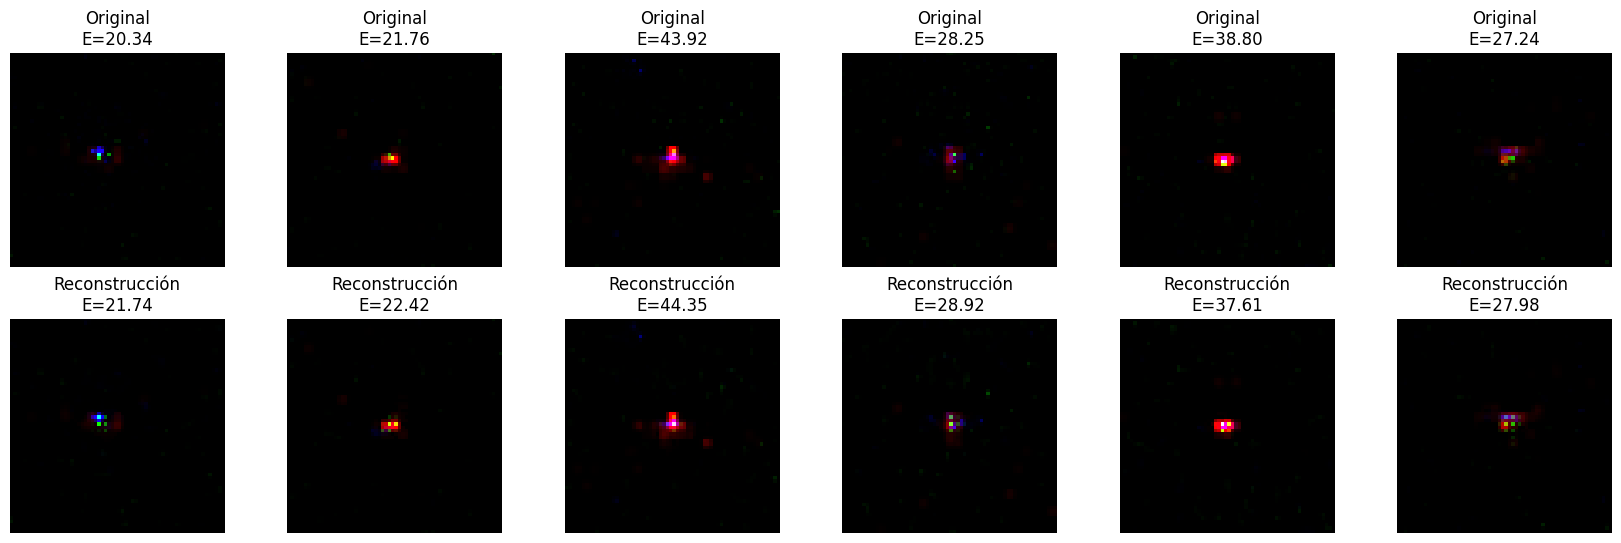

In [22]:
show_reconstructions(model=vae_model, data_loader=test_loader, device=device, contrast=False)

In [23]:
def empirical_w1(values_a, values_b):
    values_a = np.sort(np.asarray(values_a))
    values_b = np.sort(np.asarray(values_b))

    return np.mean(np.abs(values_a - values_b))


@torch.no_grad()
def collect_physics_diagnostics(model, data_loader, device, num_radial_bins=32):
    model.eval()
    energy_real_batches = []
    energy_recon_batches = []
    active_real_batches = []
    active_recon_batches = []
    max_real_batches = []
    max_recon_batches = []
    radial_real_sum = None
    radial_recon_sum = None
    radial_bin_index = None
    radial_centers = None

    for images, _ in data_loader:
        images = images.to(device)
        _, _, _, _, _, mask_probability, intensity_01 = model(images, deterministic=True, return_components=True)
        images_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
        channel_thresholds = get_occupancy_thresholds(mask_probability)
        hard_mask = (mask_probability > channel_thresholds).to(images.dtype)
        reconstruction_01 = hard_mask * intensity_01
        images_01 = images_01.cpu()
        reconstruction_01 = reconstruction_01.cpu()
        batch_size, channels, height, width = images_01.shape

        energy_real_batches.append(images_01.sum(dim=(-2, -1)).numpy())
        energy_recon_batches.append(reconstruction_01.sum(dim=(-2, -1)).numpy())
        active_real_batches.append((images_01 > ACTIVE_THRESHOLD_01).float().mean(dim=(-2, -1)).numpy())
        active_recon_batches.append((reconstruction_01 > ACTIVE_THRESHOLD_01).float().mean(dim=(-2, -1)).numpy())
        max_real_batches.append(images_01.amax(dim=(-2, -1)).numpy())
        max_recon_batches.append(reconstruction_01.amax(dim=(-2, -1)).numpy())

        if radial_bin_index is None:
            y, x = torch.meshgrid(torch.arange(height, dtype=torch.float32), torch.arange(width, dtype=torch.float32), indexing='ij')
            center_y = (height - 1) / 2.0
            center_x = (width - 1) / 2.0
            radius = torch.sqrt((y - center_y) ** 2 + (x - center_x) ** 2)
            radial_edges = torch.linspace(0.0, radius.max().item() + 1e-06, num_radial_bins + 1)
            radial_centers = (0.5 * (radial_edges[:-1] + radial_edges[1:])).numpy()
            radial_bin_index = (torch.bucketize(radius.reshape(-1), radial_edges, right=False) - 1).clamp(0, num_radial_bins - 1)
            radial_real_sum = torch.zeros(channels, num_radial_bins, dtype=torch.float64)
            radial_recon_sum = torch.zeros(channels, num_radial_bins, dtype=torch.float64)

        real_flat = images_01.reshape(batch_size, channels, -1).double()
        recon_flat = reconstruction_01.reshape(batch_size, channels, -1).double()

        for radial_bin in range(num_radial_bins):
            mask = radial_bin_index == radial_bin
            radial_real_sum[:, radial_bin] += real_flat[:, :, mask].sum(dim=(0, 2))
            radial_recon_sum[:, radial_bin] += recon_flat[:, :, mask].sum(dim=(0, 2))

    radial_real = (radial_real_sum / radial_real_sum.sum(dim=1, keepdim=True).clamp_min(1e-12)).numpy()
    radial_recon = (radial_recon_sum / radial_recon_sum.sum(dim=1, keepdim=True).clamp_min(1e-12)).numpy()

    return {
        'energy_real': np.concatenate(energy_real_batches),
        'energy_recon': np.concatenate(energy_recon_batches),
        'active_frac_real': np.concatenate(active_real_batches),
        'active_frac_recon': np.concatenate(active_recon_batches),
        'max_real': np.concatenate(max_real_batches),
        'max_recon': np.concatenate(max_recon_batches),
        'radial_centers': radial_centers,
        'radial_real': radial_real,
        'radial_recon': radial_recon,
    }


def summarize_physics_diagnostics(diagnostics):
    rows = []

    for channel, channel_name in enumerate(CHANNEL_NAMES):
        energy_real = diagnostics['energy_real'][:, channel]
        energy_recon = diagnostics['energy_recon'][:, channel]
        active_real = diagnostics['active_frac_real'][:, channel]
        active_recon = diagnostics['active_frac_recon'][:, channel]
        max_real = diagnostics['max_real'][:, channel]
        max_recon = diagnostics['max_recon'][:, channel]
        radial_real = diagnostics['radial_real'][channel]
        radial_recon = diagnostics['radial_recon'][channel]
        valid_energy = energy_real > 1e-06
        energy_relative_error = np.mean(np.abs(energy_recon[valid_energy] - energy_real[valid_energy]) / energy_real[valid_energy])
        energy_mean_real = energy_real.mean()
        energy_mean_recon = energy_recon.mean()

        rows.append({
            'Canal': channel_name,
            'E real media': energy_mean_real,
            'E recon media': energy_mean_recon,
            'Bias E (%)': 100.0 * (energy_mean_recon - energy_mean_real) / max(energy_mean_real, 1e-08),
            'Error relativo E (%)': 100.0 * energy_relative_error,
            'W1 energía': empirical_w1(energy_real, energy_recon),
            'Fracción activa real': active_real.mean(),
            'Fracción activa recon': active_recon.mean(),
            'Diferencia activa (p.p.)': 100.0 * (active_recon.mean() - active_real.mean()),
            'Máximo real medio': max_real.mean(),
            'Máximo recon medio': max_recon.mean(),
            'W1 máximo': empirical_w1(max_real, max_recon),
            'Radial L1': np.abs(radial_recon - radial_real).sum(),
            'Radial L2': np.sqrt(np.mean((radial_recon - radial_real) ** 2)),
        })

    return pd.DataFrame(rows)

In [24]:
diagnostics = collect_physics_diagnostics(model=vae_model, data_loader=test_loader, device=device, num_radial_bins=32)
physics_summary = summarize_physics_diagnostics(diagnostics)
display(physics_summary.round(6))

,Canal,E real media,E recon media,Bias E (%),Error relativo E (%),W1 energía,Fracción activa real,Fracción activa recon,Diferencia activa (p.p.),Máximo real medio,Máximo recon medio,W1 máximo,Radial L1,Radial L2
0,TRACKER,5.859265,5.982152,2.097321,7.164757,0.127645,0.041333,0.041391,0.005849,0.760318,0.770516,0.014465,0.066731,0.002997
1,ECAL,7.773422,7.762304,-0.143031,5.538616,0.046432,0.053148,0.052865,-0.028252,0.826301,0.827983,0.013343,0.025292,0.001651
2,HCAL,11.419732,11.729982,2.716791,4.657782,0.314847,0.044677,0.044611,-0.006592,0.523041,0.536219,0.013780,0.014939,0.000851


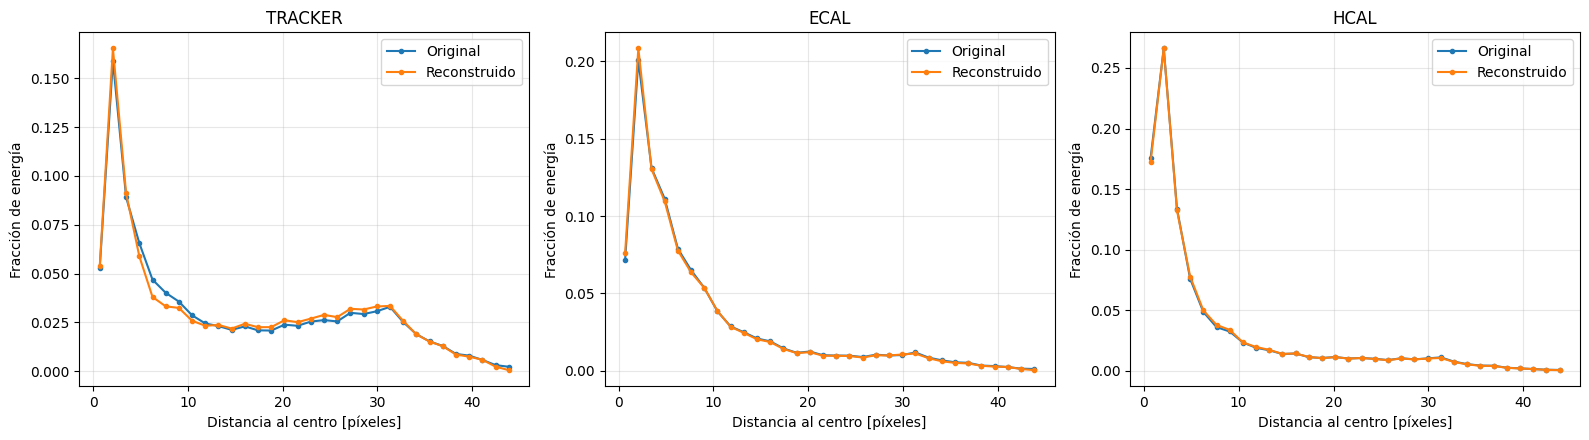

In [25]:
def plot_radial_profiles(diagnostics):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    for channel, channel_name in enumerate(CHANNEL_NAMES):
        axes[channel].plot(diagnostics['radial_centers'], diagnostics['radial_real'][channel], marker='o', markersize=3, label='Original')
        axes[channel].plot(diagnostics['radial_centers'], diagnostics['radial_recon'][channel], marker='o', markersize=3, label='Reconstruido')
        axes[channel].set_title(channel_name)
        axes[channel].set_xlabel('Distancia al centro [píxeles]')
        axes[channel].set_ylabel('Fracción de energía')
        axes[channel].legend()
        axes[channel].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_radial_profiles(diagnostics)

In [26]:
def common_histogram_bins(real_values, reconstructed_values, num_bins=50, upper_quantile=0.999):
    if num_bins < 1:
        raise ValueError('num_bins debe ser al menos 1.')

    if not 0.0 < upper_quantile <= 1.0:
        raise ValueError('upper_quantile debe estar en (0,1].')

    real_values = np.asarray(real_values, dtype=np.float64).reshape(-1)
    reconstructed_values = np.asarray(reconstructed_values, dtype=np.float64).reshape(-1)
    combined = np.concatenate([real_values, reconstructed_values])
    combined = combined[np.isfinite(combined)]

    if combined.size == 0:
        raise ValueError('No hay valores finitos para construir el histograma.')

    lower = combined.min()
    upper = np.quantile(combined, upper_quantile)

    if upper <= lower:
        upper = lower + 1e-06

    return np.linspace(lower, upper, num_bins + 1)

In [27]:
def plot_integrated_intensity_distributions(diagnostics, num_bins=50, upper_quantile=0.999):
    energy_real = np.asarray(diagnostics['energy_real'])
    energy_recon = np.asarray(diagnostics['energy_recon'])

    if energy_real.shape != energy_recon.shape:
        raise ValueError('Los arreglos real y reconstruido deben tener la misma forma.')

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    axes = axes.flatten()
    total_real = energy_real.sum(axis=1)
    total_recon = energy_recon.sum(axis=1)
    bins = common_histogram_bins(total_real, total_recon, num_bins=num_bins, upper_quantile=upper_quantile)
    real_weights = np.full(total_real.shape, 100.0 / len(total_real))
    recon_weights = np.full(total_recon.shape, 100.0 / len(total_recon))

    axes[0].hist(total_real, bins=bins, weights=real_weights, histtype='step', linewidth=2, label='Original')
    axes[0].hist(total_recon, bins=bins, weights=recon_weights, histtype='step', linewidth=2, label='Reconstruido')
    axes[0].set_title('Intensidad integrada total')
    axes[0].set_xlabel('Suma de intensidades normalizadas')
    axes[0].set_ylabel('Eventos por intervalo (%)')
    axes[0].set_xlim(bins[0], bins[-1])
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    for channel, channel_name in enumerate(CHANNEL_NAMES):
        real_values = energy_real[:, channel]
        recon_values = energy_recon[:, channel]
        bins = common_histogram_bins(real_values, recon_values, num_bins=num_bins, upper_quantile=upper_quantile)
        real_weights = np.full(real_values.shape, 100.0 / len(real_values))
        recon_weights = np.full(recon_values.shape, 100.0 / len(recon_values))
        axis = axes[channel + 1]

        axis.hist(real_values, bins=bins, weights=real_weights, histtype='step', linewidth=2, label='Original')
        axis.hist(recon_values, bins=bins, weights=recon_weights, histtype='step', linewidth=2, label='Reconstruido')
        axis.set_title(f'Intensidad integrada: {channel_name}')
        axis.set_xlabel('Suma de intensidades normalizadas')
        axis.set_ylabel('Eventos por intervalo (%)')
        axis.set_xlim(bins[0], bins[-1])
        axis.legend()
        axis.grid(alpha=0.3)

    fig.tight_layout()
    plt.show()

    return (fig, axes)

In [28]:
def plot_channel_distributions(diagnostics, metric, num_bins=50, upper_quantile=1.0, class_name=None):
    if metric == 'energy':
        real_data = np.asarray(diagnostics['energy_real'])
        generated_data = np.asarray(diagnostics['energy_recon'])
        title_prefix = 'Energía integrada'
        x_label = 'Suma de intensidades normalizadas'
    elif metric == 'active_fraction':
        real_data = np.asarray(diagnostics['active_frac_real']) * 100.0
        generated_data = np.asarray(diagnostics['active_frac_recon']) * 100.0
        title_prefix = 'Fracción activa'
        x_label = 'Píxeles activos por jet (%)'
    elif metric == 'maximum':
        real_data = np.asarray(diagnostics['max_real'])
        generated_data = np.asarray(diagnostics['max_recon'])
        title_prefix = 'Intensidad máxima'
        x_label = 'Intensidad máxima normalizada'
    else:
        raise ValueError("metric debe ser 'energy', 'active_fraction' o 'maximum'.")

    if real_data.shape != generated_data.shape:
        raise ValueError('Los arreglos reales y generados deben tener la misma forma.')

    if real_data.ndim != 2:
        raise ValueError('Los datos deben tener shape [N, C].')

    fig, axes = plt.subplots(1, len(CHANNEL_NAMES), figsize=(16, 4.5))

    for channel, channel_name in enumerate(CHANNEL_NAMES):
        real_values = real_data[:, channel]
        generated_values = generated_data[:, channel]
        bins = common_histogram_bins(real_values, generated_values, num_bins=num_bins, upper_quantile=upper_quantile)
        real_weights = np.full(real_values.shape, 100.0 / len(real_values))
        generated_weights = np.full(generated_values.shape, 100.0 / len(generated_values))

        axes[channel].hist(real_values, bins=bins, weights=real_weights, histtype='step', linewidth=2, label='Original')
        axes[channel].hist(generated_values, bins=bins, weights=generated_weights, histtype='step', linewidth=2, label='Generado')

        if class_name is None:
            title = f'{title_prefix}: {channel_name}'
        else:
            title = f'{title_prefix}: {channel_name} — {class_name}'

        axes[channel].set_title(title)
        axes[channel].set_xlabel(x_label)
        axes[channel].set_ylabel('Jets por intervalo (%)')
        axes[channel].set_xlim(bins[0], bins[-1])
        axes[channel].legend()
        axes[channel].grid(alpha=0.3)

    fig.tight_layout()
    plt.show()

    return (fig, axes)

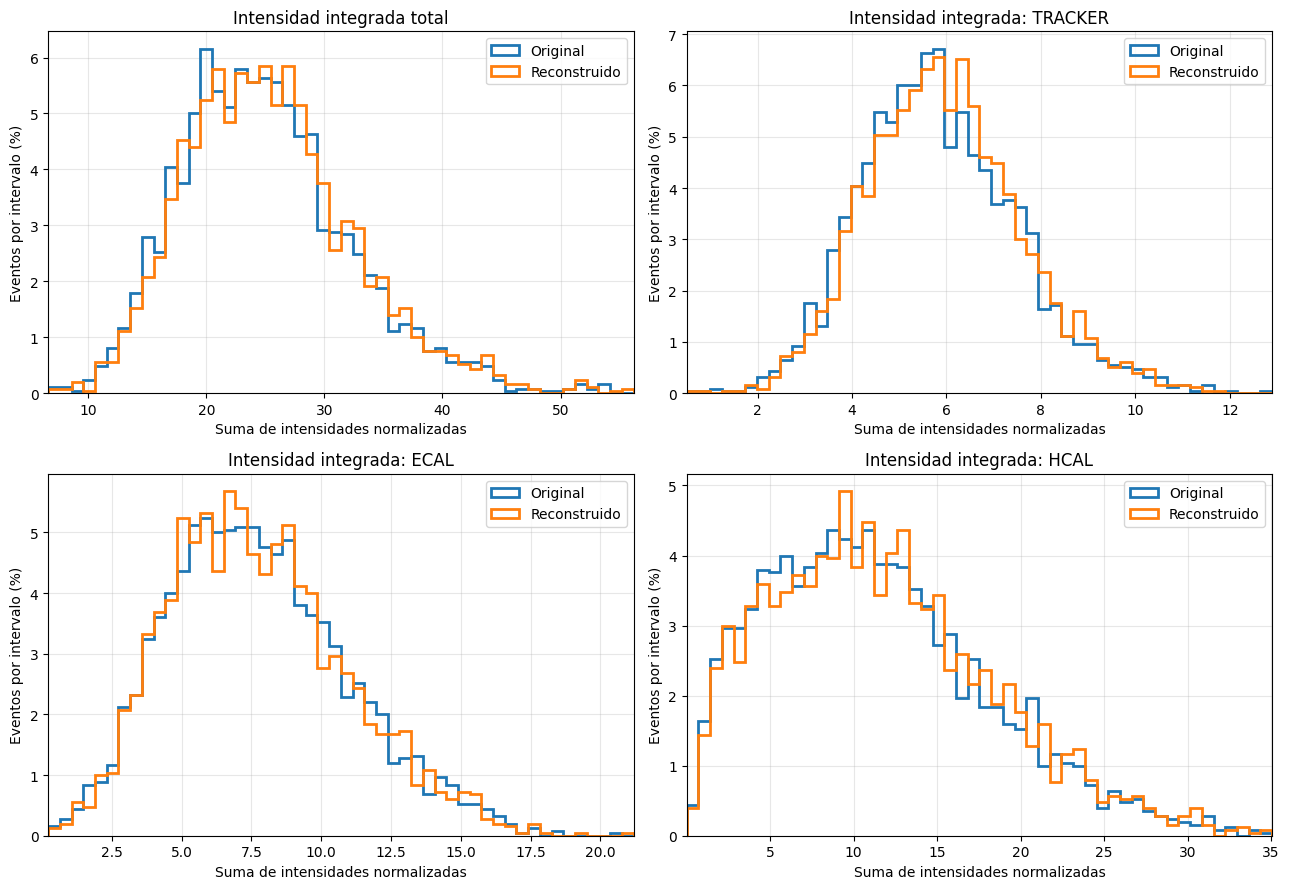

(<Figure size 1300x900 with 4 Axes>,
 array([<Axes: title={'center': 'Intensidad integrada total'}, xlabel='Suma de intensidades normalizadas', ylabel='Eventos por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad integrada: TRACKER'}, xlabel='Suma de intensidades normalizadas', ylabel='Eventos por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad integrada: ECAL'}, xlabel='Suma de intensidades normalizadas', ylabel='Eventos por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad integrada: HCAL'}, xlabel='Suma de intensidades normalizadas', ylabel='Eventos por intervalo (%)'>],
       dtype=object))

In [29]:
plot_integrated_intensity_distributions(diagnostics, num_bins=50, upper_quantile=0.999)

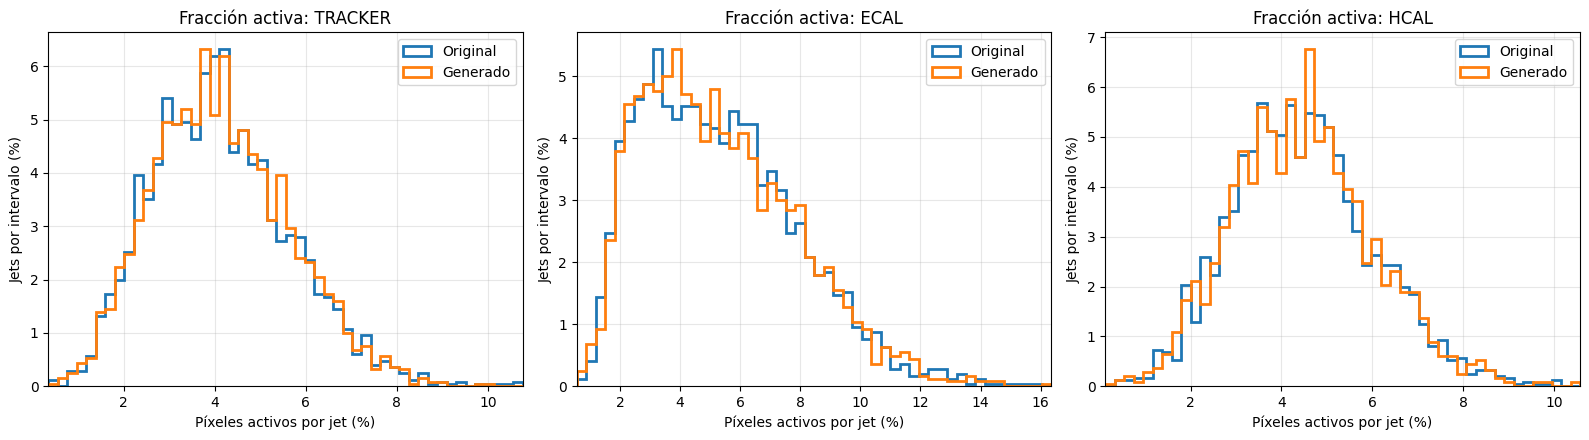

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Fracción activa: TRACKER'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: ECAL'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: HCAL'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [30]:
plot_channel_distributions(diagnostics, metric='active_fraction', num_bins=50)

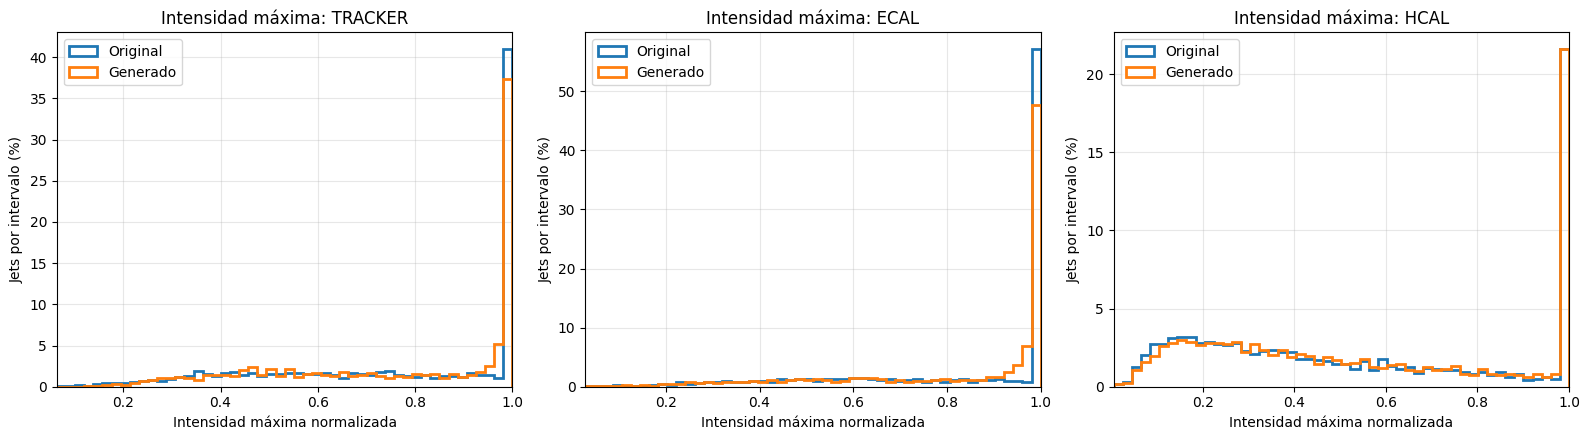

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Intensidad máxima: TRACKER'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: ECAL'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: HCAL'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [31]:
plot_channel_distributions(diagnostics, metric='maximum', num_bins=50, upper_quantile=1.0)

In [32]:
@torch.no_grad()
def inspect_vae_latents(model, data_loader, device):
    model.eval()
    mu_batches = []
    log_var_batches = []
    z_batches = []

    for images, _ in data_loader:
        images = images.to(device)
        mu, log_var = model.encode(images)
        z = model.reparameterize(mu, log_var)

        mu_batches.append(mu.cpu())
        log_var_batches.append(log_var.cpu())
        z_batches.append(z.cpu())

    mu_all = torch.cat(mu_batches)
    log_var_all = torch.cat(log_var_batches)
    z_all = torch.cat(z_batches)
    rows = []

    for channel in range(mu_all.shape[1]):
        rows.append({
            'Canal latente': channel,
            'mu media': mu_all[:, channel].mean().item(),
            'mu std': mu_all[:, channel].std().item(),
            'logvar media': log_var_all[:, channel].mean().item(),
            'logvar std': log_var_all[:, channel].std().item(),
            'z media': z_all[:, channel].mean().item(),
            'z std': z_all[:, channel].std().item(),
            'z mínimo': z_all[:, channel].min().item(),
            'z máximo': z_all[:, channel].max().item(),
        })

    global_stats = {
        'mu_mean': mu_all.mean().item(),
        'mu_std': mu_all.std().item(),
        'logvar_mean': log_var_all.mean().item(),
        'logvar_std': log_var_all.std().item(),
        'z_mean': z_all.mean().item(),
        'z_std': z_all.std().item(),
        'latent_shape': tuple(z_all.shape),
    }

    return (pd.DataFrame(rows), global_stats)

latent_channel_stats, latent_global_stats = inspect_vae_latents(model=vae_model, data_loader=test_loader, device=device)
display(latent_channel_stats.round(6))
print('\nESTADÍSTICAS GLOBALES')

for key, value in latent_global_stats.items():
    print(f'{key}: {value}')

,Canal latente,mu media,mu std,logvar media,logvar std,z media,z std,z mínimo,z máximo
0,0,-1.063291,1.038334,-6.912945,0.910141,-1.063292,1.038990,-8.296253,19.025841
1,1,-0.644119,1.010691,-6.751042,0.986519,-0.644094,1.011518,-7.901273,18.707117
2,2,0.828359,0.777308,-6.340217,0.971909,0.828392,0.778898,-14.094224,9.296882
3,3,-0.602212,0.850946,-6.591211,0.868626,-0.602253,0.852115,-10.047521,13.862465



ESTADÍSTICAS GLOBALES
mu_mean: -0.3703157901763916
mu_std: 1.1697999238967896
logvar_mean: -6.648854732513428
logvar_std: 0.9590955376625061
z_mean: -0.37031182646751404
z_std: 1.1706100702285767
latent_shape: (2500, 4, 16, 16)


In [33]:
LDM_BATCH_SIZE = 64
LDM_ENCODING_BATCH_SIZE = 64
vae_model.eval()

for parameter in vae_model.parameters():
    parameter.requires_grad_(False)

print('VAE congelado para el entrenamiento del LDM.')

VAE congelado para el entrenamiento del LDM.


In [34]:
@torch.no_grad()
def encode_dataset_to_mu(model, dataset, device, batch_size=64):
    model.eval()
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    mu_batches = []
    label_batches = []

    for images, labels in tqdm(data_loader, desc='Codificando latentes'):
        images = images.to(device, non_blocking=True)
        mu, _ = model.encode(images)
        mu_batches.append(mu.detach().cpu())
        label_batches.append(labels.detach().cpu())

    mu_all = torch.cat(mu_batches, dim=0)
    labels_all = torch.cat(label_batches, dim=0)

    return (mu_all, labels_all)

In [35]:
ldm_train_mu, ldm_train_labels = encode_dataset_to_mu(model=vae_model, dataset=train_dataset, device=device, batch_size=LDM_ENCODING_BATCH_SIZE)
ldm_val_mu, ldm_val_labels = encode_dataset_to_mu(model=vae_model, dataset=val_dataset, device=device, batch_size=LDM_ENCODING_BATCH_SIZE)
ldm_test_mu, ldm_test_labels = encode_dataset_to_mu(model=vae_model, dataset=test_dataset, device=device, batch_size=LDM_ENCODING_BATCH_SIZE)

print('Train:', ldm_train_mu.shape)
print('Validation:', ldm_val_mu.shape)
print('Test:', ldm_test_mu.shape)

Codificando latentes: 100%|██████████| 40/40 [00:00<00:00, 51.24it/s]

Train: torch.Size([10000, 4, 16, 16])
Validation: torch.Size([2500, 4, 16, 16])
Test: torch.Size([2500, 4, 16, 16])


In [36]:
latent_mean_train = ldm_train_mu.mean(dim=(0, 2, 3), keepdim=True)
latent_std_train = ldm_train_mu.std(dim=(0, 2, 3), keepdim=True, unbiased=False).clamp_min(1e-06)
print('Media latente de entrenamiento:', latent_mean_train.flatten().numpy())
print('Std latente de entrenamiento:', latent_std_train.flatten().numpy())

Media latente de entrenamiento: [-1.065183   -0.64281386  0.8292197  -0.60205144]
Std latente de entrenamiento: [1.0347776  1.0140498  0.78007245 0.85224116]


In [37]:
def standardize_latents(latent_tensor, latent_mean, latent_std):
    return (latent_tensor - latent_mean) / latent_std.clamp_min(1e-06)

In [38]:
ldm_train_latents = standardize_latents(ldm_train_mu, latent_mean_train, latent_std_train)
ldm_val_latents = standardize_latents(ldm_val_mu, latent_mean_train, latent_std_train)
ldm_test_latents = standardize_latents(ldm_test_mu, latent_mean_train, latent_std_train)

In [39]:
del ldm_train_mu
del ldm_val_mu
del ldm_test_mu

In [40]:
def summarize_latent_tensor(latent_tensor, name):
    channel_mean = latent_tensor.mean(dim=(0, 2, 3))
    channel_std = latent_tensor.std(dim=(0, 2, 3), unbiased=False)
    absolute_latents = latent_tensor.abs()

    print(f'\n{name}')
    print('Shape:', tuple(latent_tensor.shape))
    print('Media por canal:', channel_mean.numpy())
    print('Std por canal:', channel_std.numpy())
    print('Media global:', latent_tensor.mean().item())
    print('Std global:', latent_tensor.std(unbiased=False).item())
    print('Mínimo:', latent_tensor.min().item())
    print('Máximo:', latent_tensor.max().item())
    print('Fracción |z| > 4:', (absolute_latents > 4.0).float().mean().item())
    print('Fracción |z| > 6:', (absolute_latents > 6.0).float().mean().item())

In [41]:
summarize_latent_tensor(ldm_train_latents, 'LATENTES DE ENTRENAMIENTO')
summarize_latent_tensor(ldm_val_latents, 'LATENTES DE VALIDACIÓN')
summarize_latent_tensor(ldm_test_latents, 'LATENTES DE TEST')


LATENTES DE ENTRENAMIENTO
Shape: (10000, 4, 16, 16)
Media por canal: [ 2.3272262e-06  1.4475598e-06 -1.9278228e-07  1.7276809e-06]
Std por canal: [1.         0.99999994 1.         0.99999994]
Media global: 1.3257980526759638e-06
Std global: 1.0
Mínimo: -20.84419822692871
Máximo: 21.923025131225586
Fracción |z| > 4: 0.00910634733736515
Fracción |z| > 6: 0.003725390648469329

LATENTES DE VALIDACIÓN
Shape: (2500, 4, 16, 16)
Media por canal: [ 0.00084296 -0.00137886 -0.00233332 -0.00041057]
Std por canal: [1.0002276  1.0007932  0.9940807  0.99733704]
Media global: -0.0008199462899938226
Std global: 0.9981139302253723
Mínimo: -18.906015396118164
Máximo: 19.29391098022461
Fracción |z| > 4: 0.009114062413573265
Fracción |z| > 6: 0.0036746093537658453

LATENTES DE TEST
Shape: (2500, 4, 16, 16)
Media por canal: [ 0.00182807 -0.0012871  -0.00110344 -0.00018797]
Std por canal: [1.003436   0.9966871  0.9964558  0.99847895]
Media global: -0.00018760976672638208
Std global: 0.9987691640853882
Mínim

In [42]:
ldm_train_dataset = TensorDataset(ldm_train_latents, ldm_train_labels)
ldm_val_dataset = TensorDataset(ldm_val_latents, ldm_val_labels)
ldm_test_dataset = TensorDataset(ldm_test_latents, ldm_test_labels)

In [43]:
ldm_train_generator = torch.Generator().manual_seed(SEED)
ldm_train_loader = DataLoader(ldm_train_dataset, batch_size=LDM_BATCH_SIZE, shuffle=True, num_workers=0, generator=ldm_train_generator)
ldm_val_loader = DataLoader(ldm_val_dataset, batch_size=LDM_BATCH_SIZE, shuffle=False, num_workers=0)
ldm_test_loader = DataLoader(ldm_test_dataset, batch_size=LDM_BATCH_SIZE, shuffle=False, num_workers=0)

In [44]:
def build_fixed_validation_conditions(data_loader, num_timesteps, seed=SEED + 1000):
    generator = torch.Generator(device='cpu')
    generator.manual_seed(seed)
    fixed_conditions = []

    for z0, _ in data_loader:
        batch_size = z0.shape[0]
        timesteps = torch.randint(low=0, high=num_timesteps, size=(batch_size,), generator=generator, dtype=torch.long)
        noise = torch.randn(z0.shape, generator=generator, dtype=torch.float32)

        fixed_conditions.append((timesteps, noise))

    return fixed_conditions

In [45]:
unique_labels, label_counts = torch.unique(ldm_train_labels, return_counts=True)
print('Etiquetas presentes:', unique_labels.tolist())
print('Número de ejemplos:', label_counts.tolist())

for label, count in zip(unique_labels.tolist(), label_counts.tolist()):
    print(f'Clase {label}: {count} ejemplos ({100.0 * count / len(ldm_train_labels):.2f}%)')

Etiquetas presentes: [0, 1]
Número de ejemplos: [5038, 4962]
Clase 0: 5038 ejemplos (50.38%)
Clase 1: 4962 ejemplos (49.62%)


## Conditional Latent Diffusion Backbone

The shared diffusion backbone predicts the velocity target from a noisy latent, a timestep embedding, and a class embedding. Its reduced U-Net follows the spatial path $16\times16 \rightarrow 8\times8 \rightarrow 4\times4 \rightarrow 2\times2$ and then mirrors it in the decoder.

In [46]:
class LinearNoiseScheduler:
    def __init__(self, num_timesteps, beta_s, beta_e, device):
        self.num_timesteps = num_timesteps
        self.beta_s = beta_s
        self.beta_e = beta_e
        self.device = device

        self.betas = torch.linspace(beta_s, beta_e, num_timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alpha_cum_prod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_cum_prod = torch.sqrt(self.alpha_cum_prod)
        self.sqrt_one_minus_alpha_cum_prod = torch.sqrt(1.0 - self.alpha_cum_prod)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
        alpha_cum_prod_prev = torch.cat([torch.tensor([1.0], device=device), self.alpha_cum_prod[:-1]], dim=0)
        self.posterior_variance = (self.betas * (1.0 - alpha_cum_prod_prev) / (1.0 - self.alpha_cum_prod))
        self.posterior_mean_coef1 = (self.betas * torch.sqrt(alpha_cum_prod_prev) / (1.0 - self.alpha_cum_prod))
        self.posterior_mean_coef2 = (torch.sqrt(self.alphas) * (1.0 - alpha_cum_prod_prev) / (1.0 - self.alpha_cum_prod))

    def sample_timesteps(self, batch_size):
        return torch.randint(0, self.num_timesteps, (batch_size,), device=self.device)

    def _extract(self, arr, t, x_shape):
        out = arr.gather(0, t)

        return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))

    def add_noise(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)

        sqrt_alpha_cum_prod_t = self._extract(self.sqrt_alpha_cum_prod, t, x0.shape)
        sqrt_one_minus_alpha_cum_prod_t = self._extract(self.sqrt_one_minus_alpha_cum_prod, t, x0.shape)
        xt = sqrt_alpha_cum_prod_t * x0 + sqrt_one_minus_alpha_cum_prod_t * noise

        return xt, noise

    @torch.no_grad()
    def sample_prev_timestep_v(self, xt, v_pred, t, clip_x0=True):

        if isinstance(t, torch.Tensor):
            t_int = int(t.item())
        else:
            t_int = int(t)

        sqrt_alpha_bar_t = self.sqrt_alpha_cum_prod[t_int]
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_cum_prod[t_int]
        x0_pred = sqrt_alpha_bar_t * xt - sqrt_one_minus_alpha_bar_t * v_pred

        if clip_x0:
            x0_pred = torch.clamp(x0_pred, -1.0, 1.0)

        if t_int == 0:
            return x0_pred, x0_pred

        posterior_mean = (self.posterior_mean_coef1[t_int] * x0_pred + self.posterior_mean_coef2[t_int] * xt)
        posterior_var = self.posterior_variance[t_int]
        noise = torch.randn_like(xt)
        x_prev = posterior_mean + torch.sqrt(posterior_var) * noise

        return x_prev, x0_pred

In [47]:
def get_num_groups(channels, max_groups=8):
    for g in reversed(range(1, max_groups + 1)):
        if channels % g == 0:
            return g

    return 1


def sinusoidal_time_embedding(timesteps, dim):
    if timesteps.dim() == 0:
        timesteps = timesteps[None]

    timesteps = timesteps.float()
    half_dim = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half_dim, device=timesteps.device).float() / max(half_dim - 1, 1))
    args = timesteps[:, None] * freqs[None, :]
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))

    return emb


class TimeEmbedding(nn.Module):
    def __init__(self, t_emb_dim):
        super().__init__()

        self.t_emb_dim = t_emb_dim

        self.mlp = nn.Sequential(
            nn.Linear(t_emb_dim, 4 * t_emb_dim),
            nn.SiLU(),
            nn.Linear(4 * t_emb_dim, t_emb_dim)
        )

    def forward(self, t):
        t_emb = sinusoidal_time_embedding(t, self.t_emb_dim)

        return self.mlp(t_emb)

In [48]:
class SimpleConditionedConvBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        condition_dim,
    ):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1,
        )

        self.norm = nn.GroupNorm(
            get_num_groups(out_channels),
            out_channels,
        )

        self.condition_projection = nn.Linear(
            condition_dim,
            out_channels,
        )

    def forward(
        self,
        x,
        condition_embedding,
    ):
        h = self.conv(x)

        h = self.norm(h)

        condition = (
            self.condition_projection(
                F.silu(condition_embedding)
            )
            [:, :, None, None]
        )

        h = h + condition

        h = F.silu(h)

        return h


class ReducedDownBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        condition_dim,
    ):
        super().__init__()

        self.block = SimpleConditionedConvBlock(
            in_channels=in_channels,
            out_channels=out_channels,
            condition_dim=condition_dim,
        )

        self.downsample = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1,
        )

    def forward(
        self,
        x,
        condition_embedding,
    ):

        x = self.block(
            x,
            condition_embedding,
        )

        skip = x

        x = self.downsample(x)

        return x, skip


class ReducedUpBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels,
        condition_dim,
    ):
        super().__init__()

        self.upsample = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1,
        )

        self.block = SimpleConditionedConvBlock(
            in_channels=(
                out_channels
                + skip_channels
            ),
            out_channels=out_channels,
            condition_dim=condition_dim,
        )

    def forward(
        self,
        x,
        skip,
        condition_embedding,
    ):

        x = self.upsample(x)

        if x.shape[-2:] != skip.shape[-2:]:

            x = F.interpolate(
                x,
                size=skip.shape[-2:],
                mode="nearest",
            )

        x = torch.cat(
            [x, skip],
            dim=1,
        )

        x = self.block(
            x,
            condition_embedding,
        )

        return x


class ReducedConditionalUNET(nn.Module):

    def __init__(
        self,
        im_channels=4,
        base_channels=32,
        channel_mults=(1, 2, 4),
        t_emb_dim=128,
        num_classes=2,
        time_embedding_module=None,
    ):
        super().__init__()

        self.im_channels = im_channels
        self.num_classes = num_classes
        self.condition_dim = t_emb_dim

        if time_embedding_module is None:

            self.time_mlp = TimeEmbedding(
                t_emb_dim
            )

        else:

            self.time_mlp = (
                time_embedding_module
            )

        self.class_embedding = nn.Embedding(
            num_classes,
            t_emb_dim,
        )

        nn.init.normal_(
            self.class_embedding.weight,
            mean=0.0,
            std=0.02,
        )

        self.conv_in = nn.Conv2d(
            im_channels,
            base_channels,
            kernel_size=3,
            padding=1,
        )

        channels = [
            base_channels * multiplier
            for multiplier
            in channel_mults
        ]

        self.channels = channels

        self.downs = nn.ModuleList()

        in_channels = base_channels

        for out_channels in channels:

            self.downs.append(
                ReducedDownBlock(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    condition_dim=t_emb_dim,
                )
            )

            in_channels = out_channels

        mid_channels = channels[-1]

        self.bottleneck_channels = (
            mid_channels
        )

        self.mid = SimpleConditionedConvBlock(
            in_channels=mid_channels,
            out_channels=mid_channels,
            condition_dim=t_emb_dim,
        )

        self.ups = nn.ModuleList()

        reversed_channels = list(
            reversed(channels)
        )

        in_channels = mid_channels

        for i, skip_channels in enumerate(
            reversed_channels
        ):

            if i < (
                len(reversed_channels) - 1
            ):

                out_channels = (
                    reversed_channels[
                        i + 1
                    ]
                )

            else:

                out_channels = (
                    base_channels
                )

            self.ups.append(
                ReducedUpBlock(
                    in_channels=in_channels,
                    skip_channels=skip_channels,
                    out_channels=out_channels,
                    condition_dim=t_emb_dim,
                )
            )

            in_channels = out_channels

        self.norm_out = nn.GroupNorm(
            get_num_groups(
                base_channels
            ),
            base_channels,
        )

        self.conv_out = nn.Conv2d(
            base_channels,
            im_channels,
            kernel_size=3,
            padding=1,
        )

    def forward(
        self,
        x,
        t,
        labels,
    ):

        time_embedding = (
            self.time_mlp(t)
        )

        labels = labels.long()

        class_embedding = (
            self.class_embedding(
                labels
            )
        )

        condition_embedding = (
            time_embedding
            + class_embedding
        )

        x = self.conv_in(x)

        skips = []

        for down in self.downs:

            x, skip = down(
                x,
                condition_embedding,
            )

            skips.append(skip)

        x = self.mid(
            x,
            condition_embedding,
        )

        for up in self.ups:

            skip = skips.pop()

            x = up(
                x,
                skip,
                condition_embedding,
            )

        x = self.norm_out(x)

        x = F.silu(x)

        return self.conv_out(x)

In [49]:
LDM_NUM_TIMESTEPS = 1000
LDM_BETA_START = 0.0001
LDM_BETA_END = 0.02
LDM_NUM_EPOCHS = 100
LDM_LEARNING_RATE = 0.0001
LDM_GRAD_CLIP = 1.0
NUM_CLASSES = 2

In [50]:
seed_everything(SEED)
ldm_scheduler = LinearNoiseScheduler(num_timesteps=LDM_NUM_TIMESTEPS, beta_s=LDM_BETA_START, beta_e=LDM_BETA_END, device=device)
FIXED_LDM_VAL_CONDITIONS = build_fixed_validation_conditions(data_loader=ldm_val_loader, num_timesteps=LDM_NUM_TIMESTEPS)
print('Condiciones fijas de validación:', len(FIXED_LDM_VAL_CONDITIONS))
ldm_model_first = ReducedConditionalUNET(im_channels=4, base_channels=32, channel_mults=(1, 2, 4), t_emb_dim=128, num_classes=NUM_CLASSES).to(device)
ldm_num_parameters = sum((parameter.numel() for parameter in ldm_model_first.parameters() if parameter.requires_grad))
print(f'Parámetros entrenables del LDM: {ldm_num_parameters:,}')
print('Shape esperada:', '(B, 4, 16, 16)')

Condiciones fijas de validación: 40
Parámetros entrenables del LDM: 1,127,876
Shape esperada: (B, 4, 16, 16)


In [51]:
ldm_model_first.eval()
z_test = ldm_train_latents[:2].float().to(device)
t_test = torch.tensor([100, 700], dtype=torch.long, device=device)
labels_test = ldm_train_labels[:2].long().to(device)
bottleneck_shapes = {}


def bottleneck_hook(module, inputs, output):
    bottleneck_shapes['output'] = tuple(output.shape)

hook_handle = ldm_model_first.mid.register_forward_hook(bottleneck_hook)

with torch.no_grad():
    output_test = ldm_model_first(z_test, t_test, labels_test)

hook_handle.remove()
print('Input:', z_test.shape)
print('Bottleneck:', bottleneck_shapes['output'])
print('Output:', output_test.shape)
print('Valores finitos:', torch.isfinite(output_test).all().item())
print('Parámetros:', sum((p.numel() for p in ldm_model_first.parameters() if p.requires_grad)))

Input: torch.Size([2, 4, 16, 16])
Bottleneck: (2, 128, 2, 2)
Output: torch.Size([2, 4, 16, 16])
Valores finitos: True
Parámetros: 1127876


In [52]:
ldm_model_first.zero_grad(set_to_none=True)
ldm_model_first.eval()

ReducedConditionalUNET(
  (time_mlp): TimeEmbedding(
    (mlp): Sequential(
      (0): Linear(in_features=128, out_features=512, bias=True)
      (1): SiLU()
      (2): Linear(in_features=512, out_features=128, bias=True)
    )
  )
  (class_embedding): Embedding(2, 128)
  (conv_in): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (downs): ModuleList(
    (0): ReducedDownBlock(
      (block): SimpleConditionedConvBlock(
        (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm): GroupNorm(8, 32, eps=1e-05, affine=True)
        (condition_projection): Linear(in_features=128, out_features=32, bias=True)
      )
      (downsample): Conv2d(32, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    )
    (1): ReducedDownBlock(
      (block): SimpleConditionedConvBlock(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm): GroupNorm(8, 64, eps=1e-05, affine=True)
        (condition_project

In [53]:
def compute_v_target(z0, noise, timesteps, scheduler):
    sqrt_alpha_bar = scheduler._extract(scheduler.sqrt_alpha_cum_prod, timesteps, z0.shape)
    sqrt_one_minus_alpha_bar = scheduler._extract(scheduler.sqrt_one_minus_alpha_cum_prod, timesteps, z0.shape)
    v_target = sqrt_alpha_bar * noise - sqrt_one_minus_alpha_bar * z0

    return v_target

In [54]:
ldm_model_first.train()
z_batch = ldm_train_latents[:2].float().to(device)
labels_batch = ldm_train_labels[:2].long().to(device)
timesteps_batch = torch.tensor([100, 700], dtype=torch.long, device=device)
noise_batch = torch.randn_like(z_batch)
z_noisy, noise_used = ldm_scheduler.add_noise(z_batch, timesteps_batch, noise_batch)
v_target_batch = compute_v_target(z0=z_batch, noise=noise_used, timesteps=timesteps_batch, scheduler=ldm_scheduler)

ldm_model_first.zero_grad(set_to_none=True)
v_prediction_batch = ldm_model_first(z_noisy, timesteps_batch, labels_batch)
test_loss = F.mse_loss(v_prediction_batch, v_target_batch)
test_loss.backward()
parameters_without_gradient = [name for name, parameter in ldm_model_first.named_parameters() if parameter.requires_grad and parameter.grad is None]
print('Test loss:', test_loss.item())
print('Parámetros sin gradiente:', parameters_without_gradient)

Test loss: 1.065085530281067
Parámetros sin gradiente: []


In [55]:
def latent_v_loss(z0, z_t, v_prediction, v_target, timesteps, scheduler, tail_loss_weight=0.15):
    v_loss = F.mse_loss(v_prediction, v_target)
    sqrt_alpha_bar = scheduler._extract(scheduler.sqrt_alpha_cum_prod, timesteps, z0.shape)
    sqrt_one_minus_alpha_bar = scheduler._extract(scheduler.sqrt_one_minus_alpha_cum_prod, timesteps, z0.shape)
    z0_prediction = sqrt_alpha_bar * z_t - sqrt_one_minus_alpha_bar * v_prediction
    tail_weight = 1.0 + 2.0 * ((z0.abs() - 2.0) / 4.0).clamp(min=0.0, max=1.0)
    reconstruction_error = F.smooth_l1_loss(z0_prediction, z0, reduction='none')
    tail_loss = (tail_weight * reconstruction_error).mean()
    total_loss = v_loss + tail_loss_weight * tail_loss

    return (total_loss, {'loss': total_loss, 'v_loss': v_loss, 'tail_loss': tail_loss})

In [56]:
@torch.no_grad()
def evaluate_latent_ddpm_epoch(model, data_loader, scheduler, device, fixed_conditions):
    model.eval()
    total_loss = 0.0
    number_examples = 0

    for batch_index, (z0, labels) in enumerate(data_loader):
        z0 = z0.float().to(device, non_blocking=True)
        labels = labels.long().to(device, non_blocking=True)

        if not torch.isfinite(z0).all():
            raise RuntimeError(f'El batch {batch_index} contiene NaN o infinitos en z0.')

        batch_size = z0.shape[0]
        timesteps_cpu, noise_cpu = fixed_conditions[batch_index]
        timesteps = timesteps_cpu.to(device=device, dtype=torch.long)
        noise = noise_cpu.to(device=device, dtype=z0.dtype)
        noisy_latents, noise_used = scheduler.add_noise(z0, timesteps, noise)

        if not torch.isfinite(noisy_latents).all():
            raise RuntimeError(f'El batch {batch_index} contiene NaN o infinitos después de add_noise.')

        v_target = compute_v_target(z0=z0, noise=noise_used, timesteps=timesteps, scheduler=scheduler)

        if not torch.isfinite(v_target).all():
            raise RuntimeError(f'El batch {batch_index} contiene NaN o infinitos en v_target.')

        v_prediction = model(noisy_latents, timesteps, labels)

        if not torch.isfinite(v_prediction).all():
            raise RuntimeError(f'El batch {batch_index} contiene NaN o infinitos en v_prediction.')

        loss, loss_components = latent_v_loss(
            z0=z0, z_t=noisy_latents, v_prediction=v_prediction, v_target=v_target, timesteps=timesteps,
            scheduler=scheduler, tail_loss_weight=0.15,
        )

        if not torch.isfinite(loss):
            raise RuntimeError(f'La loss del batch {batch_index} no es finita.')

        total_loss += loss.detach().item() * batch_size
        number_examples += batch_size

    if number_examples == 0:
        raise RuntimeError('El validation DataLoader está vacío.')

    return total_loss / number_examples

In [57]:
def train_latent_ddpm(
    model, train_loader, val_loader, scheduler, device, fixed_validation_conditions, num_epochs=20,
    learning_rate=0.0001, grad_clip=1.0, checkpoint_path='selective_qldm_last_checkpoint.pt',
    best_model_path='selective_qldm_best_model.pt', resume=False,
):
    optimizer = Adam(model.parameters(), lr=learning_rate)
    learning_rate_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=6, min_lr=1e-06)
    history = {'train': [], 'val': [], 'lr': []}
    best_validation_loss = float('inf')
    best_state = None
    start_epoch = 0

    if resume and checkpoint_path is not None and os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        learning_rate_scheduler.load_state_dict(checkpoint['lr_scheduler_state_dict'])

        history = checkpoint['history']
        best_validation_loss = checkpoint['best_validation_loss']
        best_state = checkpoint.get('best_state', None)
        start_epoch = checkpoint['epoch'] + 1

        print(f"\nCheckpoint cargado. Última época terminada: {checkpoint['epoch'] + 1}")
        print(f'Continuando desde la época {start_epoch + 1}.\n')

    for epoch in range(start_epoch, num_epochs):
        model.train()
        epoch_loss = 0.0
        number_examples = 0
        start_time = time.time()
        progress_bar = tqdm(train_loader, desc=f'LDM Epoch {epoch + 1:02d}/{num_epochs}', leave=False)

        for z0, labels in progress_bar:
            z0 = z0.float().to(device, non_blocking=True)
            labels = labels.long().to(device, non_blocking=True)
            batch_size = z0.shape[0]
            timesteps = scheduler.sample_timesteps(batch_size)
            noise = torch.randn_like(z0)
            noisy_latents, noise = scheduler.add_noise(z0, timesteps, noise)
            v_target = compute_v_target(z0=z0, noise=noise, timesteps=timesteps, scheduler=scheduler)

            optimizer.zero_grad(set_to_none=True)
            v_prediction = model(noisy_latents, timesteps, labels)
            loss, loss_components = latent_v_loss(
                z0=z0, z_t=noisy_latents, v_prediction=v_prediction, v_target=v_target, timesteps=timesteps,
                scheduler=scheduler, tail_loss_weight=0.15,
            )

            if not torch.isfinite(loss):
                raise RuntimeError('La loss del LDM dejó de ser finita.')

            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

            optimizer.step()
            epoch_loss += loss.item() * batch_size
            number_examples += batch_size
            progress_bar.set_postfix(loss=f'{loss.item():.5f}')

        train_loss = epoch_loss / max(number_examples, 1)
        validation_loss = evaluate_latent_ddpm_epoch(
            model=model, data_loader=val_loader, scheduler=scheduler, device=device,
            fixed_conditions=fixed_validation_conditions,
        )
        learning_rate_scheduler.step(validation_loss)
        current_lr = optimizer.param_groups[0]['lr']
        history['train'].append(train_loss)
        history['val'].append(validation_loss)
        history['lr'].append(current_lr)

        elapsed_time = time.time() - start_time
        print(f'Epoch {epoch + 1:02d}/{num_epochs} | train={train_loss:.6f} | val={validation_loss:.6f} | lr={current_lr:.2e} | time={elapsed_time:.2f}s')

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_state = deepcopy(model.state_dict())

            if best_model_path is not None:
                torch.save(
                    {'epoch': epoch, 'model_state_dict': model.state_dict(), 'val_loss': validation_loss, 'best_validation_loss': best_validation_loss},
                    best_model_path,
                )
                print(f'  -> Mejor modelo guardado (epoch {epoch + 1}, val={validation_loss:.6f})')

        if checkpoint_path is not None:
            torch.save(
                {
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'lr_scheduler_state_dict': learning_rate_scheduler.state_dict(),
                    'history': history,
                    'best_validation_loss': best_validation_loss,
                    'best_state': best_state,
                },
                checkpoint_path,
            )
            print(f'  -> Checkpoint guardado (epoch {epoch + 1})')

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    print('\nMejor validation loss:', f'{best_validation_loss:.6f}')

    return history

In [58]:
seed_everything(SEED)
ldm_history_first = train_latent_ddpm(
    model=ldm_model_first, train_loader=ldm_train_loader, val_loader=ldm_val_loader, scheduler=ldm_scheduler,
    device=device, fixed_validation_conditions=FIXED_LDM_VAL_CONDITIONS, num_epochs=LDM_NUM_EPOCHS,
    learning_rate=LDM_LEARNING_RATE, grad_clip=LDM_GRAD_CLIP,
)

Epoch 01/100 | train=0.919045 | val=0.826646 | lr=1.00e-04 | time=5.21s
  -> Mejor modelo guardado (epoch 1, val=0.826646)
  -> Checkpoint guardado (epoch 1)


Epoch 02/100 | train=0.801826 | val=0.774366 | lr=1.00e-04 | time=2.57s
  -> Mejor modelo guardado (epoch 2, val=0.774366)
  -> Checkpoint guardado (epoch 2)


Epoch 03/100 | train=0.759853 | val=0.750430 | lr=1.00e-04 | time=2.52s
  -> Mejor modelo guardado (epoch 3, val=0.750430)
  -> Checkpoint guardado (epoch 3)


Epoch 04/100 | train=0.736328 | val=0.729877 | lr=1.00e-04 | time=2.58s
  -> Mejor modelo guardado (epoch 4, val=0.729877)
  -> Checkpoint guardado (epoch 4)


Epoch 05/100 | train=0.725476 | val=0.722786 | lr=1.00e-04 | time=2.53s
  -> Mejor modelo guardado (epoch 5, val=0.722786)
  -> Checkpoint guardado (epoch 5)


...

Epoch 96/100 | train=0.645920 | val=0.650060 | lr=1.00e-04 | time=2.61s
  -> Checkpoint guardado (epoch 96)


Epoch 97/100 | train=0.647451 | val=0.649595 | lr=1.00e-04 | time=2.63s
  -> Checkpoint guardado (epoch 97)


Epoch 98/100 | train=0.646530 | val=0.649423 | lr=1.00e-04 | time=2.62s
  -> Checkpoint guardado (epoch 98)


Epoch 99/100 | train=0.647243 | val=0.649223 | lr=1.00e-04 | time=2.60s
  -> Mejor modelo guardado (epoch 99, val=0.649223)
  -> Checkpoint guardado (epoch 99)


Epoch 100/100 | train=0.646826 | val=0.649313 | lr=1.00e-04 | time=2.60s
  -> Checkpoint guardado (epoch 100)

Mejor validation loss: 0.649223


In [59]:
torch.save(
    {
        'model_state_dict': ldm_model_first.state_dict(),
        'history': ldm_history_first,
        'config': {
            'im_channels': 4,
            'base_channels': 32,
            'channel_mults': (1, 2, 4),
            't_emb_dim': 128,
            'num_classes': NUM_CLASSES,
            'num_timesteps': LDM_NUM_TIMESTEPS,
            'beta_start': LDM_BETA_START,
            'beta_end': LDM_BETA_END,
            'learning_rate': LDM_LEARNING_RATE,
            'num_epochs': LDM_NUM_EPOCHS,
        },
    },
    'ldm_reduced_classical_baseline.pt',
)

In [60]:
reduced_classical_state = deepcopy(ldm_model_first.state_dict())

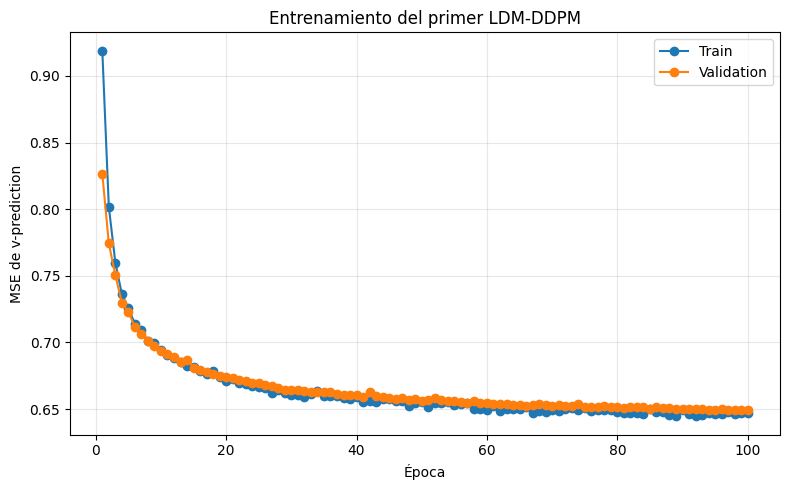

In [61]:
epochs = np.arange(1, len(ldm_history_first['train']) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, ldm_history_first['train'], marker='o', label='Train')
plt.plot(epochs, ldm_history_first['val'], marker='o', label='Validation')
plt.xlabel('Época')
plt.ylabel('MSE de v-prediction')
plt.title('Entrenamiento del primer LDM-DDPM')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
@torch.no_grad()
def latent_ddpm_reverse_step_v(model, scheduler, z_t, timestep, class_labels, noise=None):
    batch_size = z_t.shape[0]
    t_batch = torch.full((batch_size,), timestep, device=z_t.device, dtype=torch.long)
    v_prediction = model(z_t, t_batch, class_labels)
    sqrt_alpha_bar_t = scheduler.sqrt_alpha_cum_prod[timestep]
    sqrt_one_minus_alpha_bar_t = scheduler.sqrt_one_minus_alpha_cum_prod[timestep]
    z0_prediction = sqrt_alpha_bar_t * z_t - sqrt_one_minus_alpha_bar_t * v_prediction

    if timestep == 0:
        return (z0_prediction, z0_prediction)

    posterior_mean = scheduler.posterior_mean_coef1[timestep] * z0_prediction + scheduler.posterior_mean_coef2[timestep] * z_t
    posterior_variance = scheduler.posterior_variance[timestep].clamp_min(1e-20)

    if noise is None:
        noise = torch.randn_like(z_t)

    z_previous = posterior_mean + torch.sqrt(posterior_variance) * noise

    return (z_previous, z0_prediction)

In [63]:
from tqdm.auto import tqdm


@torch.no_grad()
def generate_standardized_latents_ddpm(model, scheduler, num_samples, class_labels, latent_shape=(4, 16, 16), device=device, seed=42):
    model.eval()

    if isinstance(class_labels, int):
        class_labels = torch.full((num_samples,), class_labels, dtype=torch.long, device=device)
    else:
        class_labels = torch.as_tensor(class_labels, dtype=torch.long).reshape(-1).to(device)

    if class_labels.shape[0] != num_samples:
        raise ValueError('class_labels debe tener una etiqueta por cada muestra.')

    if class_labels.min().item() < 0 or class_labels.max().item() >= NUM_CLASSES:
        raise ValueError(f'Las etiquetas deben estar entre 0 y {NUM_CLASSES - 1}.')

    if seed is not None:
        torch.manual_seed(seed)

    z_t = torch.randn((num_samples, *latent_shape), device=device)

    for timestep in tqdm(reversed(range(scheduler.num_timesteps)), total=scheduler.num_timesteps, desc='Generando latentes DDPM'):
        z_t, _ = latent_ddpm_reverse_step_v(model=model, scheduler=scheduler, z_t=z_t, timestep=timestep, class_labels=class_labels)

        if timestep % 100 == 0:
            if not torch.isfinite(z_t).all():
                raise RuntimeError(f'Aparecieron NaN o infinitos durante el timestep {timestep}.')

    if not torch.isfinite(z_t).all():
        raise RuntimeError('Los latentes finales contienen NaN o infinitos.')

    return z_t

In [64]:
NUM_GENERATED_SAMPLES = 16
generated_sample_labels = torch.tensor([0] * 8 + [1] * 8, dtype=torch.long)
generated_latents_standardized = generate_standardized_latents_ddpm(
    model=ldm_model_first, scheduler=ldm_scheduler, num_samples=NUM_GENERATED_SAMPLES,
    class_labels=generated_sample_labels, latent_shape=(4, 16, 16), device=device, seed=SEED,
)

print('Shape:', generated_latents_standardized.shape)
print('Labels:', generated_sample_labels.tolist())
print('Valores finitos:', torch.isfinite(generated_latents_standardized).all().item())

Generando latentes DDPM:   0%|          | 0/1000 [00:00<?, ?it/s]

Shape: torch.Size([16, 4, 16, 16])
Labels: [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]
Valores finitos: True


In [65]:
def print_generated_latent_statistics(latents):
    latents_cpu = latents.detach().float().cpu()
    print('Media por canal:', latents_cpu.mean(dim=(0, 2, 3)).numpy())
    print('Std por canal:', latents_cpu.std(dim=(0, 2, 3), unbiased=False).numpy())
    print('Media global:', latents_cpu.mean().item())
    print('Std global:', latents_cpu.std(unbiased=False).item())
    print('Mínimo:', latents_cpu.min().item())
    print('Máximo:', latents_cpu.max().item())
    print('Fracción |z| > 4:', (latents_cpu.abs() > 4.0).float().mean().item())
    print('Fracción |z| > 6:', (latents_cpu.abs() > 6.0).float().mean().item())

In [66]:
print_generated_latent_statistics(generated_latents_standardized)

Media por canal: [ 0.03197598  0.00046016 -0.11688583  0.04210524]
Std por canal: [1.0316076 0.9882045 1.0120082 1.0613668]
Media global: -0.01058611273765564
Std global: 1.0256012678146362
Mínimo: -13.391899108886719
Máximo: 16.62889289855957
Fracción |z| > 4: 0.01031494140625
Fracción |z| > 6: 0.00482177734375


In [67]:
latent_mean_device = latent_mean_train.to(device).float()
latent_std_device = latent_std_train.to(device).float()
generated_latents_original = generated_latents_standardized * latent_std_device + latent_mean_device

print('Latentes desestandarizados:', generated_latents_original.shape)
print('Valores finitos:', torch.isfinite(generated_latents_original).all().item())

Latentes desestandarizados: torch.Size([16, 4, 16, 16])
Valores finitos: True


In [68]:
@torch.no_grad()
def decode_generated_latents(vae_model, latent_tensor):
    vae_model.eval()
    generated_images_m11 = vae_model.decode_hard(latent_tensor)
    generated_images_01 = ((generated_images_m11 + 1.0) / 2.0).clamp(0.0, 1.0)

    return generated_images_01

In [69]:
generated_jets_01 = decode_generated_latents(vae_model=vae_model, latent_tensor=generated_latents_original)
print('Jets generados:', generated_jets_01.shape)
print('Mínimo:', generated_jets_01.min().item())
print('Máximo:', generated_jets_01.max().item())
print('Valores finitos:', torch.isfinite(generated_jets_01).all().item())

Jets generados: torch.Size([16, 3, 64, 64])
Mínimo: 0.0
Máximo: 1.0
Valores finitos: True


In [70]:
def plot_generated_jets(generated_images_01, labels=None, num_images=8, contrast=True, class_names=None):
    images = generated_images_01.detach().float().cpu()
    num_images = min(num_images, images.shape[0])

    if labels is not None:
        labels = torch.as_tensor(labels).detach().cpu().reshape(-1)

        if labels.shape[0] < num_images:
            raise ValueError('No hay suficientes labels para las imágenes mostradas.')

    if class_names is None:
        class_names = {0: 'Clase 0', 1: 'Clase 1'}

    num_columns = 4
    num_rows = int(np.ceil(num_images / num_columns))
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(3.6 * num_columns, 4.4 * num_rows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for index in range(num_images):
        image = images[index]
        total_intensity = image.sum().item()
        maximum = image.max().item()
        active_fraction = (image > 0.0001).float().mean().item()
        image_to_show = image.permute(1, 2, 0).numpy()

        if contrast:
            display_maximum = image_to_show.max()

            if display_maximum > 0:
                image_to_show = image_to_show / display_maximum

        axes[index].imshow(image_to_show)

        if labels is not None:
            class_id = int(labels[index].item())
            class_label = class_names.get(class_id, f'Clase {class_id}')
            title = f'Jet {index + 1} — {class_label}\nI={total_intensity:.2f}, max={maximum:.3f}\nact={100 * active_fraction:.2f}%'
        else:
            title = f'Jet {index + 1}\nI={total_intensity:.2f}, max={maximum:.3f}\nact={100 * active_fraction:.2f}%'

        axes[index].set_title(title, fontsize=14, pad=6)
        axes[index].axis('off')

    for index in range(num_images, len(axes)):
        axes[index].axis('off')

plt.show()

In [71]:
@torch.no_grad()
def generate_jet_dataset_ddpm(
    ldm_model, scheduler, vae_model, latent_mean, latent_std, num_samples, class_labels, batch_size=64,
    latent_shape=(4, 16, 16), device=device, seed=42,
):
    ldm_model.eval()
    vae_model.eval()
    class_labels = torch.as_tensor(class_labels, dtype=torch.long).reshape(-1)

    if class_labels.shape[0] != num_samples:
        raise ValueError(f'class_labels debe contener exactamente {num_samples} etiquetas.')

    if class_labels.min().item() < 0 or class_labels.max().item() >= NUM_CLASSES:
        raise ValueError(f'Las etiquetas deben estar entre 0 y {NUM_CLASSES - 1}.')

    if seed is not None:
        torch.manual_seed(seed)

    latent_mean = latent_mean.to(device).float()
    latent_std = latent_std.to(device).float()
    generated_batches = []
    generated_latent_batches = []
    num_batches = int(np.ceil(num_samples / batch_size))

    for batch_index in tqdm(range(num_batches), desc='Generando dataset con LDM'):
        current_batch_size = min(batch_size, num_samples - batch_index * batch_size)
        start_index = batch_index * batch_size
        end_index = start_index + current_batch_size
        batch_labels = class_labels[start_index:end_index].to(device)
        z_t = torch.randn((current_batch_size, *latent_shape), device=device)

        for timestep in reversed(range(scheduler.num_timesteps)):
            z_t, _ = latent_ddpm_reverse_step_v(model=ldm_model, scheduler=scheduler, z_t=z_t, timestep=timestep, class_labels=batch_labels)

        generated_latent_batches.append(z_t.detach().cpu())
        z_original = z_t * latent_std + latent_mean
        generated_m11 = vae_model.decode_hard(z_original)
        generated_01 = ((generated_m11 + 1.0) / 2.0).clamp(0.0, 1.0)

        generated_batches.append(generated_01.detach().cpu())

    generated_images_01 = torch.cat(generated_batches, dim=0)
    generated_latents_standardized = torch.cat(generated_latent_batches, dim=0)

    return (generated_images_01, generated_latents_standardized, class_labels.cpu())

In [72]:
NUM_GENERATED_JETS = 2500
generation_labels_2500 = ldm_test_labels[:NUM_GENERATED_JETS].clone()
print('Distribución de clases a generar:', torch.unique(generation_labels_2500, return_counts=True))
generated_images_01, generated_latents_2500, generated_labels_2500 = generate_jet_dataset_ddpm(
    ldm_model=ldm_model_first, scheduler=ldm_scheduler, vae_model=vae_model, latent_mean=latent_mean_train,
    latent_std=latent_std_train, num_samples=NUM_GENERATED_JETS, class_labels=generation_labels_2500,
    batch_size=64, latent_shape=(4, 16, 16), device=device, seed=SEED,
)
print('Shape:', generated_images_01.shape)
print('Min:', generated_images_01.min().item())
print('Max:', generated_images_01.max().item())
print('Finitos:', torch.isfinite(generated_images_01).all().item())
print('Shape latentes generados:', generated_latents_2500.shape)
print('Latentes finitos:', torch.isfinite(generated_latents_2500).all().item())

Distribución de clases a generar: (tensor([0, 1]), tensor([1240, 1260]))


Generando dataset con LDM:   0%|          | 0/40 [00:00<?, ?it/s]

Shape: torch.Size([2500, 3, 64, 64])
Min: 0.0
Max: 1.0
Finitos: True
Shape latentes generados: torch.Size([2500, 4, 16, 16])
Latentes finitos: True


In [73]:
print_generated_latent_statistics(generated_latents_2500)

Media por canal: [ 0.02264865 -0.00067716 -0.13233274  0.0256205 ]
Std por canal: [1.0276904 1.0687943 1.0434191 1.0305109]
Media global: -0.02118515968322754
Std global: 1.044752597808838
Mínimo: -18.967199325561523
Máximo: 21.487506866455078
Fracción |z| > 4: 0.010031250305473804
Fracción |z| > 6: 0.004290234297513962


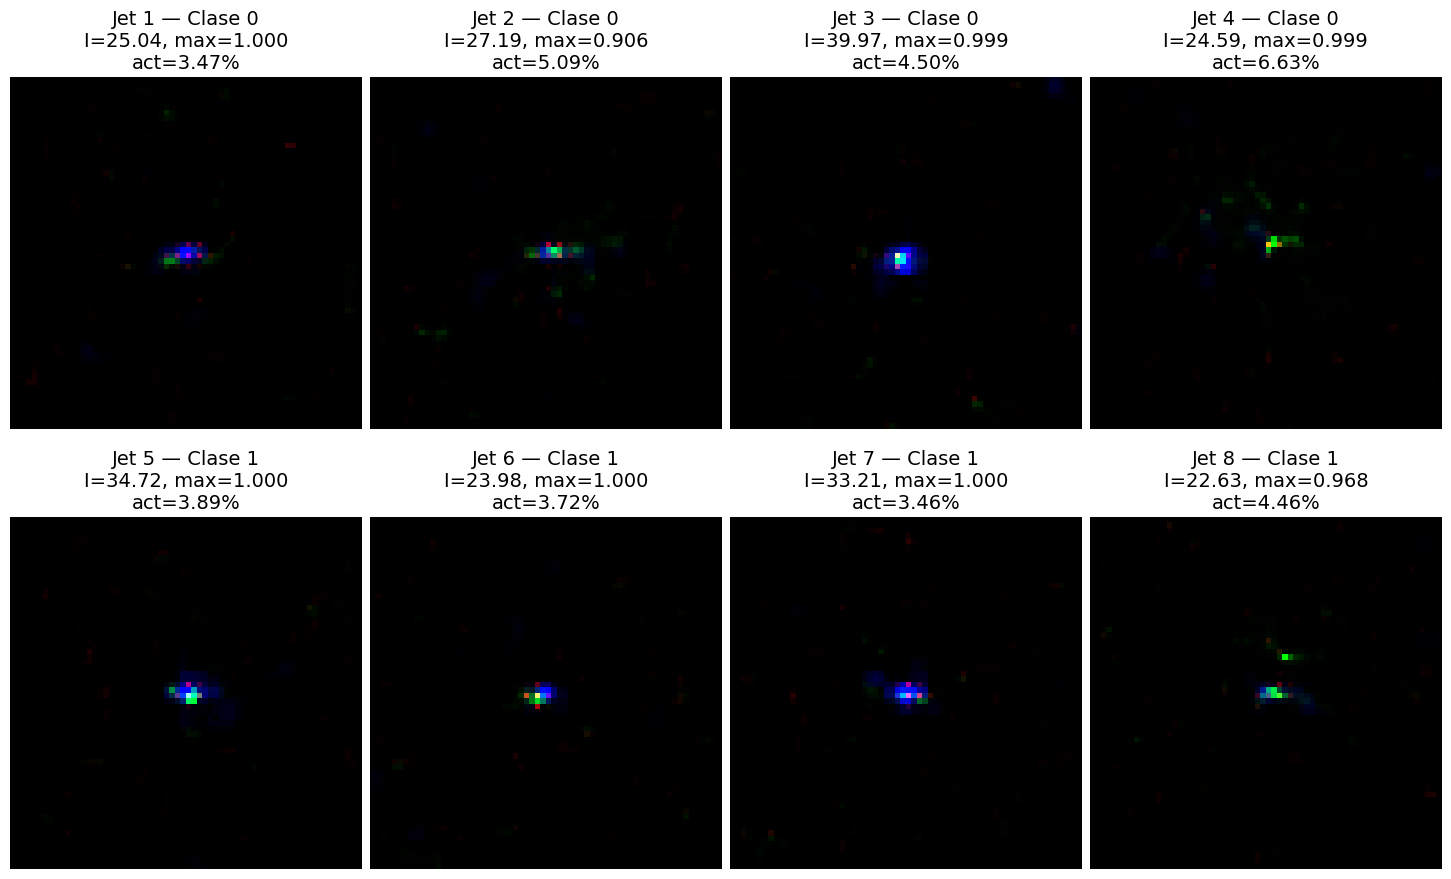

In [74]:
indices_class_0 = torch.where(generated_labels_2500 == 0)[0][:4]
indices_class_1 = torch.where(generated_labels_2500 == 1)[0][:4]
sample_indices = torch.cat([indices_class_0, indices_class_1])

plot_generated_jets(generated_images_01[sample_indices], labels=generated_labels_2500[sample_indices], num_images=8, contrast=True)

In [75]:
@torch.no_grad()
def collect_real_images_from_loader(data_loader, device=device):
    image_batches = []

    for images, _ in data_loader:
        images = images.to(device)
        images_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
        image_batches.append(images_01.detach().cpu())

    return torch.cat(image_batches, dim=0)

In [76]:
real_test_images_01 = collect_real_images_from_loader(test_loader, device=device)
print('Shape real:', real_test_images_01.shape)
print('Min real:', real_test_images_01.min().item())
print('Max real:', real_test_images_01.max().item())

Shape real: torch.Size([2500, 3, 64, 64])
Min real: 0.0
Max real: 1.0


In [77]:
from scipy.stats import wasserstein_distance
CHANNEL_NAMES = ['TRACKER', 'ECAL', 'HCAL']


@torch.no_grad()
def collect_image_diagnostics(images_01, active_thr_01=0.0001, num_radial_bins=32):
    images_01 = images_01.float().cpu()
    batch_size, channels, height, width = images_01.shape
    energy = images_01.sum(dim=(-2, -1)).numpy()
    active_fraction = (images_01 > active_thr_01).float().mean(dim=(-2, -1)).numpy()
    maximum = images_01.amax(dim=(-2, -1)).numpy()
    y_coordinates, x_coordinates = torch.meshgrid(torch.arange(height, dtype=torch.float32), torch.arange(width, dtype=torch.float32), indexing='ij')
    center_y = (height - 1) / 2.0
    center_x = (width - 1) / 2.0
    radius = torch.sqrt((y_coordinates - center_y) ** 2 + (x_coordinates - center_x) ** 2)
    radial_edges = torch.linspace(0.0, radius.max().item() + 1e-06, num_radial_bins + 1)
    radial_centers = (0.5 * (radial_edges[:-1] + radial_edges[1:])).numpy()
    radial_bin_index = (torch.bucketize(radius.reshape(-1), radial_edges, right=False) - 1).clamp(min=0, max=num_radial_bins - 1)
    radial_sum = torch.zeros(channels, num_radial_bins, dtype=torch.float64)
    flat_images = images_01.reshape(batch_size, channels, -1).double()

    for radial_bin in range(num_radial_bins):
        radial_mask = radial_bin_index == radial_bin
        radial_sum[:, radial_bin] += flat_images[:, :, radial_mask].sum(dim=(0, 2))

    radial_profile = (radial_sum / radial_sum.sum(dim=1, keepdim=True).clamp_min(1e-12)).numpy()

    return {
        'images': images_01,
        'energy': energy,
        'active_fraction': active_fraction,
        'maximum': maximum,
        'radial_centers': radial_centers,
        'radial_profile': radial_profile,
    }

In [78]:
real_diag = collect_image_diagnostics(real_test_images_01, active_thr_01=0.0001, num_radial_bins=32)
gen_diag = collect_image_diagnostics(generated_images_01, active_thr_01=0.0001, num_radial_bins=32)

In [79]:
def summarize_real_vs_generated(real_diag, gen_diag):
    rows = []

    for channel, channel_name in enumerate(CHANNEL_NAMES):
        e_real = real_diag['energy'][:, channel]
        e_gen = gen_diag['energy'][:, channel]
        a_real = real_diag['active_fraction'][:, channel]
        a_gen = gen_diag['active_fraction'][:, channel]
        m_real = real_diag['maximum'][:, channel]
        m_gen = gen_diag['maximum'][:, channel]
        radial_real = real_diag['radial_profile'][channel]
        radial_gen = gen_diag['radial_profile'][channel]
        row = {
            'Canal': channel_name,
            'E real media': e_real.mean(),
            'E gen media': e_gen.mean(),
            'Bias E (%)': 100.0 * (e_gen.mean() - e_real.mean()) / max(e_real.mean(), 1e-12),
            'W1 energía': wasserstein_distance(e_real, e_gen),
            'Fracción activa real': a_real.mean(),
            'Fracción activa gen': a_gen.mean(),
            'Diferencia activa (p.p.)': 100.0 * (a_gen.mean() - a_real.mean()),
            'Máximo real medio': m_real.mean(),
            'Máximo gen medio': m_gen.mean(),
            'W1 máximo': wasserstein_distance(m_real, m_gen),
            'Radial L1': np.mean(np.abs(radial_gen - radial_real)),
            'Radial L2': np.sqrt(np.mean((radial_gen - radial_real) ** 2)),
        }

        rows.append(row)

    return pd.DataFrame(rows)

In [80]:
summary_ldm = summarize_real_vs_generated(real_diag, gen_diag)
display(summary_ldm.round(6))

,Canal,E real media,E gen media,Bias E (%),W1 energía,Fracción activa real,Fracción activa gen,Diferencia activa (p.p.),Máximo real medio,Máximo gen medio,W1 máximo,Radial L1,Radial L2
0,TRACKER,5.859265,6.418932,9.551832,0.594271,0.041333,0.043583,0.225068,0.760318,0.767902,0.029088,0.003559,0.005855
1,ECAL,7.773422,7.932530,2.046829,0.316151,0.053148,0.051317,-0.183047,0.826301,0.738226,0.088194,0.001634,0.003263
2,HCAL,11.419732,13.996000,22.559797,2.576269,0.044677,0.051227,0.654990,0.523041,0.622550,0.099510,0.002794,0.006579


In [81]:
def print_global_generation_summary(real_diag, gen_diag):
    total_real = real_diag['energy'].sum(axis=1)
    total_gen = gen_diag['energy'].sum(axis=1)
    active_real = real_diag['active_fraction'].mean(axis=1)
    active_gen = gen_diag['active_fraction'].mean(axis=1)
    max_real = real_diag['maximum'].max(axis=1)
    max_gen = gen_diag['maximum'].max(axis=1)

    print('============================================================')
    print('RESUMEN GLOBAL: REAL vs GENERADO')
    print('============================================================')
    print(f'Intensidad total media real      : {total_real.mean():.6f}')
    print(f'Intensidad total media generada  : {total_gen.mean():.6f}')
    print(f'Bias total (%)                   : {100 * (total_gen.mean() - total_real.mean()) / max(total_real.mean(), 1e-12):.6f}')
    print(f'W1 intensidad total              : {wasserstein_distance(total_real, total_gen):.6f}')
    print()
    print(f'Fracción activa media real       : {active_real.mean():.6f}')
    print(f'Fracción activa media generada   : {active_gen.mean():.6f}')
    print(f'Diferencia activa (p.p.)         : {100 * (active_gen.mean() - active_real.mean()):.6f}')
    print()
    print(f'Máximo global medio real         : {max_real.mean():.6f}')
    print(f'Máximo global medio generado     : {max_gen.mean():.6f}')
    print(f'W1 máximo global                 : {wasserstein_distance(max_real, max_gen):.6f}')

In [82]:
print_global_generation_summary(real_diag, gen_diag)

RESUMEN GLOBAL: REAL vs GENERADO
Intensidad total media real      : 25.052420
Intensidad total media generada  : 28.347462
Bias total (%)                   : 13.152591
W1 intensidad total              : 3.369105

Fracción activa media real       : 0.046386
Fracción activa media generada   : 0.048709
Diferencia activa (p.p.)         : 0.232337

Máximo global medio real         : 0.935446
Máximo global medio generado     : 0.903440
W1 máximo global                 : 0.032005


In [83]:
def summarize_generation_by_class(real_images, real_labels, generated_images, generated_labels):
    real_labels = torch.as_tensor(real_labels).long().cpu().reshape(-1)
    generated_labels = torch.as_tensor(generated_labels).long().cpu().reshape(-1)
    tables = []
    class_ids = sorted(set(real_labels.tolist()) & set(generated_labels.tolist()))

    for class_id in class_ids:
        real_mask = real_labels == class_id
        generated_mask = generated_labels == class_id
        real_class_images = real_images[real_mask]
        generated_class_images = generated_images[generated_mask]

        print(f'Clase {class_id}: {real_mask.sum().item()} reales | {generated_mask.sum().item()} generados')
        real_class_diag = collect_image_diagnostics(real_class_images, active_thr_01=0.0001, num_radial_bins=32)
        generated_class_diag = collect_image_diagnostics(generated_class_images, active_thr_01=0.0001, num_radial_bins=32)
        class_summary = summarize_real_vs_generated(real_class_diag, generated_class_diag)

        class_summary.insert(0, 'Clase', class_id)
        class_summary.insert(1, 'N real', real_mask.sum().item())
        class_summary.insert(2, 'N generado', generated_mask.sum().item())
        tables.append(class_summary)

    return pd.concat(tables, ignore_index=True)

In [84]:
summary_by_class = summarize_generation_by_class(
    real_images=real_test_images_01, real_labels=ldm_test_labels, generated_images=generated_images_01,
    generated_labels=generated_labels_2500,
)
display(summary_by_class.round(6))

Clase 0: 1240 reales | 1240 generados
Clase 1: 1260 reales | 1260 generados


,Clase,N real,N generado,Canal,E real media,E gen media,Bias E (%),W1 energía,Fracción activa real,Fracción activa gen,Diferencia activa (p.p.),Máximo real medio,Máximo gen medio,W1 máximo,Radial L1,Radial L2
0,0,1240,1240,TRACKER,6.137948,6.485046,5.654958,0.349241,0.043359,0.044411,0.105177,0.709312,0.710040,0.020436,0.003762,0.006194
1,0,1240,1240,ECAL,7.922428,8.259978,4.260685,0.339723,0.057421,0.056420,-0.100117,0.782607,0.700378,0.082301,0.001756,0.003693
2,0,1240,1240,HCAL,11.089706,12.894815,16.277338,1.810108,0.047002,0.053844,0.684224,0.484205,0.547923,0.063902,0.002691,0.005699
3,1,1260,1260,TRACKER,5.585006,6.353868,13.766534,0.835472,0.039338,0.042769,0.343056,0.810513,0.824847,0.037640,0.003417,0.005370
4,1,1260,1260,ECAL,7.626781,7.610281,-0.216343,0.367646,0.048942,0.046296,-0.264660,0.869302,0.775472,0.093999,0.002064,0.003399
5,1,1260,1260,HCAL,11.744519,15.079708,28.397833,3.335189,0.042389,0.048651,0.626221,0.561260,0.695992,0.134732,0.002672,0.006874


In [85]:
def build_class_comparison_diagnostics(real_diag, generated_diag, real_labels, generated_labels, class_id):
    real_labels_np = torch.as_tensor(real_labels).long().cpu().numpy().reshape(-1)
    generated_labels_np = torch.as_tensor(generated_labels).long().cpu().numpy().reshape(-1)
    real_mask = real_labels_np == class_id
    generated_mask = generated_labels_np == class_id

    if real_mask.sum() == 0:
        raise ValueError(f'No hay eventos reales de clase {class_id}.')

    if generated_mask.sum() == 0:
        raise ValueError(f'No hay eventos generados de clase {class_id}.')

    class_diagnostics = {
        'energy_real': np.asarray(real_diag['energy'])[real_mask],
        'energy_recon': np.asarray(generated_diag['energy'])[generated_mask],
        'active_frac_real': np.asarray(real_diag['active_fraction'])[real_mask],
        'active_frac_recon': np.asarray(generated_diag['active_fraction'])[generated_mask],
        'max_real': np.asarray(real_diag['maximum'])[real_mask],
        'max_recon': np.asarray(generated_diag['maximum'])[generated_mask],
    }
    print(f'Clase {class_id}: {real_mask.sum()} reales | {generated_mask.sum()} generados')

    return class_diagnostics

In [86]:
comparison_diagnostics_class_0 = build_class_comparison_diagnostics(
    real_diag=real_diag, generated_diag=gen_diag, real_labels=ldm_test_labels,
    generated_labels=generated_labels_2500, class_id=0,
)
comparison_diagnostics_class_1 = build_class_comparison_diagnostics(
    real_diag=real_diag, generated_diag=gen_diag, real_labels=ldm_test_labels,
    generated_labels=generated_labels_2500, class_id=1,
)

Clase 0: 1240 reales | 1240 generados
Clase 1: 1260 reales | 1260 generados


In [87]:
comparison_diagnostics = {
    'energy_real': real_diag['energy'],
    'energy_recon': gen_diag['energy'],
    'active_frac_real': real_diag['active_fraction'],
    'active_frac_recon': gen_diag['active_fraction'],
    'max_real': real_diag['maximum'],
    'max_recon': gen_diag['maximum'],
    'radial_centers': real_diag['radial_centers'],
    'radial_real': real_diag['radial_profile'],
    'radial_recon': gen_diag['radial_profile'],
}

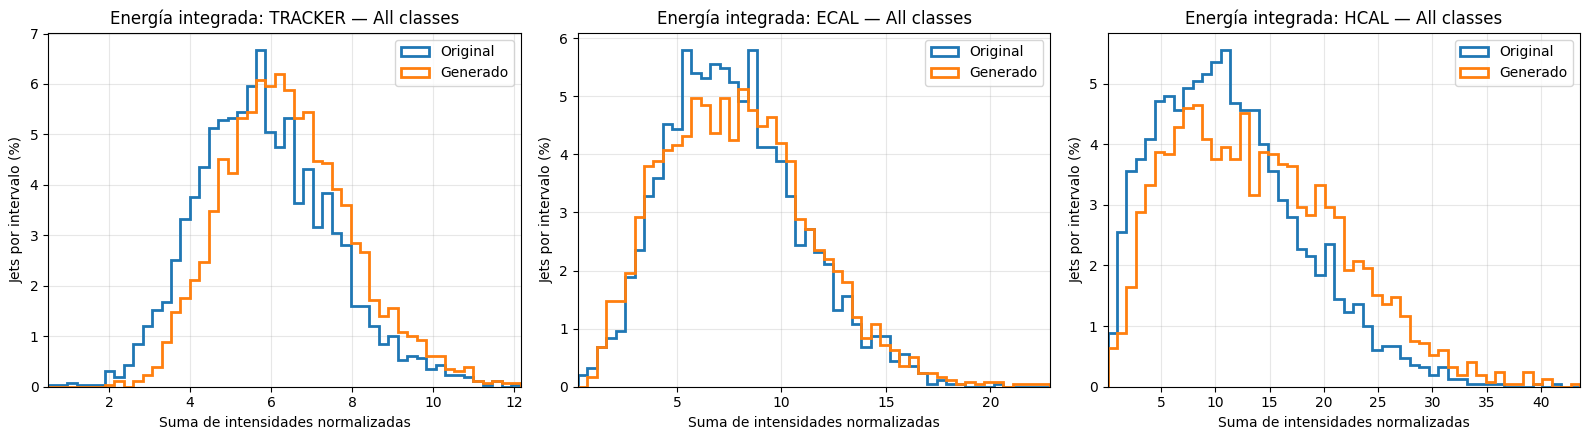

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Energía integrada: TRACKER — All classes'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Energía integrada: ECAL — All classes'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Energía integrada: HCAL — All classes'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [88]:
plot_channel_distributions(comparison_diagnostics, metric='energy', num_bins=50, upper_quantile=0.999, class_name='All classes')

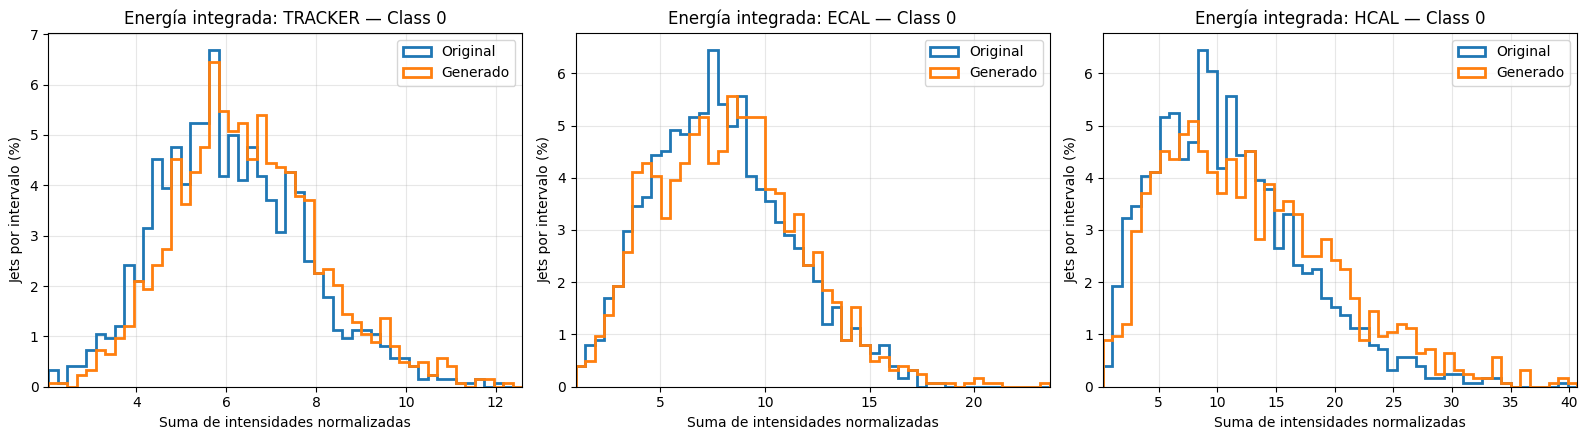

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Energía integrada: TRACKER — Class 0'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Energía integrada: ECAL — Class 0'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Energía integrada: HCAL — Class 0'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [89]:
plot_channel_distributions(comparison_diagnostics_class_0, metric='energy', num_bins=50, upper_quantile=0.999, class_name='Class 0')

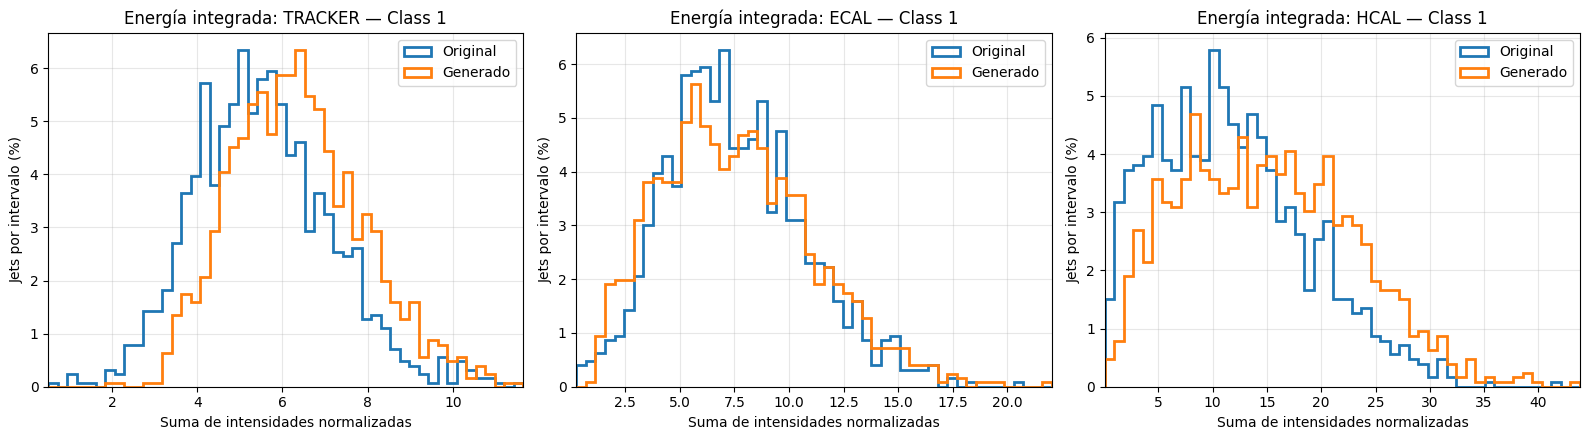

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Energía integrada: TRACKER — Class 1'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Energía integrada: ECAL — Class 1'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Energía integrada: HCAL — Class 1'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [90]:
plot_channel_distributions(comparison_diagnostics_class_1, metric='energy', num_bins=50, upper_quantile=0.999, class_name='Class 1')

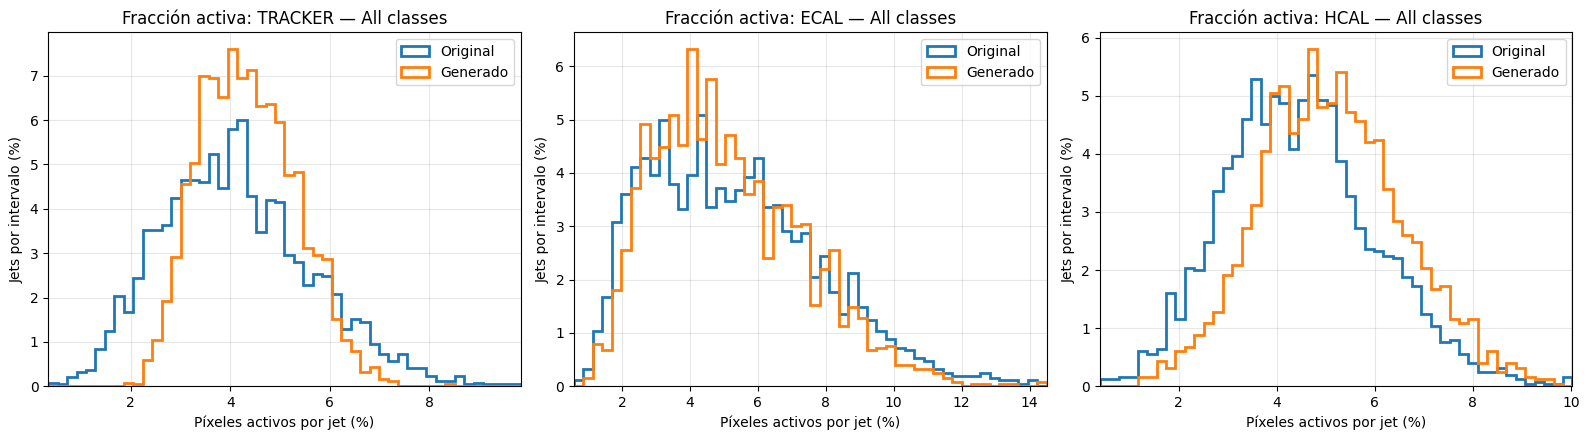

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Fracción activa: TRACKER — All classes'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: ECAL — All classes'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: HCAL — All classes'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [91]:
plot_channel_distributions(comparison_diagnostics, metric='active_fraction', num_bins=50, upper_quantile=0.999, class_name='All classes')

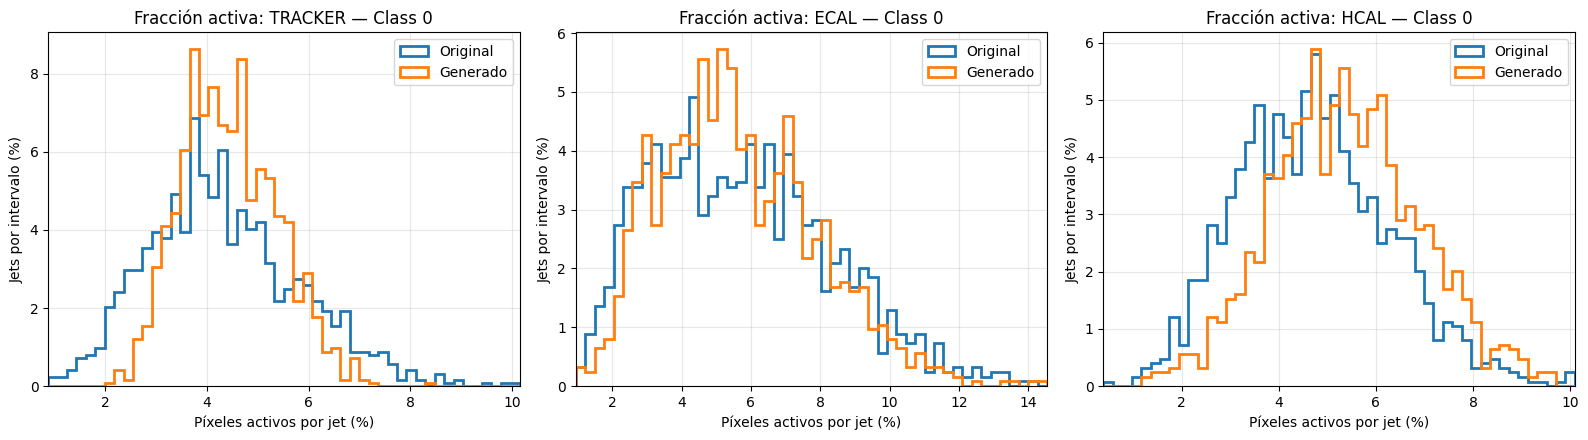

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Fracción activa: TRACKER — Class 0'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: ECAL — Class 0'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: HCAL — Class 0'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [92]:
plot_channel_distributions(comparison_diagnostics_class_0, metric='active_fraction', num_bins=50, upper_quantile=0.999, class_name='Class 0')

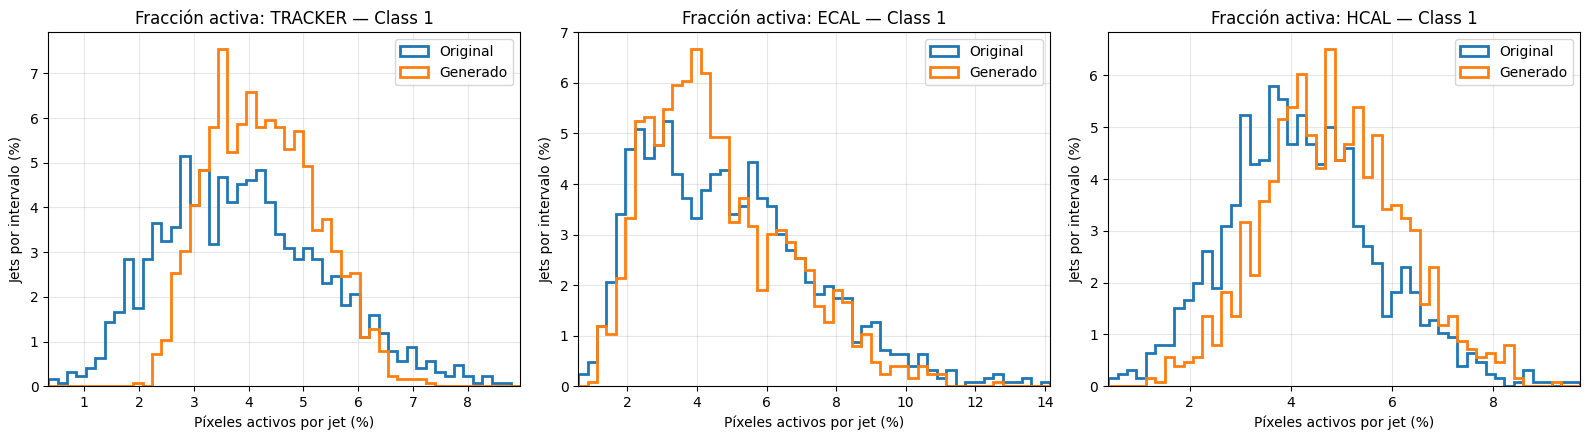

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Fracción activa: TRACKER — Class 1'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: ECAL — Class 1'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: HCAL — Class 1'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [93]:
plot_channel_distributions(comparison_diagnostics_class_1, metric='active_fraction', num_bins=50, upper_quantile=0.999, class_name='Class 1')

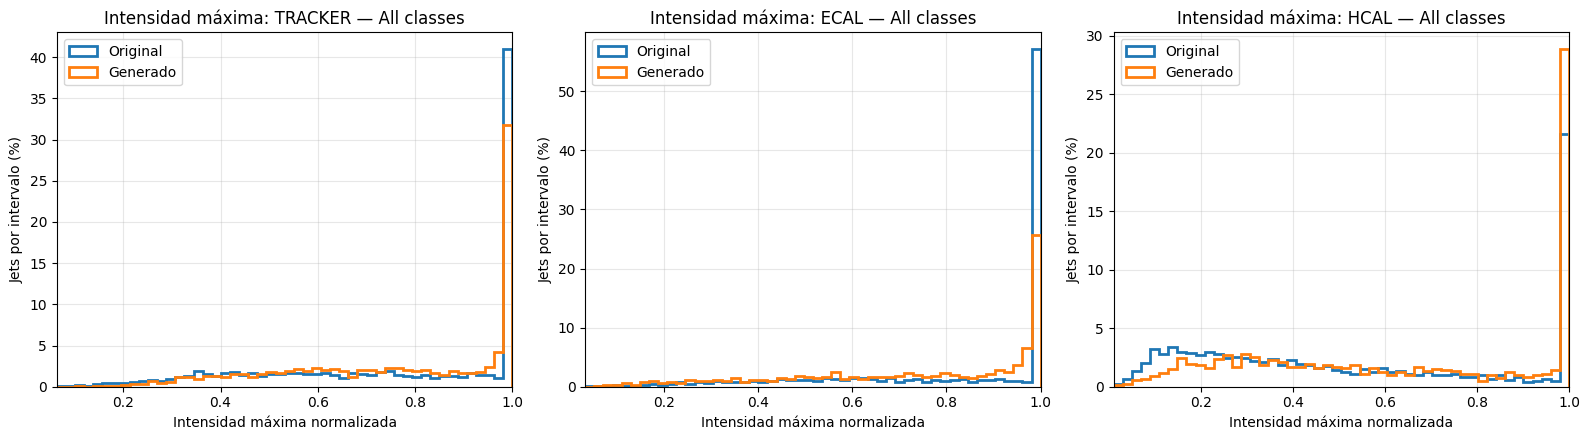

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Intensidad máxima: TRACKER — All classes'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: ECAL — All classes'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: HCAL — All classes'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [94]:
plot_channel_distributions(comparison_diagnostics, metric='maximum', num_bins=50, upper_quantile=0.999, class_name='All classes')

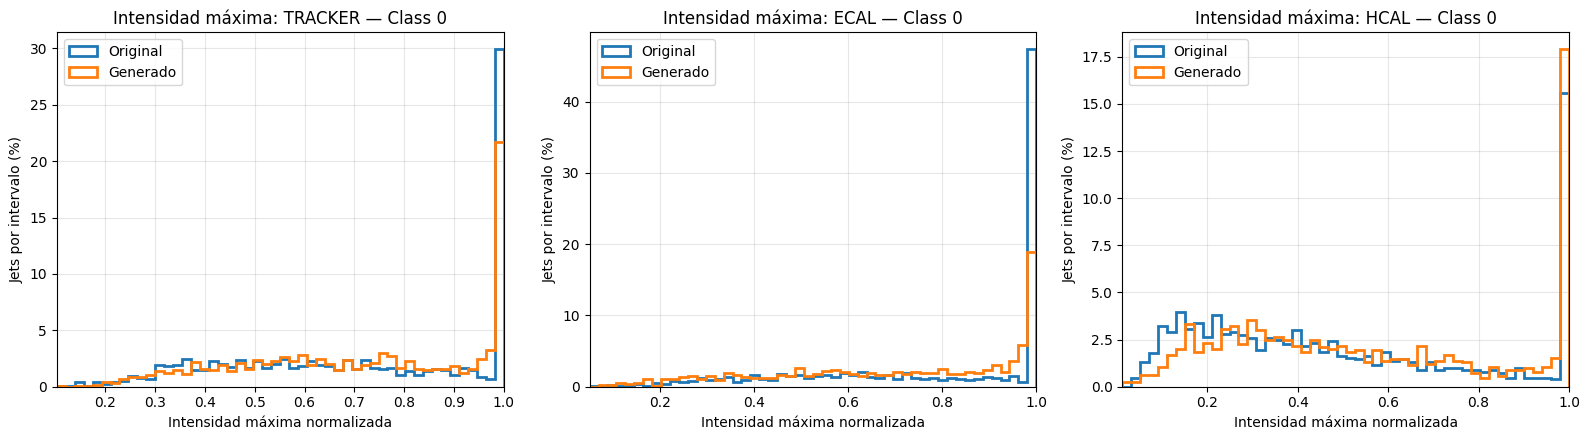

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Intensidad máxima: TRACKER — Class 0'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: ECAL — Class 0'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: HCAL — Class 0'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [95]:
plot_channel_distributions(comparison_diagnostics_class_0, metric='maximum', num_bins=50, upper_quantile=0.999, class_name='Class 0')

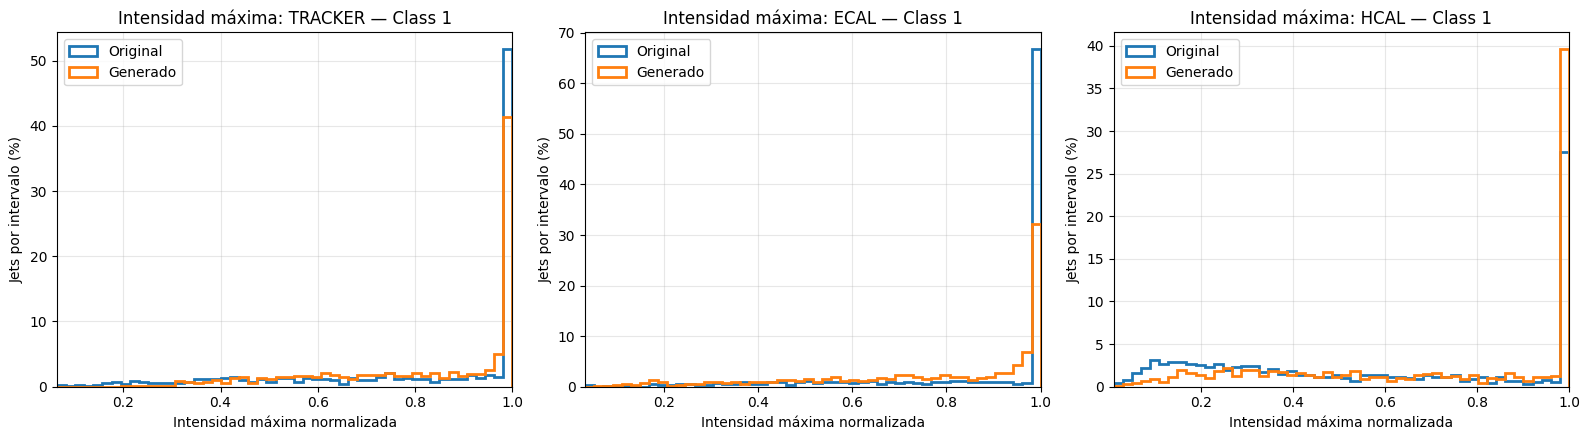

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Intensidad máxima: TRACKER — Class 1'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: ECAL — Class 1'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: HCAL — Class 1'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [96]:
plot_channel_distributions(comparison_diagnostics_class_1, metric='maximum', num_bins=50, upper_quantile=0.999, class_name='Class 1')

In [97]:
def plot_radial_profiles_from_diagnostics(comparison_diagnostics):
    radial_centers = comparison_diagnostics['radial_centers']
    radial_real = comparison_diagnostics['radial_real']
    radial_gen = comparison_diagnostics['radial_recon']
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    for channel, channel_name in enumerate(CHANNEL_NAMES):
        axes[channel].plot(radial_centers, radial_real[channel], marker='o', label='Real')
        axes[channel].plot(radial_centers, radial_gen[channel], marker='o', label='Generado')
        axes[channel].set_title(f'Perfil radial: {channel_name}')
        axes[channel].set_xlabel('Radio')
        axes[channel].set_ylabel('Fracción de intensidad')
        axes[channel].grid(alpha=0.3)
        axes[channel].legend()

    plt.tight_layout()
    plt.show()

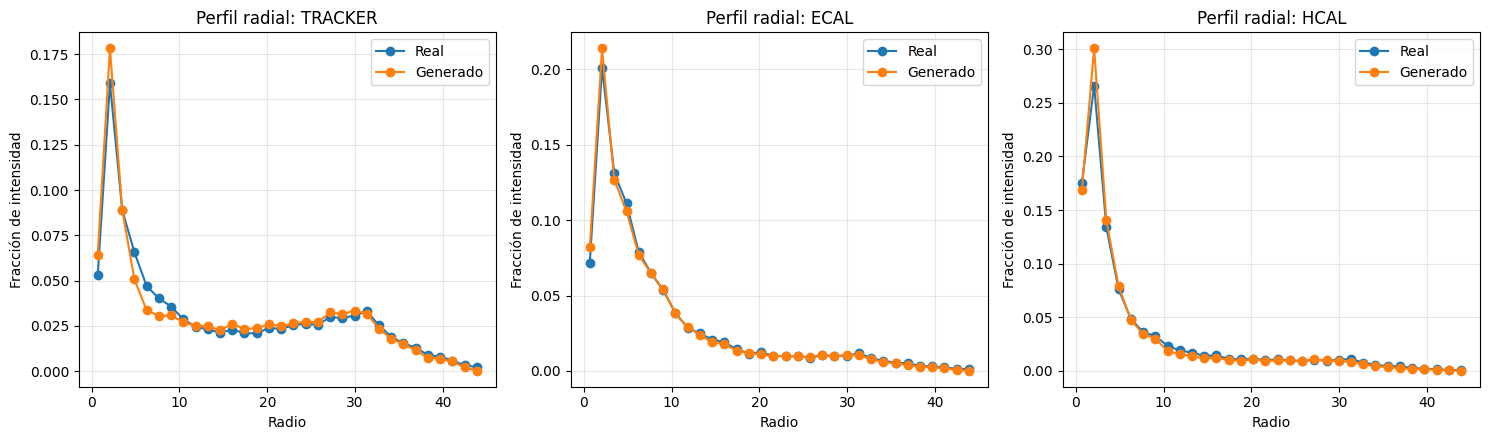

In [98]:
plot_radial_profiles_from_diagnostics(comparison_diagnostics)

In [99]:
def plot_real_vs_generated_class_separation(
    real_diag, generated_diag, real_labels, generated_labels, metric, num_bins=50, upper_quantile=0.999,
    class_0_name='Class 0', class_1_name='Class 1',
):
    real_labels_np = torch.as_tensor(real_labels).long().cpu().numpy().reshape(-1)
    generated_labels_np = torch.as_tensor(generated_labels).long().cpu().numpy().reshape(-1)

    if metric == 'energy':
        real_data = np.asarray(real_diag['energy'])
        generated_data = np.asarray(generated_diag['energy'])
        title_prefix = 'Integrated energy'
        x_label = 'Sum of normalized intensities'
    elif metric == 'active_fraction':
        real_data = np.asarray(real_diag['active_fraction']) * 100.0
        generated_data = np.asarray(generated_diag['active_fraction']) * 100.0
        title_prefix = 'Active fraction'
        x_label = 'Active pixels per jet (%)'
    elif metric == 'maximum':
        real_data = np.asarray(real_diag['maximum'])
        generated_data = np.asarray(generated_diag['maximum'])
        title_prefix = 'Maximum intensity'
        x_label = 'Normalized maximum intensity'
    else:
        raise ValueError("metric debe ser 'energy', 'active_fraction' o 'maximum'.")

    if real_data.ndim != 2:
        raise ValueError('real_data debe tener shape [N, C].')

    if generated_data.ndim != 2:
        raise ValueError('generated_data debe tener shape [N, C].')

    real_mask_0 = real_labels_np == 0
    real_mask_1 = real_labels_np == 1
    generated_mask_0 = generated_labels_np == 0
    generated_mask_1 = generated_labels_np == 1

    if real_mask_0.sum() == 0 or real_mask_1.sum() == 0:
        raise ValueError('El conjunto real no contiene ambas clases.')

    if generated_mask_0.sum() == 0 or generated_mask_1.sum() == 0:
        raise ValueError('El conjunto generado no contiene ambas clases.')

    print(f'REAL -> {class_0_name}: {real_mask_0.sum()} | {class_1_name}: {real_mask_1.sum()}')
    print(f'GENERATED -> {class_0_name}: {generated_mask_0.sum()} | {class_1_name}: {generated_mask_1.sum()}')
    fig, axes = plt.subplots(2, len(CHANNEL_NAMES), figsize=(16, 9), sharey='row')

    for channel, channel_name in enumerate(CHANNEL_NAMES):
        real_values_0 = real_data[real_mask_0, channel]
        real_values_1 = real_data[real_mask_1, channel]
        bins_real = common_histogram_bins(real_values_0, real_values_1, num_bins=num_bins, upper_quantile=upper_quantile)
        real_weights_0 = np.full(real_values_0.shape, 100.0 / len(real_values_0))
        real_weights_1 = np.full(real_values_1.shape, 100.0 / len(real_values_1))

        axes[0, channel].hist(real_values_0, bins=bins_real, weights=real_weights_0, histtype='step', linewidth=2, label=class_0_name)
        axes[0, channel].hist(real_values_1, bins=bins_real, weights=real_weights_1, histtype='step', linewidth=2, label=class_1_name)
        axes[0, channel].set_title(f'REAL — {title_prefix}: {channel_name}')
        axes[0, channel].set_xlabel(x_label)
        axes[0, channel].set_ylabel('Jets (%)')
        axes[0, channel].legend()
        axes[0, channel].grid(alpha=0.3)

        generated_values_0 = generated_data[generated_mask_0, channel]
        generated_values_1 = generated_data[generated_mask_1, channel]
        bins_generated = common_histogram_bins(generated_values_0, generated_values_1, num_bins=num_bins, upper_quantile=upper_quantile)
        generated_weights_0 = np.full(generated_values_0.shape, 100.0 / len(generated_values_0))
        generated_weights_1 = np.full(generated_values_1.shape, 100.0 / len(generated_values_1))

        axes[1, channel].hist(generated_values_0, bins=bins_generated, weights=generated_weights_0, histtype='step', linewidth=2, label=class_0_name)
        axes[1, channel].hist(generated_values_1, bins=bins_generated, weights=generated_weights_1, histtype='step', linewidth=2, label=class_1_name)
        axes[1, channel].set_title(f'GENERATED — {title_prefix}: {channel_name}')
        axes[1, channel].set_xlabel(x_label)
        axes[1, channel].set_ylabel('Jets (%)')
        axes[1, channel].legend()
        axes[1, channel].grid(alpha=0.3)

    fig.tight_layout()
    plt.show()

    return (fig, axes)

REAL -> Class 0: 1240 | Class 1: 1260
GENERATED -> Class 0: 1240 | Class 1: 1260


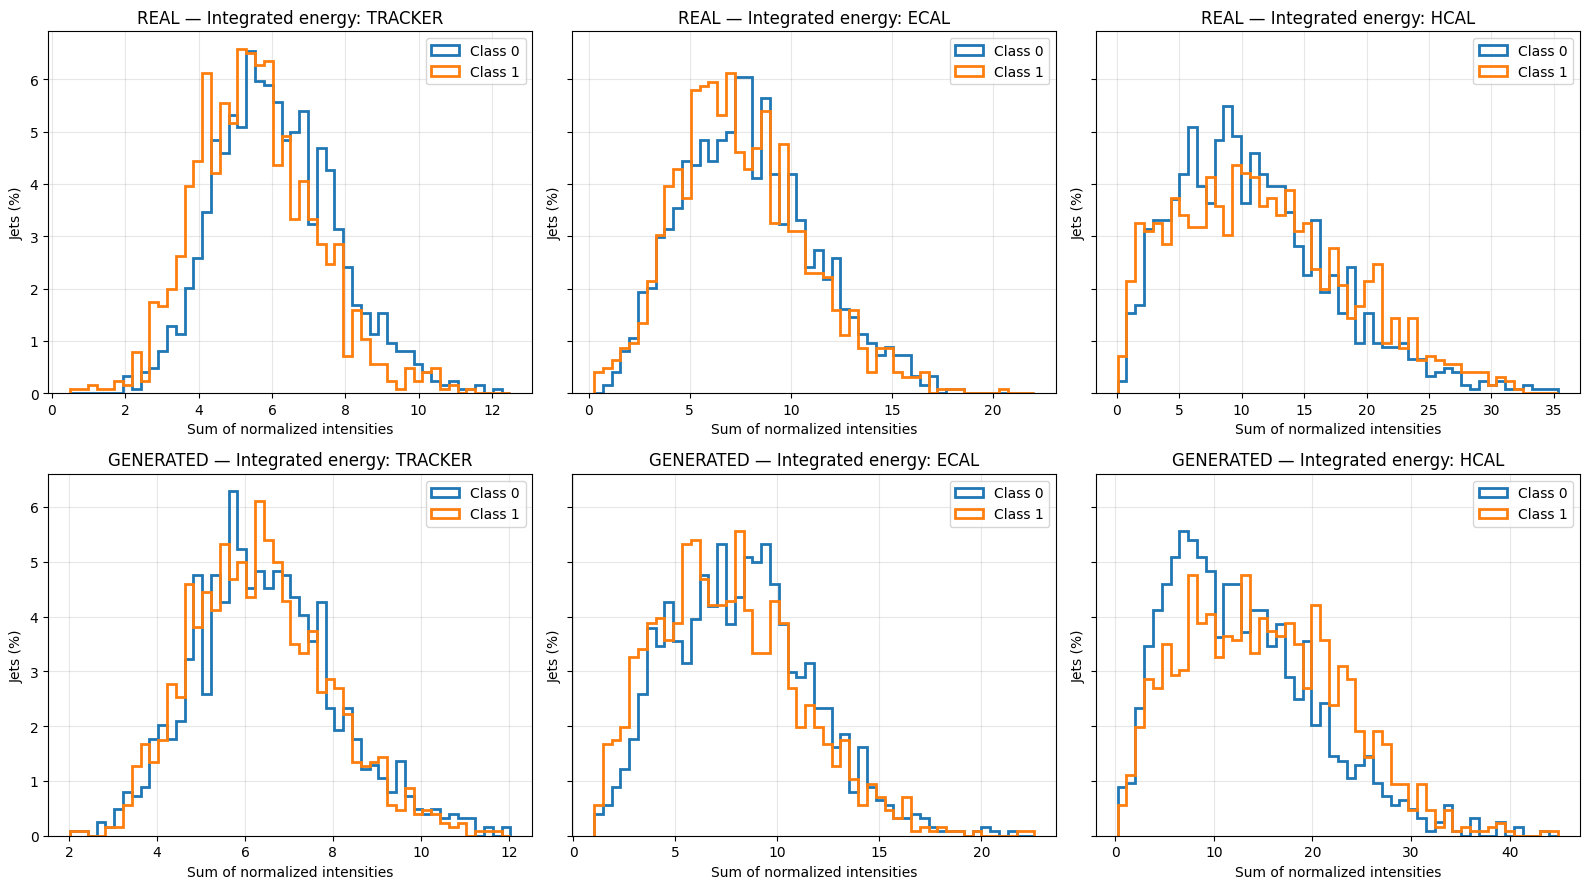

(<Figure size 1600x900 with 6 Axes>,
 array([[<Axes: title={'center': 'REAL — Integrated energy: TRACKER'}, xlabel='Sum of normalized intensities', ylabel='Jets (%)'>,
         <Axes: title={'center': 'REAL — Integrated energy: ECAL'}, xlabel='Sum of normalized intensities', ylabel='Jets (%)'>,
         <Axes: title={'center': 'REAL — Integrated energy: HCAL'}, xlabel='Sum of normalized intensities', ylabel='Jets (%)'>],
        [<Axes: title={'center': 'GENERATED — Integrated energy: TRACKER'}, xlabel='Sum of normalized intensities', ylabel='Jets (%)'>,
         <Axes: title={'center': 'GENERATED — Integrated energy: ECAL'}, xlabel='Sum of normalized intensities', ylabel='Jets (%)'>,
         <Axes: title={'center': 'GENERATED — Integrated energy: HCAL'}, xlabel='Sum of normalized intensities', ylabel='Jets (%)'>]],
       dtype=object))

In [100]:
plot_real_vs_generated_class_separation(
    real_diag=real_diag, generated_diag=gen_diag, real_labels=ldm_test_labels,
    generated_labels=generated_labels_2500, metric='energy', num_bins=50, upper_quantile=0.999,
    class_0_name='Class 0', class_1_name='Class 1',
)

REAL -> Class 0: 1240 | Class 1: 1260
GENERATED -> Class 0: 1240 | Class 1: 1260


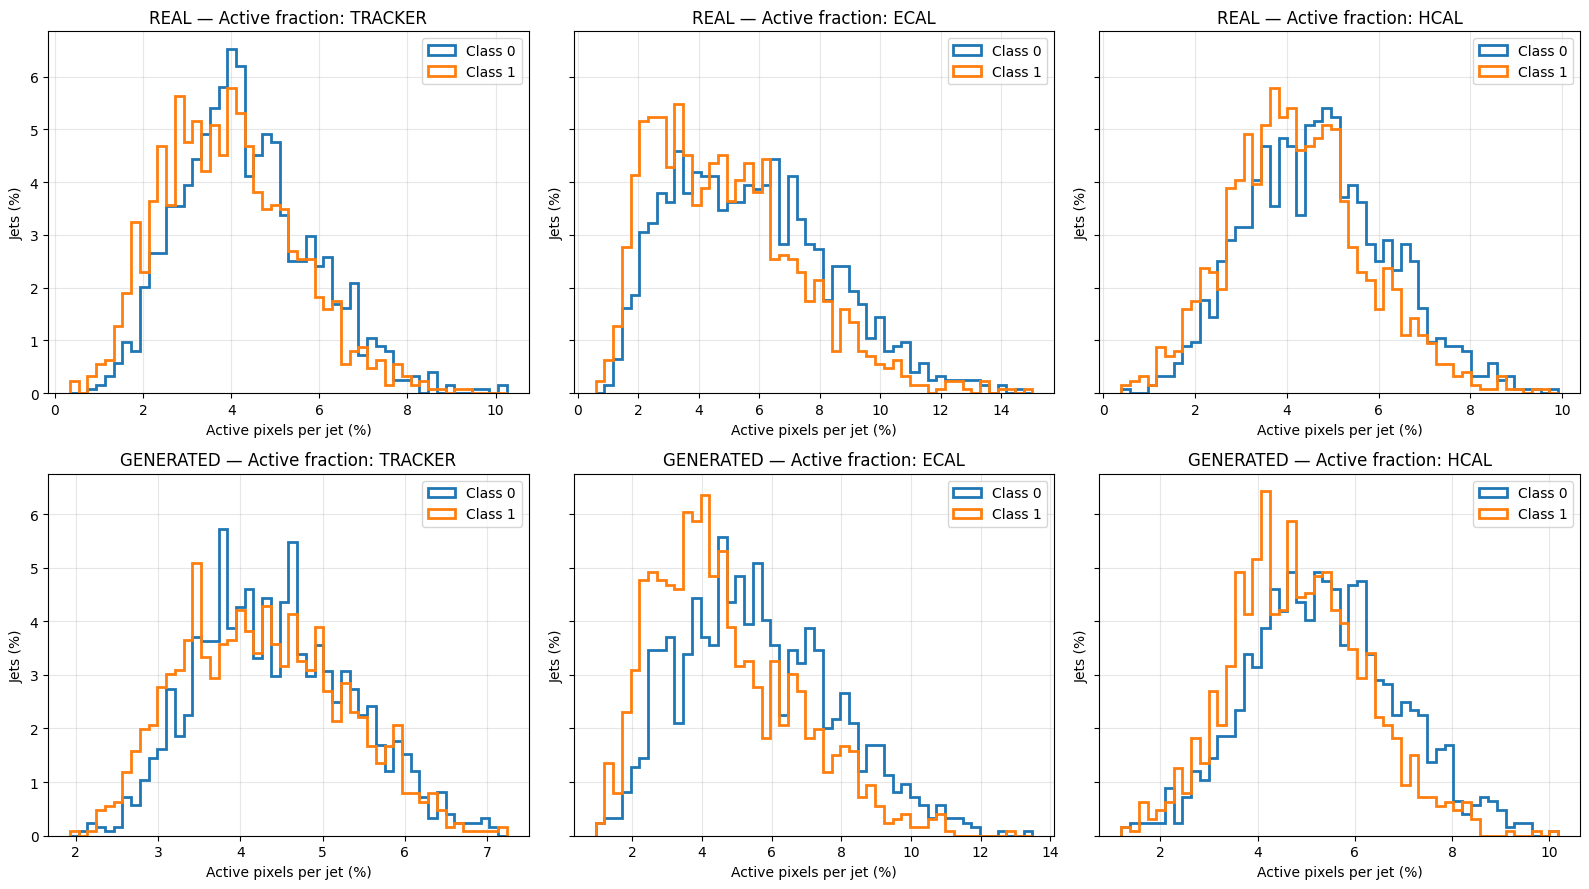

(<Figure size 1600x900 with 6 Axes>,
 array([[<Axes: title={'center': 'REAL — Active fraction: TRACKER'}, xlabel='Active pixels per jet (%)', ylabel='Jets (%)'>,
         <Axes: title={'center': 'REAL — Active fraction: ECAL'}, xlabel='Active pixels per jet (%)', ylabel='Jets (%)'>,
         <Axes: title={'center': 'REAL — Active fraction: HCAL'}, xlabel='Active pixels per jet (%)', ylabel='Jets (%)'>],
        [<Axes: title={'center': 'GENERATED — Active fraction: TRACKER'}, xlabel='Active pixels per jet (%)', ylabel='Jets (%)'>,
         <Axes: title={'center': 'GENERATED — Active fraction: ECAL'}, xlabel='Active pixels per jet (%)', ylabel='Jets (%)'>,
         <Axes: title={'center': 'GENERATED — Active fraction: HCAL'}, xlabel='Active pixels per jet (%)', ylabel='Jets (%)'>]],
       dtype=object))

In [101]:
plot_real_vs_generated_class_separation(
    real_diag=real_diag, generated_diag=gen_diag, real_labels=ldm_test_labels,
    generated_labels=generated_labels_2500, metric='active_fraction', num_bins=50, upper_quantile=0.999,
    class_0_name='Class 0', class_1_name='Class 1',
)

REAL -> Class 0: 1240 | Class 1: 1260
GENERATED -> Class 0: 1240 | Class 1: 1260


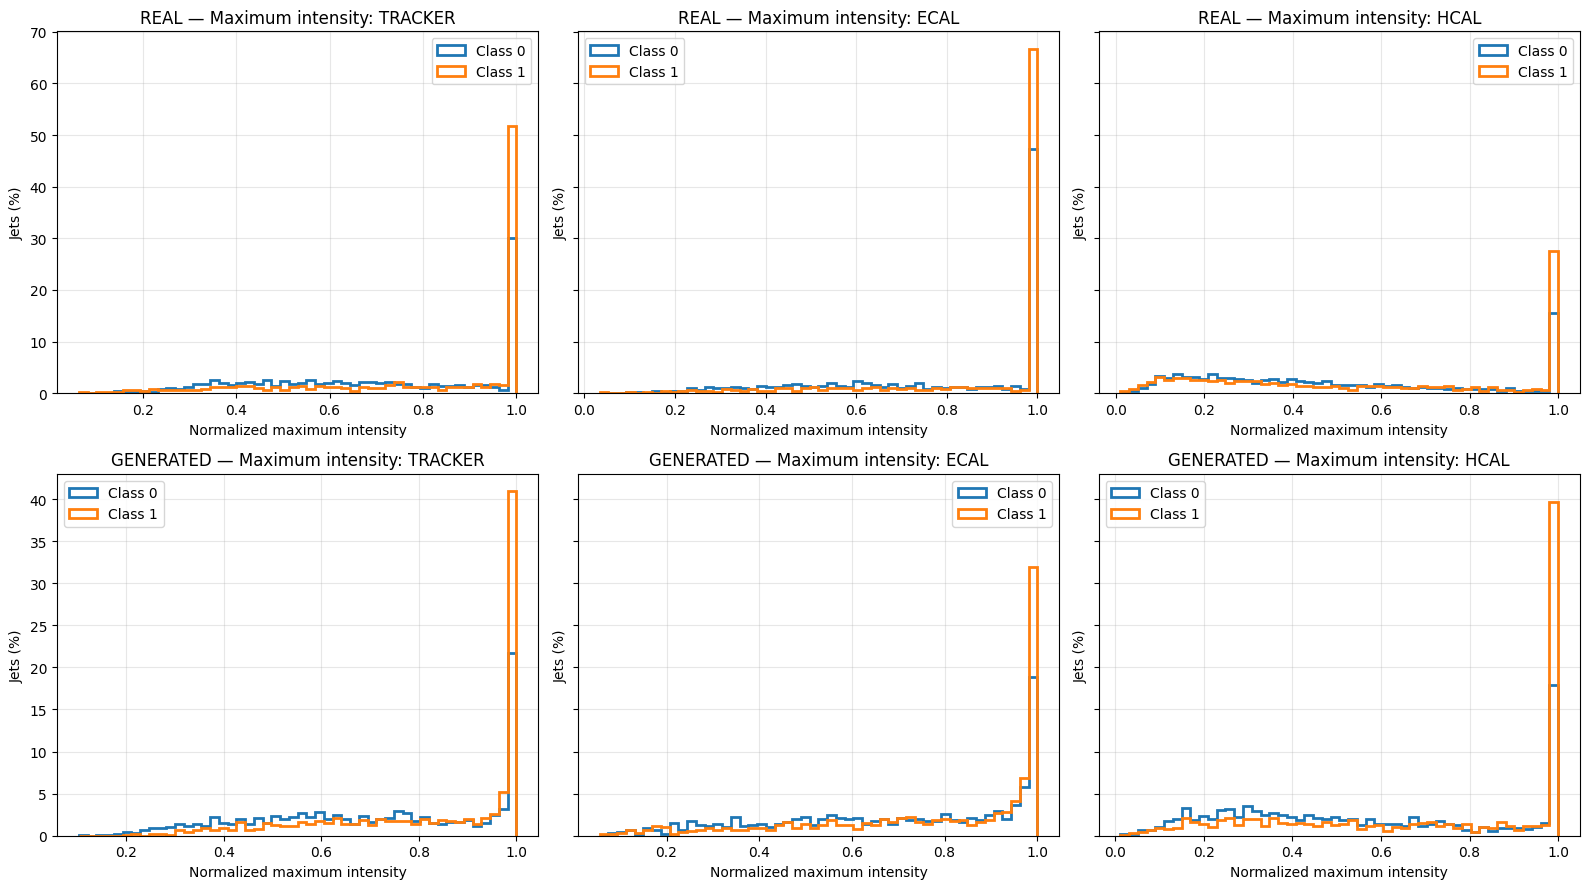

(<Figure size 1600x900 with 6 Axes>,
 array([[<Axes: title={'center': 'REAL — Maximum intensity: TRACKER'}, xlabel='Normalized maximum intensity', ylabel='Jets (%)'>,
         <Axes: title={'center': 'REAL — Maximum intensity: ECAL'}, xlabel='Normalized maximum intensity', ylabel='Jets (%)'>,
         <Axes: title={'center': 'REAL — Maximum intensity: HCAL'}, xlabel='Normalized maximum intensity', ylabel='Jets (%)'>],
        [<Axes: title={'center': 'GENERATED — Maximum intensity: TRACKER'}, xlabel='Normalized maximum intensity', ylabel='Jets (%)'>,
         <Axes: title={'center': 'GENERATED — Maximum intensity: ECAL'}, xlabel='Normalized maximum intensity', ylabel='Jets (%)'>,
         <Axes: title={'center': 'GENERATED — Maximum intensity: HCAL'}, xlabel='Normalized maximum intensity', ylabel='Jets (%)'>]],
       dtype=object))

In [102]:
plot_real_vs_generated_class_separation(
    real_diag=real_diag, generated_diag=gen_diag, real_labels=ldm_test_labels,
    generated_labels=generated_labels_2500, metric='maximum', num_bins=50, upper_quantile=0.999,
    class_0_name='Class 0', class_1_name='Class 1',
)

In [103]:
@torch.no_grad()
def reconstruct_dataset_with_vae_hard(vae_model, data_loader, device=device):
    vae_model.eval()
    reconstruction_batches = []

    for images, _ in tqdm(data_loader, desc='Reconstruyendo test con VAE'):
        images = images.to(device, non_blocking=True)
        mu, _ = vae_model.encode(images)
        reconstruction_m11 = vae_model.decode_hard(mu)
        reconstruction_01 = ((reconstruction_m11 + 1.0) / 2.0).clamp(0.0, 1.0)

        reconstruction_batches.append(reconstruction_01.detach().cpu())

    return torch.cat(reconstruction_batches, dim=0)

In [104]:
vae_reconstructed_test_01 = reconstruct_dataset_with_vae_hard(vae_model=vae_model, data_loader=test_loader, device=device)
print('Shape:', vae_reconstructed_test_01.shape)

Reconstruyendo test con VAE:   0%|          | 0/157 [00:00<?, ?it/s]

Shape: torch.Size([2500, 3, 64, 64])


In [105]:
vae_diag = collect_image_diagnostics(vae_reconstructed_test_01, active_thr_01=0.0001, num_radial_bins=32)

In [106]:
def compare_real_vae_ldm(real_diag, vae_diag, ldm_diag):
    rows = []

    for channel, channel_name in enumerate(CHANNEL_NAMES):
        energy_real = real_diag['energy'][:, channel]
        energy_vae = vae_diag['energy'][:, channel]
        energy_ldm = ldm_diag['energy'][:, channel]
        active_real = real_diag['active_fraction'][:, channel]
        active_vae = vae_diag['active_fraction'][:, channel]
        active_ldm = ldm_diag['active_fraction'][:, channel]
        maximum_real = real_diag['maximum'][:, channel]
        maximum_vae = vae_diag['maximum'][:, channel]
        maximum_ldm = ldm_diag['maximum'][:, channel]
        radial_real = real_diag['radial_profile'][channel]
        radial_vae = vae_diag['radial_profile'][channel]
        radial_ldm = ldm_diag['radial_profile'][channel]
        energy_real_mean = energy_real.mean()

        rows.append({
            'Canal': channel_name,
            'E real': energy_real_mean,
            'E VAE': energy_vae.mean(),
            'E LDM': energy_ldm.mean(),
            'Bias E VAE (%)': 100.0 * (energy_vae.mean() - energy_real_mean) / max(energy_real_mean, 1e-12),
            'Bias E LDM (%)': 100.0 * (energy_ldm.mean() - energy_real_mean) / max(energy_real_mean, 1e-12),
            'W1 E VAE': wasserstein_distance(energy_real, energy_vae),
            'W1 E LDM': wasserstein_distance(energy_real, energy_ldm),
            'Activa real': active_real.mean(),
            'Activa VAE': active_vae.mean(),
            'Activa LDM': active_ldm.mean(),
            'Máximo real': maximum_real.mean(),
            'Máximo VAE': maximum_vae.mean(),
            'Máximo LDM': maximum_ldm.mean(),
            'W1 máximo VAE': wasserstein_distance(maximum_real, maximum_vae),
            'W1 máximo LDM': wasserstein_distance(maximum_real, maximum_ldm),
            'Radial L2 VAE': np.sqrt(np.mean((radial_vae - radial_real) ** 2)),
            'Radial L2 LDM': np.sqrt(np.mean((radial_ldm - radial_real) ** 2)),
        })

    return pd.DataFrame(rows)

In [107]:
comparison_real_vae_ldm = compare_real_vae_ldm(real_diag=real_diag, vae_diag=vae_diag, ldm_diag=gen_diag)
display(comparison_real_vae_ldm.round(6))

,Canal,E real,E VAE,E LDM,Bias E VAE (%),Bias E LDM (%),W1 E VAE,W1 E LDM,Activa real,Activa VAE,Activa LDM,Máximo real,Máximo VAE,Máximo LDM,W1 máximo VAE,W1 máximo LDM,Radial L2 VAE,Radial L2 LDM
0,TRACKER,5.859265,5.982152,6.418932,2.097321,9.551832,0.127645,0.594271,0.041333,0.041391,0.043583,0.760318,0.770516,0.767902,0.014465,0.029088,0.002997,0.005855
1,ECAL,7.773422,7.762304,7.932530,-0.143031,2.046829,0.046432,0.316151,0.053148,0.052865,0.051317,0.826301,0.827983,0.738226,0.013343,0.088194,0.001651,0.003263
2,HCAL,11.419732,11.729982,13.996000,2.716791,22.559797,0.314847,2.576269,0.044677,0.044611,0.051227,0.523041,0.536219,0.622550,0.013780,0.099510,0.000851,0.006579


In [108]:
baseline_val_normal = evaluate_latent_ddpm_epoch(
    model=ldm_model_first, data_loader=ldm_val_loader, scheduler=ldm_scheduler, device=device,
    fixed_conditions=FIXED_LDM_VAL_CONDITIONS,
)
print('Baseline normal:', baseline_val_normal)

Baseline normal: 0.6492232751846313


In [109]:
def zero_bottleneck_output(module, inputs, output):
    return torch.zeros_like(output)

hook = ldm_model_first.mid.register_forward_hook(zero_bottleneck_output)
baseline_val_zero_mid = evaluate_latent_ddpm_epoch(
    model=ldm_model_first, data_loader=ldm_val_loader, scheduler=ldm_scheduler, device=device,
    fixed_conditions=FIXED_LDM_VAL_CONDITIONS,
)
hook.remove()
print('Baseline normal:', baseline_val_normal)
print('Bottleneck = 0:', baseline_val_zero_mid)
print('Delta:', baseline_val_zero_mid - baseline_val_normal)

Baseline normal: 0.6492232751846313
Bottleneck = 0: 0.6637451392173767
Delta: 0.014521864032745357


In [110]:
class ZeroVPredictor(nn.Module):

    def forward(
        self,
        x,
        t,
        labels,
    ):
        return torch.zeros_like(x)

zero_v_model = ZeroVPredictor().to(device)

zero_v_validation_loss = evaluate_latent_ddpm_epoch(
    model=zero_v_model, data_loader=ldm_val_loader, scheduler=ldm_scheduler, device=device,
    fixed_conditions=FIXED_LDM_VAL_CONDITIONS,
)

print('Zero-v validation:', zero_v_validation_loss)

print('Classical validation:', baseline_val_normal)

print('Improvement:', zero_v_validation_loss - baseline_val_normal)

Zero-v validation: 1.0460187562942505
Classical validation: 0.6492232751846313
Improvement: 0.39679548110961915


In [111]:
class AblatedReducedUNET(nn.Module):

    def __init__(
        self,
        backbone,
        ablation=None,
    ):
        super().__init__()

        self.backbone = backbone
        self.ablation = ablation

    def forward(
        self,
        x,
        t,
        labels,
    ):

        time_embedding = (
            self.backbone.time_mlp(t)
        )

        class_embedding = (
            self.backbone.class_embedding(
                labels.long()
            )
        )

        condition_embedding = (
            time_embedding
            + class_embedding
        )

        x = self.backbone.conv_in(x)

        skips = []

        skip_names = [
            "skip_16",
            "skip_8",
            "skip_4",
        ]

        for index, down in enumerate(
            self.backbone.downs
        ):

            x, skip = down(
                x,
                condition_embedding,
            )

            if (
                self.ablation
                == skip_names[index]
            ):
                skip = torch.zeros_like(
                    skip
                )

            skips.append(skip)

        x = self.backbone.mid(
            x,
            condition_embedding,
        )

        if self.ablation == "mid":
            x = torch.zeros_like(x)

        for up in self.backbone.ups:

            skip = skips.pop()

            x = up(
                x,
                skip,
                condition_embedding,
            )

        x = self.backbone.norm_out(x)

        x = F.silu(x)

        return self.backbone.conv_out(x)

In [112]:
ablation_cases = [('Normal', None), ('Skip 16x16 = 0', 'skip_16'), ('Skip 8x8 = 0', 'skip_8'), ('Skip 4x4 = 0', 'skip_4'), ('Bottleneck = 0', 'mid')]
ablation_results = []

for name, ablation in ablation_cases:
    ablated_model = AblatedReducedUNET(backbone=ldm_model_first, ablation=ablation)
    validation_loss = evaluate_latent_ddpm_epoch(
        model=ablated_model, data_loader=ldm_val_loader, scheduler=ldm_scheduler, device=device,
        fixed_conditions=FIXED_LDM_VAL_CONDITIONS,
    )
    ablation_results.append({'component': name, 'validation_loss': validation_loss, 'delta_vs_baseline': validation_loss - baseline_val_normal})

ablation_results_df = pd.DataFrame(ablation_results)
display(ablation_results_df.round(6))

,component,validation_loss,delta_vs_baseline
0,Normal,0.649223,0.000000
1,Skip 16x16 = 0,0.907406,0.258182
2,Skip 8x8 = 0,0.717276,0.068052
3,Skip 4x4 = 0,0.653295,0.004072
4,Bottleneck = 0,0.663745,0.014522


In [113]:
@torch.no_grad()
def evaluate_latent_ddpm_by_timestep_bins(model, data_loader, scheduler, device, fixed_conditions, bin_width=100):
    model.eval()
    rows = []

    for start in range(0, scheduler.num_timesteps, bin_width):
        end = min(start + bin_width, scheduler.num_timesteps)
        loss_sum = 0.0
        v_loss_sum = 0.0
        tail_loss_sum = 0.0
        count = 0

        for batch_index, (z0, labels) in enumerate(data_loader):
            z0 = z0.float().to(device)
            labels = labels.long().to(device)
            timesteps_cpu, noise_cpu = fixed_conditions[batch_index]
            timesteps = timesteps_cpu.to(device=device, dtype=torch.long)
            noise = noise_cpu.to(device=device, dtype=z0.dtype)
            mask = (timesteps >= start) & (timesteps < end)

            if not mask.any():
                continue

            noisy_latents, noise_used = scheduler.add_noise(z0, timesteps, noise)
            v_target = compute_v_target(z0=z0, noise=noise_used, timesteps=timesteps, scheduler=scheduler)
            v_prediction = model(noisy_latents, timesteps, labels)
            n = int(mask.sum().item())
            loss, components = latent_v_loss(
                z0=z0[mask], z_t=noisy_latents[mask], v_prediction=v_prediction[mask], v_target=v_target[mask],
                timesteps=timesteps[mask], scheduler=scheduler, tail_loss_weight=0.15,
            )
            loss_sum += components['loss'].item() * n
            v_loss_sum += components['v_loss'].item() * n
            tail_loss_sum += components['tail_loss'].item() * n
            count += n

        rows.append({
            't_range': f'{start:03d}-{end - 1:03d}',
            'n': count,
            'loss': loss_sum / max(count, 1),
            'v_loss': v_loss_sum / max(count, 1),
            'tail_loss': tail_loss_sum / max(count, 1),
        })

    return pd.DataFrame(rows)

In [114]:
classical_timestep_results = evaluate_latent_ddpm_by_timestep_bins(
    model=ldm_model_first, data_loader=ldm_val_loader, scheduler=ldm_scheduler, device=device,
    fixed_conditions=FIXED_LDM_VAL_CONDITIONS, bin_width=100,
)
zero_timestep_results = evaluate_latent_ddpm_by_timestep_bins(
    model=zero_v_model, data_loader=ldm_val_loader, scheduler=ldm_scheduler, device=device,
    fixed_conditions=FIXED_LDM_VAL_CONDITIONS, bin_width=100,
)
timestep_comparison = pd.DataFrame({
    't_range': classical_timestep_results['t_range'],
    'n': classical_timestep_results['n'],
    'zero_loss': zero_timestep_results['loss'],
    'classical_loss': classical_timestep_results['loss'],
})
timestep_comparison['absolute_gain'] = timestep_comparison['zero_loss'] - timestep_comparison['classical_loss']
timestep_comparison['relative_gain_pct'] = 100.0 * timestep_comparison['absolute_gain'] / timestep_comparison['zero_loss']

display(timestep_comparison.round(6))

,t_range,n,zero_loss,classical_loss,absolute_gain,relative_gain_pct
0,000-099,236,1.003658,0.733840,0.269818,26.883461
1,100-199,269,1.016860,0.542875,0.473985,46.612602
2,200-299,250,1.030370,0.489130,0.541240,52.528738
3,300-399,222,1.055307,0.487011,0.568296,53.851252
4,400-499,252,1.041588,0.560672,0.480916,46.171436
5,500-599,244,1.079365,0.645017,0.434348,40.241071
6,600-699,264,1.069292,0.696594,0.372699,34.854716
7,700-799,247,1.059438,0.764975,0.294463,27.794250
8,800-899,268,1.030169,0.754065,0.276104,26.801799
9,900-999,248,1.076100,0.805755,0.270345,25.122645


In [115]:
train_latent_ddpm

<function __main__.train_latent_ddpm(model, train_loader, val_loader, scheduler, device, fixed_validation_conditions, num_epochs=20, learning_rate=0.0001, grad_clip=1.0, checkpoint_path='selective_qldm_last_checkpoint.pt', best_model_path='selective_qldm_best_model.pt', resume=False)>

## Hybrid Multiscale Quantum U-Net

This experiment uses the exact hybrid path $16\times16_Q \rightarrow 8\times8_Q \rightarrow 4\times4_C \rightarrow 2\times2_C$ bottleneck $\rightarrow 4\times4_C \rightarrow 8\times8_Q \rightarrow 16\times16_Q$. Only the nonlinear blocks at $16\times16$ and $8\times8$ are quantum; downsampling, upsampling, the $4\times4$ blocks, and the bottleneck remain classical.

In [116]:
import math
import pennylane as qml
QLDM_DEVICE = torch.device('cpu')
QLDM_NUM_QUBITS = 8
QLDM_Q_LAYERS = 3
QLDM_CONDITION_DIM = 128

print('PennyLane version:', qml.__version__)
print('QLDM device:', QLDM_DEVICE)
print('Qubits:', QLDM_NUM_QUBITS)
print('Quantum layers:', QLDM_Q_LAYERS)

PennyLane version: 0.43.1
QLDM device: cpu
Qubits: 8
Quantum layers: 3


In [117]:
qldm_quantum_device = qml.device('default.qubit', wires=QLDM_NUM_QUBITS, shots=None)


@qml.qnode(
    qldm_quantum_device,
    interface="torch",
    diff_method="backprop",
)
def qldm_quantum_feature_circuit(
    inputs,
    rotation_weights,
    entangling_weights,
):

    feature_values = inputs[..., :QLDM_NUM_QUBITS]

    bounded_features = torch.tanh(
        feature_values
    )

    bounded_features = torch.clamp(
        bounded_features,
        min=-1.0 + 1e-6,
        max=1.0 - 1e-6,
    )

    feature_angles = torch.acos(
        bounded_features
    )

    for qubit in range(
        QLDM_NUM_QUBITS
    ):

        qml.RY(
            feature_angles[..., qubit],
            wires=qubit,
        )

    condition_angles = inputs[
        ...,
        QLDM_NUM_QUBITS:
        2 * QLDM_NUM_QUBITS
    ]

    for qubit in range(
        QLDM_NUM_QUBITS
    ):

        qml.RZ(
            condition_angles[..., qubit],
            wires=qubit,
        )

    for layer in range(
        QLDM_Q_LAYERS
    ):

        for qubit in range(
            QLDM_NUM_QUBITS
        ):

            qml.RY(
                rotation_weights[
                    layer,
                    qubit,
                    0,
                ],
                wires=qubit,
            )

            qml.RZ(
                rotation_weights[
                    layer,
                    qubit,
                    1,
                ],
                wires=qubit,
            )

        for qubit in range(
            QLDM_NUM_QUBITS
        ):

            next_qubit = (
                qubit + 1
            ) % QLDM_NUM_QUBITS

            qml.CRY(
                entangling_weights[
                    layer,
                    qubit,
                ],
                wires=[
                    qubit,
                    next_qubit,
                ],
            )

    return [
        qml.expval(
            qml.PauliZ(qubit)
        )
        for qubit
        in range(QLDM_NUM_QUBITS)
    ]

In [118]:
class QuantumFeatureBlock8(
    nn.Module
):

    def __init__(
        self,
        quantum_init_std=0.02,
    ):

        super().__init__()

        quantum_weight_shapes = {
            "rotation_weights": (
                QLDM_Q_LAYERS,
                QLDM_NUM_QUBITS,
                2,
            ),
            "entangling_weights": (
                QLDM_Q_LAYERS,
                QLDM_NUM_QUBITS,
            ),
        }

        self.quantum_core = (
            qml.qnn.TorchLayer(
                qldm_quantum_feature_circuit,
                weight_shapes=(
                    quantum_weight_shapes
                ),
            )
        )

        for parameter in (
            self.quantum_core.parameters()
        ):

            nn.init.normal_(
                parameter,
                mean=0.0,
                std=quantum_init_std,
            )

    def forward(
        self,
        features,
        condition_angles,
    ):

        if features.ndim != 2:

            raise ValueError(
                "features must have shape [N, 8]. "
                f"Received {features.shape}."
            )

        if condition_angles.ndim != 2:

            raise ValueError(
                "condition_angles must have shape [N, 8]. "
                f"Received {condition_angles.shape}."
            )

        if features.shape[-1] != (
            QLDM_NUM_QUBITS
        ):

            raise ValueError(
                "QuantumFeatureBlock8 requires "
                "exactly 8 features."
            )

        if condition_angles.shape[-1] != (
            QLDM_NUM_QUBITS
        ):

            raise ValueError(
                "QuantumFeatureBlock8 requires "
                "exactly 8 conditioning angles."
            )

        if (
            features.shape[0]
            != condition_angles.shape[0]
        ):

            raise ValueError(
                "features and condition_angles "
                "must have the same batch size."
            )

        quantum_inputs = torch.cat(
            [
                features,
                condition_angles,
            ],
            dim=-1,
        )

        quantum_outputs = (
            self.quantum_core(
                quantum_inputs
            )
            .float()
        )

        return quantum_outputs

### Eight-Qubit Feature Transformation

Each quantumized block first applies a classical $3\times3$ convolution, GroupNorm, and a projection of the timestep-plus-class condition. Output channels are split into groups of eight and processed by independent eight-qubit VQCs. Latent features are angle encoded with $R_Y$, conditioning angles with $R_Z$, and three trainable layers use local $R_Y/R_Z$ rotations followed by a ring of controlled $R_Y$ gates. The measured Pauli-$Z$ expectations replace the classical SiLU activation without a residual bypass.

In [119]:
class SelectiveQuantumConditionedConvBlock(
    nn.Module
):

    def __init__(
        self,
        in_channels,
        out_channels,
        condition_dim,
    ):

        super().__init__()

        if (
            out_channels
            % QLDM_NUM_QUBITS
            != 0
        ):

            raise ValueError(
                "out_channels must be divisible "
                "by 8."
            )

        self.in_channels = in_channels
        self.out_channels = out_channels

        self.num_quantum_groups = (
            out_channels
            // QLDM_NUM_QUBITS
        )

        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1,
        )

        self.norm = nn.GroupNorm(
            get_num_groups(
                out_channels
            ),
            out_channels,
        )

        self.condition_projection = nn.Linear(
            condition_dim,
            out_channels,
        )

        self.quantum_groups = nn.ModuleList(
            [
                QuantumFeatureBlock8()

                for _ in range(
                    self.num_quantum_groups
                )
            ]
        )

    def forward(
        self,
        x,
        condition_embedding,
    ):

        h = self.conv(x)

        h = self.norm(h)

        condition = (
            self.condition_projection(
                F.silu(
                    condition_embedding
                )
            )
        )

        condition_angles = (
            math.pi
            * torch.tanh(
                condition
            )
        )

        (
            batch_size,
            channels,
            height,
            width,
        ) = h.shape

        grouped_features = h.reshape(
            batch_size,
            self.num_quantum_groups,
            QLDM_NUM_QUBITS,
            height,
            width,
        )

        quantum_outputs = []

        for group_index in range(
            self.num_quantum_groups
        ):

            group_features = (
                grouped_features[
                    :,
                    group_index,
                ]
                .permute(
                    0,
                    2,
                    3,
                    1,
                )
                .contiguous()
                .reshape(
                    -1,
                    QLDM_NUM_QUBITS,
                )
            )

            channel_start = (
                group_index
                * QLDM_NUM_QUBITS
            )

            channel_end = (
                channel_start
                + QLDM_NUM_QUBITS
            )

            group_condition = (
                condition_angles[
                    :,
                    channel_start:
                    channel_end,
                ]
            )

            group_condition = (
                group_condition[
                    :,
                    None,
                    None,
                    :,
                ]
                .expand(
                    batch_size,
                    height,
                    width,
                    QLDM_NUM_QUBITS,
                )
                .reshape(
                    -1,
                    QLDM_NUM_QUBITS,
                )
            )

            group_output = (
                self.quantum_groups[
                    group_index
                ](
                    group_features,
                    group_condition,
                )
            )

            group_output = (
                group_output
                .reshape(
                    batch_size,
                    height,
                    width,
                    QLDM_NUM_QUBITS,
                )
                .permute(
                    0,
                    3,
                    1,
                    2,
                )
                .contiguous()
            )

            quantum_outputs.append(
                group_output
            )

        output = torch.cat(
            quantum_outputs,
            dim=1,
        )

        return output

In [120]:
class SelectiveMultiscaleQuantumUNET(
    ReducedConditionalUNET
):

    def __init__(
        self,
        im_channels=4,
        base_channels=32,
        channel_mults=(1, 2, 4),
        t_emb_dim=128,
        num_classes=2,
    ):

        super().__init__(
            im_channels=im_channels,
            base_channels=base_channels,
            channel_mults=channel_mults,
            t_emb_dim=t_emb_dim,
            num_classes=num_classes,
        )

        old_block = (
            self.downs[0].block
        )

        self.downs[0].block = (
            SelectiveQuantumConditionedConvBlock(
                in_channels=(
                    old_block.conv.in_channels
                ),
                out_channels=(
                    old_block.conv.out_channels
                ),
                condition_dim=t_emb_dim,
            )
        )

        old_block = (
            self.downs[1].block
        )

        self.downs[1].block = (
            SelectiveQuantumConditionedConvBlock(
                in_channels=(
                    old_block.conv.in_channels
                ),
                out_channels=(
                    old_block.conv.out_channels
                ),
                condition_dim=t_emb_dim,
            )
        )

        old_block = (
            self.ups[1].block
        )

        self.ups[1].block = (
            SelectiveQuantumConditionedConvBlock(
                in_channels=(
                    old_block.conv.in_channels
                ),
                out_channels=(
                    old_block.conv.out_channels
                ),
                condition_dim=t_emb_dim,
            )
        )

        old_block = (
            self.ups[2].block
        )

        self.ups[2].block = (
            SelectiveQuantumConditionedConvBlock(
                in_channels=(
                    old_block.conv.in_channels
                ),
                out_channels=(
                    old_block.conv.out_channels
                ),
                condition_dim=t_emb_dim,
            )
        )

In [121]:
SELECTIVE_SEED = SEED + 14000
seed_everything(SELECTIVE_SEED)
selective_qldm_model = SelectiveMultiscaleQuantumUNET(
    im_channels=4, base_channels=32, channel_mults=(1, 2, 4), t_emb_dim=128, num_classes=NUM_CLASSES,
).to(QLDM_DEVICE)
selective_quantum_blocks = [module for module in selective_qldm_model.modules() if isinstance(module, QuantumFeatureBlock8)]
selective_num_quantum_cores = len(selective_quantum_blocks)
selective_quantum_parameters = sum(
    parameter.numel()
    for block in selective_quantum_blocks
    for parameter in block.quantum_core.parameters()
    if parameter.requires_grad
)
selective_total_parameters = sum((parameter.numel() for parameter in selective_qldm_model.parameters() if parameter.requires_grad))

print('Quantum cores:', selective_num_quantum_cores)
print('Quantum parameters:', selective_quantum_parameters)
print('Total parameters:', selective_total_parameters)
print()
print('Down 16:', type(selective_qldm_model.downs[0].block).__name__)
print('Down 8:', type(selective_qldm_model.downs[1].block).__name__)
print('Down 4:', type(selective_qldm_model.downs[2].block).__name__)
print('Mid:', type(selective_qldm_model.mid).__name__)
print('Up 4:', type(selective_qldm_model.ups[0].block).__name__)
print('Up 8:', type(selective_qldm_model.ups[1].block).__name__)
print('Up 16:', type(selective_qldm_model.ups[2].block).__name__)

selective_scheduler = LinearNoiseScheduler(num_timesteps=LDM_NUM_TIMESTEPS, beta_s=LDM_BETA_START, beta_e=LDM_BETA_END, device=QLDM_DEVICE)
test_z0 = ldm_train_latents[:2].float().to(QLDM_DEVICE)
test_labels = ldm_train_labels[:2].long().to(QLDM_DEVICE)
test_t = torch.tensor([300, 700], dtype=torch.long, device=QLDM_DEVICE)
test_noise = torch.randn_like(test_z0)
test_z_t, test_noise_used = selective_scheduler.add_noise(test_z0, test_t, test_noise)
test_v_target = compute_v_target(z0=test_z0, noise=test_noise_used, timesteps=test_t, scheduler=selective_scheduler)

selective_qldm_model.zero_grad(set_to_none=True)
test_prediction = selective_qldm_model(test_z_t, test_t, test_labels)
test_loss = F.mse_loss(test_prediction, test_v_target)
test_loss.backward()
quantum_gradients = [
    parameter.grad.norm().item()
    for block in selective_quantum_blocks
    for parameter in block.quantum_core.parameters()
    if parameter.grad is not None
]
print()
print('Input:', tuple(test_z_t.shape))
print('Output:', tuple(test_prediction.shape))
print('Finite:', torch.isfinite(test_prediction).all().item())
print('Test loss:', test_loss.item())
print('Quantum gradient count:', len(quantum_gradients))
print('Quantum gradient min:', min(quantum_gradients))
print('Quantum gradient max:', max(quantum_gradients))

Quantum cores: 20
Quantum parameters: 1440
Total parameters: 1129316

Down 16: SelectiveQuantumConditionedConvBlock
Down 8: SelectiveQuantumConditionedConvBlock
Down 4: SimpleConditionedConvBlock
Mid: SimpleConditionedConvBlock
Up 4: SimpleConditionedConvBlock
Up 8: SelectiveQuantumConditionedConvBlock
Up 16: SelectiveQuantumConditionedConvBlock

Input: (2, 4, 16, 16)
Output: (2, 4, 16, 16)
Finite: True
Test loss: 1.0345900058746338
Quantum gradient count: 40
Quantum gradient min: 0.0015544698107987642
Quantum gradient max: 0.05661802366375923


### Controlled Pilot and Classical Comparison

The notebook checks output shapes and quantum gradients before training the hybrid model on a balanced 1,024-sample subset. A classical U-Net control uses the same data split, diffusion schedule, validation conditions, optimizer settings, and generation seed so the comparison isolates the effect of the quantum nonlinear blocks.

In [126]:
SELECTIVE_PILOT_TRAIN_SIZE = 1024
SELECTIVE_PILOT_VAL_SIZE = 256
SELECTIVE_PILOT_BATCH_SIZE = 16
SELECTIVE_PILOT_EPOCHS = 20
SELECTIVE_PILOT_LR = 0.001
selective_pilot_generator = torch.Generator().manual_seed(SEED + 9200)


def selective_balanced_indices(labels, per_class, generator):
    class_0_indices = torch.where(labels == 0)[0]
    class_1_indices = torch.where(labels == 1)[0]
    class_0_perm = torch.randperm(len(class_0_indices), generator=generator)
    class_1_perm = torch.randperm(len(class_1_indices), generator=generator)
    selected_0 = class_0_indices[class_0_perm[:per_class]]
    selected_1 = class_1_indices[class_1_perm[:per_class]]
    selected = torch.cat([selected_0, selected_1])
    final_perm = torch.randperm(len(selected), generator=generator)

    return selected[final_perm]

selective_train_indices = selective_balanced_indices(labels=ldm_train_labels, per_class=512, generator=selective_pilot_generator)
selective_val_indices = selective_balanced_indices(labels=ldm_val_labels, per_class=128, generator=selective_pilot_generator)
selective_train_dataset = TensorDataset(ldm_train_latents[selective_train_indices].float(), ldm_train_labels[selective_train_indices].long())
selective_val_dataset = TensorDataset(ldm_val_latents[selective_val_indices].float(), ldm_val_labels[selective_val_indices].long())
selective_loader_generator = torch.Generator().manual_seed(SEED + 9300)
selective_train_loader = DataLoader(
    selective_train_dataset, batch_size=SELECTIVE_PILOT_BATCH_SIZE, shuffle=True, num_workers=0,
    generator=selective_loader_generator,
)
selective_val_loader = DataLoader(selective_val_dataset, batch_size=SELECTIVE_PILOT_BATCH_SIZE, shuffle=False, num_workers=0)
SELECTIVE_FIXED_VAL_CONDITIONS = build_fixed_validation_conditions(data_loader=selective_val_loader, num_timesteps=LDM_NUM_TIMESTEPS, seed=SEED + 9400)

print('Train:', len(selective_train_dataset))
print('Train classes:', torch.unique(selective_train_dataset.tensors[1], return_counts=True))
print('Validation:', len(selective_val_dataset))
print('Validation classes:', torch.unique(selective_val_dataset.tensors[1], return_counts=True))
print('Training batches:', len(selective_train_loader))
print('Validation batches:', len(selective_val_loader))

Train: 1024
Train classes: (tensor([0, 1]), tensor([512, 512]))
Validation: 256
Validation classes: (tensor([0, 1]), tensor([128, 128]))
Training batches: 64
Validation batches: 16


In [127]:
seed_everything(SELECTIVE_SEED + 100)
selective_pilot_model = SelectiveMultiscaleQuantumUNET(
    im_channels=4, base_channels=32, channel_mults=(1, 2, 4), t_emb_dim=128, num_classes=NUM_CLASSES,
).to(QLDM_DEVICE)
seed_everything(SELECTIVE_SEED + 200)
selective_pilot_history = train_latent_ddpm(
    model=selective_pilot_model, train_loader=selective_train_loader, val_loader=selective_val_loader,
    scheduler=selective_scheduler, device=QLDM_DEVICE,
    fixed_validation_conditions=SELECTIVE_FIXED_VAL_CONDITIONS, num_epochs=SELECTIVE_PILOT_EPOCHS,
    learning_rate=SELECTIVE_PILOT_LR, grad_clip=1.0, checkpoint_path='selective_qldm_last_checkpoint.pt',
    best_model_path='selective_qldm_best_model.pt', resume=True,
)
selective_best_val = min(selective_pilot_history['val'])
selective_best_epoch = int(np.argmin(selective_pilot_history['val'])) + 1

print()
print('Selective best validation:', selective_best_val)
print('Best epoch:', selective_best_epoch)


Checkpoint cargado. Última época terminada: 10
Continuando desde la época 11.



LDM Epoch 11/20:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 11/20 | train=0.709650 | val=0.693795 | lr=1.00e-03 | time=1438.17s
  -> Mejor modelo guardado (epoch 11, val=0.693795)
  -> Checkpoint guardado (epoch 11)


LDM Epoch 12/20:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 12/20 | train=0.707776 | val=0.688924 | lr=1.00e-03 | time=1429.78s
  -> Mejor modelo guardado (epoch 12, val=0.688924)
  -> Checkpoint guardado (epoch 12)


...

Epoch 18/20 | train=0.697488 | val=0.679248 | lr=1.00e-03 | time=1413.90s
  -> Mejor modelo guardado (epoch 18, val=0.679248)
  -> Checkpoint guardado (epoch 18)


LDM Epoch 19/20:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 19/20 | train=0.693964 | val=0.680374 | lr=1.00e-03 | time=1410.90s
  -> Checkpoint guardado (epoch 19)


LDM Epoch 20/20:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 20/20 | train=0.693384 | val=0.684978 | lr=1.00e-03 | time=1420.08s
  -> Checkpoint guardado (epoch 20)

Mejor validation loss: 0.679248

Selective best validation: 0.67924789711833
Best epoch: 18


In [128]:
quantum_val_loss = evaluate_latent_ddpm_epoch(
    model=selective_pilot_model, data_loader=selective_val_loader, scheduler=selective_scheduler,
    device=QLDM_DEVICE, fixed_conditions=SELECTIVE_FIXED_VAL_CONDITIONS,
)
classical_same_subset_loss = evaluate_latent_ddpm_epoch(
    model=ldm_model_first.to(QLDM_DEVICE), data_loader=selective_val_loader, scheduler=selective_scheduler,
    device=QLDM_DEVICE, fixed_conditions=SELECTIVE_FIXED_VAL_CONDITIONS,
)
print('Quantum validation :', quantum_val_loss)
print('Classical validation:', classical_same_subset_loss)

Quantum validation : 0.67924789711833
Classical validation: 0.6303192004561424


In [129]:
ldm_model_first = ldm_model_first.to(device)

In [130]:
NUM_QUANTUM_SAMPLES = 8
quantum_labels = torch.tensor([0] * 4 + [1] * 4, dtype=torch.long)
quantum_latents_std = generate_standardized_latents_ddpm(
    model=selective_pilot_model, scheduler=selective_scheduler, num_samples=NUM_QUANTUM_SAMPLES,
    class_labels=quantum_labels, latent_shape=(4, 16, 16), device=QLDM_DEVICE, seed=SEED,
)

Generando latentes DDPM:   0%|          | 0/1000 [00:00<?, ?it/s]

In [131]:
quantum_latents = quantum_latents_std * latent_std_train.to(QLDM_DEVICE) + latent_mean_train.to(QLDM_DEVICE)
print('Latentes:', quantum_latents.shape)
print('Finitos:', torch.isfinite(quantum_latents).all().item())

Latentes: torch.Size([8, 4, 16, 16])
Finitos: True


In [132]:
with torch.no_grad():
    quantum_generated_images = decode_generated_latents(vae_model=vae_model, latent_tensor=quantum_latents.to(device)).cpu()

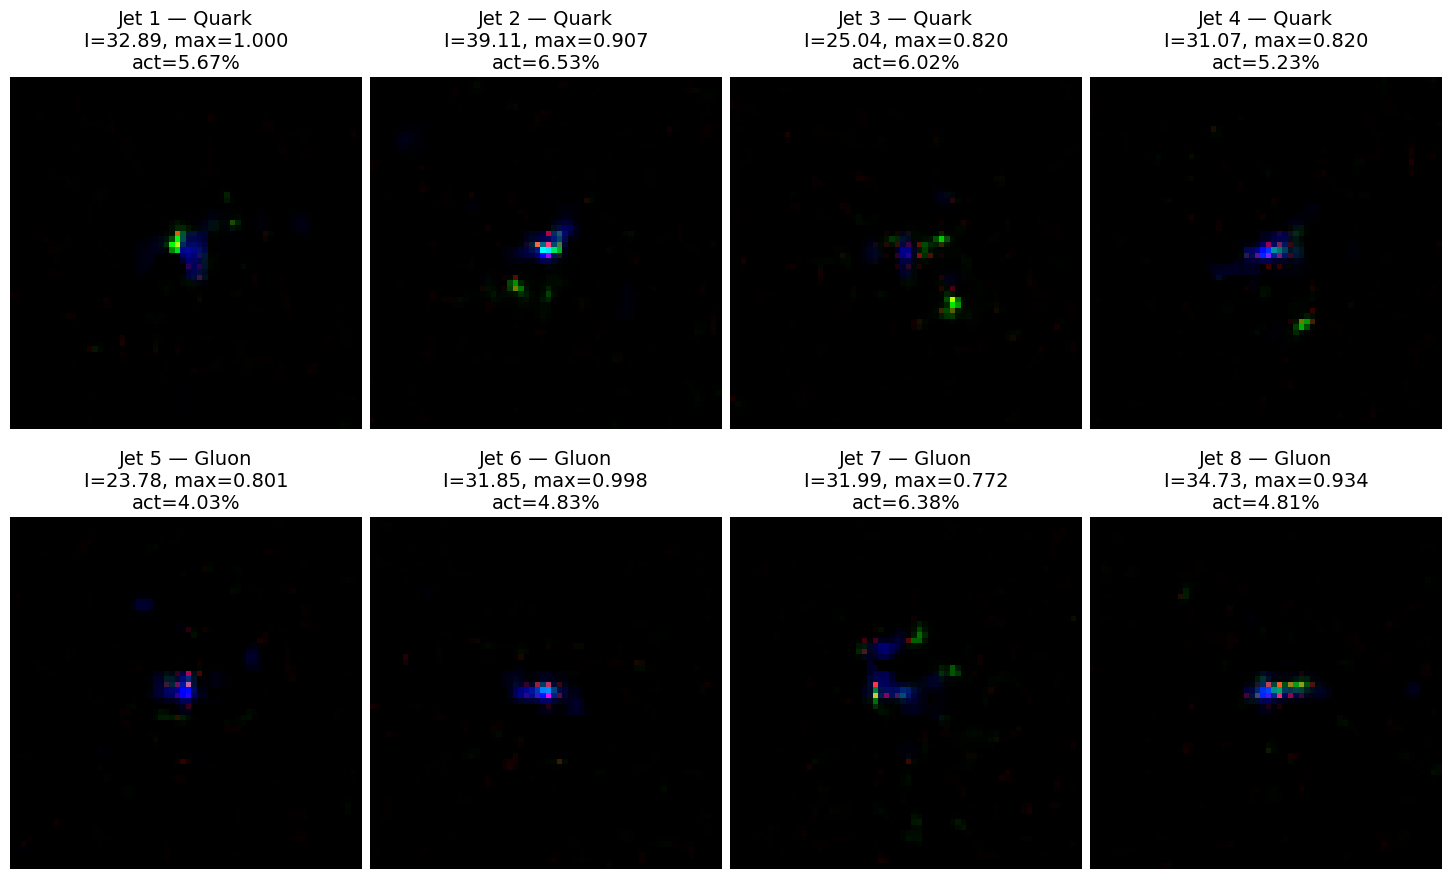

In [133]:
plot_generated_jets(generated_images_01=quantum_generated_images, labels=quantum_labels, num_images=8, contrast=True, class_names={0: 'Quark', 1: 'Gluon'})

In [134]:
quantum_diag = collect_image_diagnostics(quantum_generated_images, active_thr_01=0.0001, num_radial_bins=32)

In [135]:
quantum_summary = summarize_real_vs_generated(real_diag, quantum_diag)
display(quantum_summary)

,Canal,E real media,E gen media,Bias E (%),W1 energía,Fracción activa real,Fracción activa gen,Diferencia activa (p.p.),Máximo real medio,Máximo gen medio,W1 máximo,Radial L1,Radial L2
0,TRACKER,5.859265,6.649223,13.482204,0.955829,0.041333,0.051880,1.054736,0.760318,0.746602,0.092542,0.008092,0.012540
1,ECAL,7.773422,8.475338,9.029694,1.330534,0.053148,0.057892,0.474390,0.826301,0.667079,0.174398,0.006083,0.009845
2,HCAL,11.419732,16.184147,41.720898,5.707766,0.044677,0.053345,0.866787,0.523041,0.728974,0.224391,0.008901,0.013042


In [136]:
CLASSICAL_CONTROL_DEVICE = QLDM_DEVICE
classical_control_loader_generator = torch.Generator().manual_seed(SEED + 9300)
classical_control_train_loader = DataLoader(
    selective_train_dataset, batch_size=SELECTIVE_PILOT_BATCH_SIZE, shuffle=True, num_workers=0,
    generator=classical_control_loader_generator,
)
classical_control_val_loader = DataLoader(selective_val_dataset, batch_size=SELECTIVE_PILOT_BATCH_SIZE, shuffle=False, num_workers=0)
classical_control_scheduler = LinearNoiseScheduler(num_timesteps=LDM_NUM_TIMESTEPS, beta_s=LDM_BETA_START, beta_e=LDM_BETA_END, device=CLASSICAL_CONTROL_DEVICE)

seed_everything(SELECTIVE_SEED + 100)
classical_pilot_model = ReducedConditionalUNET(
    im_channels=4, base_channels=32, channel_mults=(1, 2, 4), t_emb_dim=128, num_classes=NUM_CLASSES,
).to(CLASSICAL_CONTROL_DEVICE)
classical_num_parameters = sum((parameter.numel() for parameter in classical_pilot_model.parameters() if parameter.requires_grad))
print('Classical trainable parameters:', f'{classical_num_parameters:,}')
print('Train samples:', len(selective_train_dataset))
print('Validation samples:', len(selective_val_dataset))
print('Train batches:', len(classical_control_train_loader))
print('Validation batches:', len(classical_control_val_loader))
seed_everything(SELECTIVE_SEED + 200)

classical_pilot_history = train_latent_ddpm(
    model=classical_pilot_model, train_loader=classical_control_train_loader,
    val_loader=classical_control_val_loader, scheduler=classical_control_scheduler,
    device=CLASSICAL_CONTROL_DEVICE, fixed_validation_conditions=SELECTIVE_FIXED_VAL_CONDITIONS,
    num_epochs=SELECTIVE_PILOT_EPOCHS, learning_rate=SELECTIVE_PILOT_LR, grad_clip=1.0,
    checkpoint_path='classical_1k_control_last_checkpoint.pt',
    best_model_path='classical_1k_control_best_model.pt', resume=False,
)
classical_pilot_best_val = min(classical_pilot_history['val'])
classical_pilot_best_epoch = int(np.argmin(classical_pilot_history['val'])) + 1

print()
print('Classical 1k best validation:', classical_pilot_best_val)
print('Best epoch:', classical_pilot_best_epoch)

Classical trainable parameters: 1,127,876
Train samples: 1024
Validation samples: 256
Train batches: 64
Validation batches: 16


LDM Epoch 01/20:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 01/20 | train=0.867503 | val=0.782248 | lr=1.00e-03 | time=5.66s
  -> Mejor modelo guardado (epoch 1, val=0.782248)
  -> Checkpoint guardado (epoch 1)


LDM Epoch 02/20:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 02/20 | train=0.774518 | val=0.736282 | lr=1.00e-03 | time=5.40s
  -> Mejor modelo guardado (epoch 2, val=0.736282)
  -> Checkpoint guardado (epoch 2)


...

Epoch 18/20 | train=0.673647 | val=0.664190 | lr=1.00e-03 | time=4.73s
  -> Checkpoint guardado (epoch 18)


LDM Epoch 19/20:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 19/20 | train=0.675543 | val=0.666088 | lr=1.00e-03 | time=4.79s
  -> Checkpoint guardado (epoch 19)


LDM Epoch 20/20:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 20/20 | train=0.675966 | val=0.666699 | lr=1.00e-03 | time=5.09s
  -> Checkpoint guardado (epoch 20)

Mejor validation loss: 0.663469

Classical 1k best validation: 0.6634685546159744
Best epoch: 17


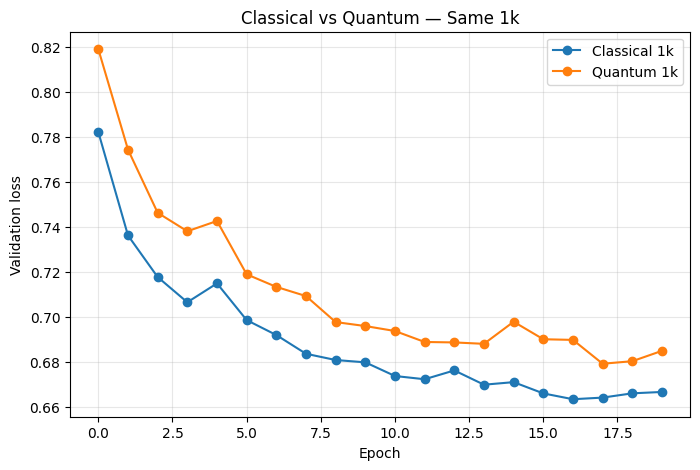

In [182]:
plt.figure(figsize=(8, 5))
plt.plot(classical_pilot_history['val'], marker='o', label='Classical 1k')
plt.plot(selective_pilot_history['val'], marker='o', label='Quantum 1k')
plt.xlabel('Epoch')
plt.ylabel('Validation loss')
plt.title('Classical vs Quantum — Same 1k')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [183]:
NUM_CLASSICAL_SAMPLES = 8
classical_labels = quantum_labels.clone()
classical_latents_std = generate_standardized_latents_ddpm(
    model=classical_pilot_model, scheduler=classical_control_scheduler, num_samples=NUM_CLASSICAL_SAMPLES,
    class_labels=classical_labels, latent_shape=(4, 16, 16), device=CLASSICAL_CONTROL_DEVICE, seed=SEED,
)

print('Standardized latent shape:', classical_latents_std.shape)
print('Finite:', torch.isfinite(classical_latents_std).all().item())
classical_latents = classical_latents_std * latent_std_train.to(CLASSICAL_CONTROL_DEVICE) + latent_mean_train.to(CLASSICAL_CONTROL_DEVICE)
print('Original latent shape:', classical_latents.shape)

with torch.no_grad():
    classical_generated_images = decode_generated_latents(vae_model=vae_model, latent_tensor=classical_latents.to(device)).cpu()

print('Generated jets:', classical_generated_images.shape)
print('Range:', classical_generated_images.min().item(), 'to', classical_generated_images.max().item())

Generando latentes DDPM:   0%|          | 0/1000 [00:00<?, ?it/s]

Standardized latent shape: torch.Size([8, 4, 16, 16])
Finite: True
Original latent shape: torch.Size([8, 4, 16, 16])
Generated jets: torch.Size([8, 3, 64, 64])
Range: 0.0 to 0.9999923706054688


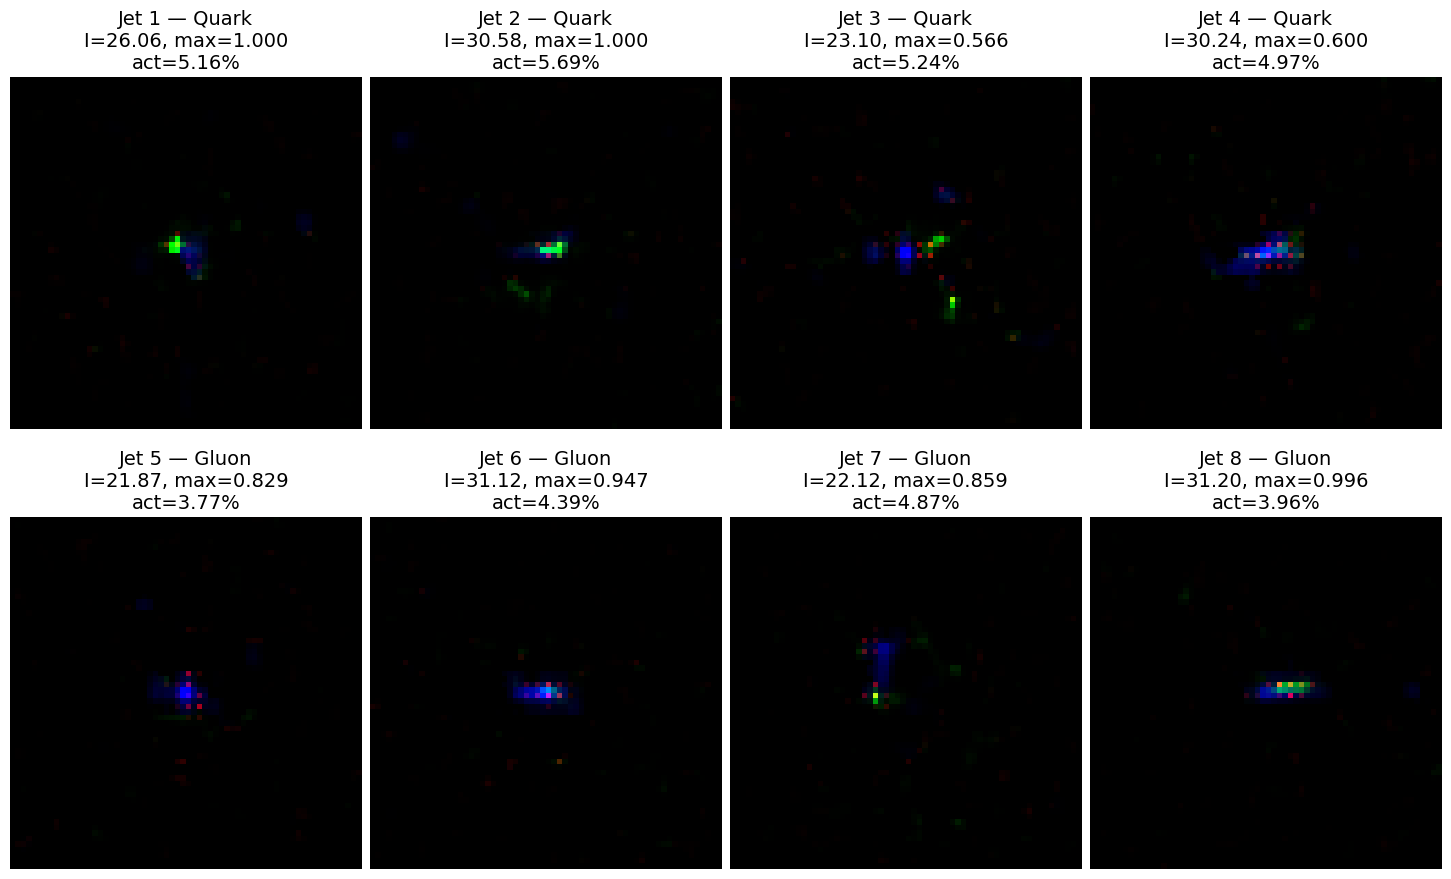

In [184]:
plot_generated_jets(generated_images_01=classical_generated_images, labels=classical_labels, num_images=8, contrast=True, class_names={0: 'Quark', 1: 'Gluon'})

In [185]:
classical_diag_8 = collect_image_diagnostics(classical_generated_images, active_thr_01=0.0001, num_radial_bins=32)
classical_summary_8 = summarize_real_vs_generated(real_diag, classical_diag_8)
display(classical_summary_8.round(6))

,Canal,E real media,E gen media,Bias E (%),W1 energía,Fracción activa real,Fracción activa gen,Diferencia activa (p.p.),Máximo real medio,Máximo gen medio,W1 máximo,Radial L1,Radial L2
0,TRACKER,5.859265,6.238374,6.470255,0.907715,0.041333,0.048065,0.673266,0.760318,0.611064,0.190371,0.007566,0.011657
1,ECAL,7.773422,7.100788,-8.652987,0.875919,0.053148,0.046265,-0.688330,0.826301,0.618227,0.208241,0.005954,0.009030
2,HCAL,11.419732,13.697092,19.942324,3.359428,0.044677,0.048370,0.369351,0.523041,0.616128,0.177693,0.008376,0.012963


In [186]:
quantum_comparison_8 = quantum_summary.copy()
classical_comparison_8 = classical_summary_8.copy()
quantum_comparison_8.insert(0, 'Model', 'Quantum 1k')
classical_comparison_8.insert(0, 'Model', 'Classical 1k')
comparison_8jets = pd.concat([classical_comparison_8, quantum_comparison_8], ignore_index=True)
display(comparison_8jets.round(6))

,Model,Canal,E real media,E gen media,Bias E (%),W1 energía,Fracción activa real,Fracción activa gen,Diferencia activa (p.p.),Máximo real medio,Máximo gen medio,W1 máximo,Radial L1,Radial L2
0,Classical 1k,TRACKER,5.859265,6.238374,6.470255,0.907715,0.041333,0.048065,0.673266,0.760318,0.611064,0.190371,0.007566,0.011657
1,Classical 1k,ECAL,7.773422,7.100788,-8.652987,0.875919,0.053148,0.046265,-0.688330,0.826301,0.618227,0.208241,0.005954,0.009030
2,Classical 1k,HCAL,11.419732,13.697092,19.942324,3.359428,0.044677,0.048370,0.369351,0.523041,0.616128,0.177693,0.008376,0.012963
3,Quantum 1k,TRACKER,5.859265,6.649223,13.482204,0.955829,0.041333,0.051880,1.054736,0.760318,0.746602,0.092542,0.008092,0.012540
4,Quantum 1k,ECAL,7.773422,8.475338,9.029694,1.330534,0.053148,0.057892,0.474390,0.826301,0.667079,0.174398,0.006083,0.009845
5,Quantum 1k,HCAL,11.419732,16.184147,41.720898,5.707766,0.044677,0.053345,0.866787,0.523041,0.728974,0.224391,0.008901,0.013042


In [145]:
quantum_timestep_results = evaluate_latent_ddpm_by_timestep_bins(
    model=selective_pilot_model, data_loader=selective_val_loader, scheduler=selective_scheduler,
    device=QLDM_DEVICE, fixed_conditions=SELECTIVE_FIXED_VAL_CONDITIONS, bin_width=200,
)
classical_timestep_results = evaluate_latent_ddpm_by_timestep_bins(
    model=classical_pilot_model, data_loader=classical_control_val_loader, scheduler=classical_control_scheduler,
    device=CLASSICAL_CONTROL_DEVICE, fixed_conditions=SELECTIVE_FIXED_VAL_CONDITIONS, bin_width=200,
)

In [146]:
comparison_by_timestep = pd.DataFrame({
    't_range': quantum_timestep_results['t_range'],
    'n': quantum_timestep_results['n'],
    'classical_loss': classical_timestep_results['loss'],
    'quantum_loss': quantum_timestep_results['loss'],
    'classical_v_loss': classical_timestep_results['v_loss'],
    'quantum_v_loss': quantum_timestep_results['v_loss'],
})
comparison_by_timestep['delta_Q_minus_C'] = comparison_by_timestep['quantum_loss'] - comparison_by_timestep['classical_loss']
comparison_by_timestep['relative_difference_pct'] = 100.0 * comparison_by_timestep['delta_Q_minus_C'] / comparison_by_timestep['classical_loss']

display(comparison_by_timestep.round(6))

,t_range,n,classical_loss,quantum_loss,classical_v_loss,quantum_v_loss,delta_Q_minus_C,relative_difference_pct
0,000-199,58,0.706333,0.722878,0.700116,0.716422,0.016545,2.342383
1,200-399,59,0.583243,0.601428,0.557605,0.574881,0.018185,3.117970
2,400-599,50,0.599865,0.629420,0.562790,0.590572,0.029556,4.927049
3,600-799,42,0.708630,0.716465,0.663959,0.671368,0.007835,1.105588
4,800-999,47,0.738587,0.742846,0.692084,0.696124,0.004258,0.576518


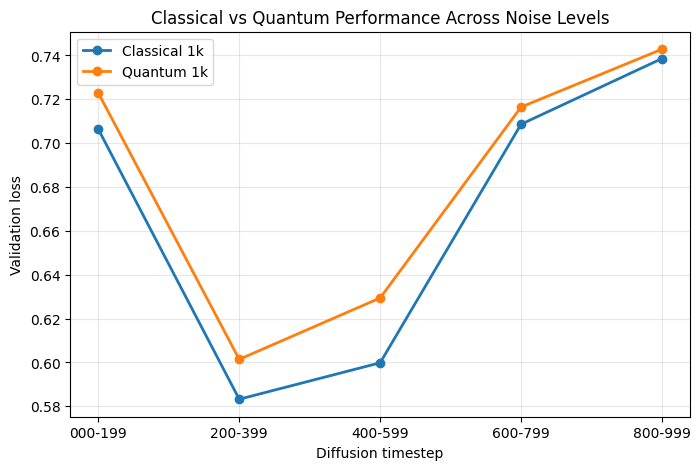

In [147]:
plt.figure(figsize=(8, 5))
plt.plot(comparison_by_timestep['t_range'], comparison_by_timestep['classical_loss'], marker='o', linewidth=2, label='Classical 1k')
plt.plot(comparison_by_timestep['t_range'], comparison_by_timestep['quantum_loss'], marker='o', linewidth=2, label='Quantum 1k')
plt.xlabel('Diffusion timestep')
plt.ylabel('Validation loss')
plt.title('Classical vs Quantum Performance Across Noise Levels')
plt.legend()
plt.grid(alpha=0.3)
plt.show()